<a href="https://colab.research.google.com/github/Kratzramanis/RVT-Verification/blob/main/3Dto2D_NGC891_u_M101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

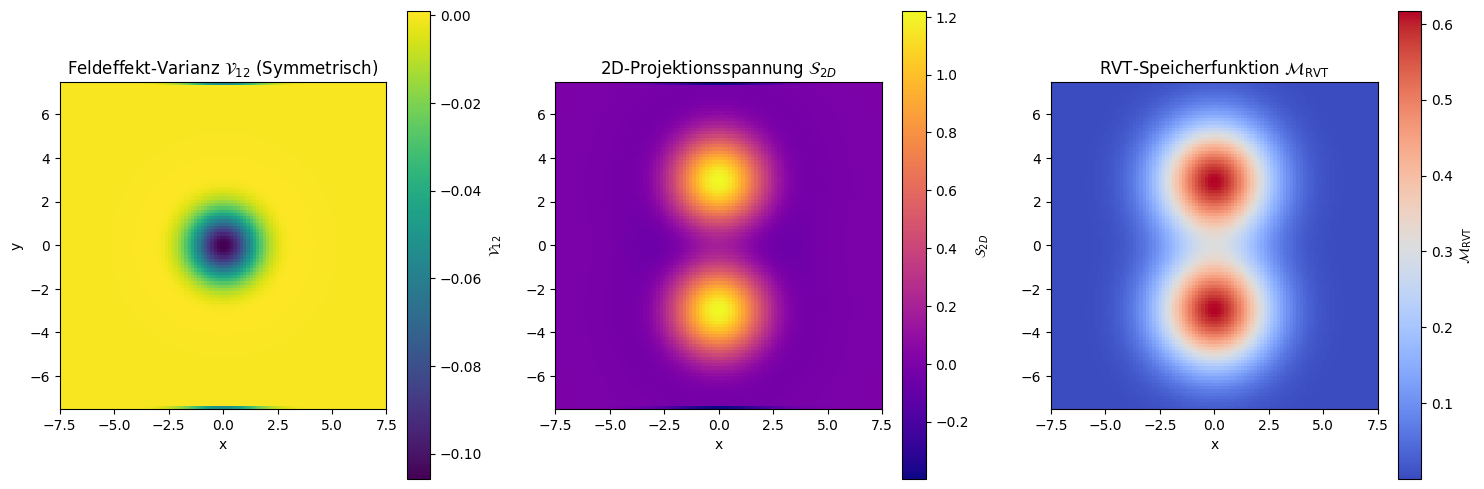

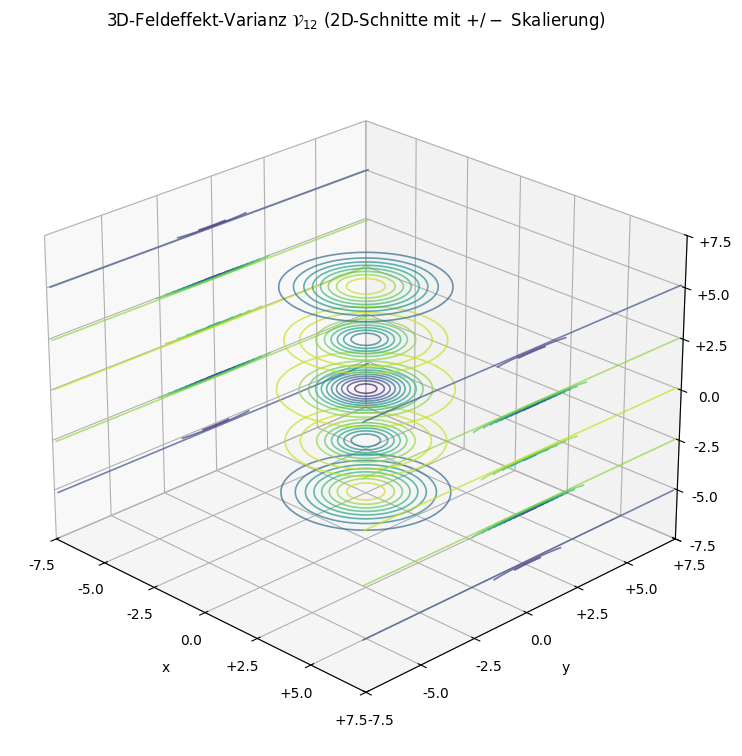

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import gaussian_filter

# --- Parameter (Skalierung erhöht) ---
N = 100       # Gitterpunkte
L = 15.0      # Systemgröße (Skalierung für räumliche Ausdehnung erhöht)
alpha = 0.8   # Kopplungskonstante (RVT)
chi = 1.0     # Kopplungskonstante für M_RVT

sigma_ref = 1.8  # Skalenparameter erhöht für stärkere Felddiffusion

# --- Gitter erstellen ---
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z)

# --- Projektionsfelder Xi_1 und Xi_2 (Gauß'sche Verteilungen) ---
Xi_1 = np.exp(-((X + 3.0)**2 + Y**2 + Z**2) / (2 * sigma_ref**2))
Xi_2 = np.exp(-((X - 3.0)**2 + Y**2 + Z**2) / (2 * sigma_ref**2))
Xi = Xi_1 + Xi_2

# --- Gradienten berechnen (zentrale Differenzen) ---
def gradient(f, dx):
    grad_x = (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dx)
    grad_y = (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * dx)
    grad_z = (np.roll(f, -1, axis=2) - np.roll(f, 1, axis=2)) / (2 * dx)
    return np.stack((grad_x, grad_y, grad_z), axis=-1)

dx = L / (N - 1)
grad_Xi_1 = gradient(Xi_1, dx)
grad_Xi_2 = gradient(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 (Kreuzterm) ---
V_12 = 2 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)  # Skalarprodukt der Gradienten

# --- RVT-Korrekturtensor E_mu_nu (vereinfacht für 3D) ---
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
              np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
              np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
              6 * Xi) / (dx**2)

E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy     # Spur in 2D (vereinfacht)
S_perp = E_zz          # Blockierter Normalanteil (z-Richtung)
M_RVT = S_2D - S_perp  # RVT-Speicherfunktion

# --- Visualisierung 2D ---
z_slice = N // 2
V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(V_12_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='viridis')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (Symmetrisch)')
plt.xlabel('x')
plt.ylabel('y')

plt.subplot(1, 3, 2)
plt.imshow(S_2D_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='plasma')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x')

plt.subplot(1, 3, 3)
plt.imshow(M_RVT_slice.T, origin='lower', extent=[-L/2, L/2, -L/2, L/2], cmap='coolwarm')
plt.colorbar(label=r'$\mathcal{M}_{\text{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\text{RVT}}$')
plt.xlabel('x')

plt.tight_layout()
plt.savefig('RVT_Varianz_Simulation_2D_Symmetrisch.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz (Symmetrische Z-Achse & Erhöhte Skalierung) ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Mehrere Schnitt-Ebenen entlang der Z-Achse für stärkere räumliche Präsenz
z_slices = [N // 6, N // 3, N // 2, 2 * N // 3, 5 * N // 6]

for z_fix in z_slices:
    z_val = z[z_fix]
    ax.contour(X[:, :, z_fix], Y[:, :, z_fix], V_12[:, :, z_fix],
               levels=12, cmap='viridis', alpha=0.7, linewidths=1.2,
               zdir='z', offset=z_val)

# Achsenbegrenzungen festlegen
ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(-L/2, L/2)

# --- Z-ACHSE MIT EXPLIZITEN PLUS / MINUS TICKS ---
ticks = np.linspace(-L/2, L/2, 7)
labels = [f"{val:+.1f}" if val != 0 else "0.0" for val in ticks]

ax.set_xticks(ticks)
ax.set_xticklabels(labels)
ax.set_yticks(ticks)
ax.set_yticklabels(labels)
ax.set_zticks(ticks)
ax.set_zticklabels(labels)

ax.set_xlabel('x', labelpad=10)
ax.set_ylabel('y', labelpad=10)
ax.set_zlabel('z', labelpad=10)
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (2D-Schnitte mit $+/-$ Skalierung)', pad=20)

ax.view_init(elev=25, azim=-45)

plt.tight_layout()
plt.savefig('RVT_Varianz_3D_Schnitte.png', dpi=300)
plt.show()

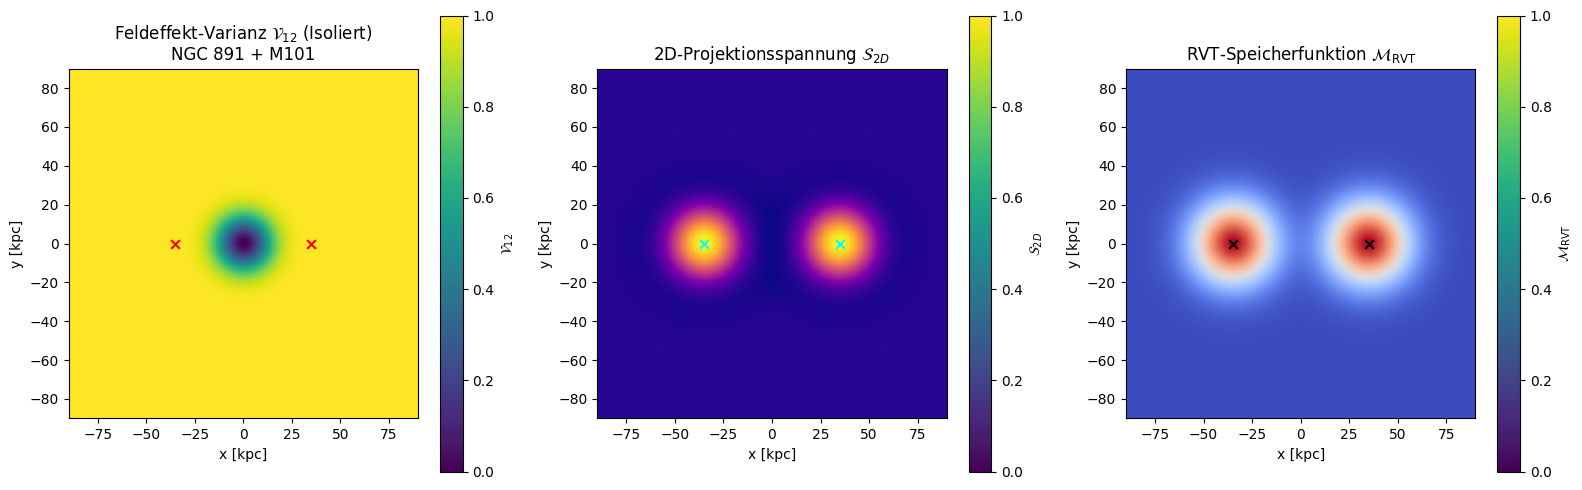

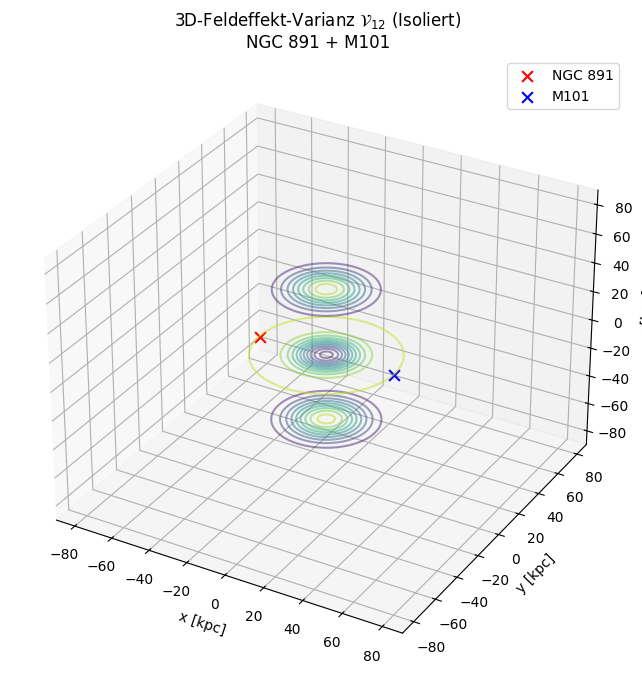

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 2: RVT-Feldeffekt-Varianz für NGC 891 + M101
# Baseline-Referenz mit identischer Skalierung (Ohne Inklination)
# ============================================================

# --- Parameter ---
N = 140          # Gitterpunkte
L = 180.0        # Systemgröße in kpc; Fenster: [-90, +90] kpc
alpha = 0.8      # RVT-Kopplungskonstante
chi = 1.0        # Kopplungskonstante für M_RVT

# --- Galaxienparameter (Synchronisiert für symmetrische Baseline) ---
scale_ref = 15.0  # Einheitliche Skalenlänge in kpc
M_ref = 1e11      # Einheitliche baryonische Masse in M_sun

M_891 = M_ref
scale_891 = scale_ref
center_891 = (-35.0, 0.0, 0.0)

M_M101 = M_ref
scale_M101 = scale_ref
center_M101 = (35.0, 0.0, 0.0)

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

Xi_1 = gaussian_field(M_891, scale_891, center_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 ---
V_12 = 2.0 * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{V}_{12}$')
plt.title(r'Feldeffekt-Varianz $\mathcal{V}_{12}$ (Isoliert)' + '\nNGC 891 + M101')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{S}_{2D}$')
plt.title(r'2D-Projektionsspannung $\mathcal{S}_{2D}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'$\mathcal{M}_{\mathrm{RVT}}$')
plt.title(r'RVT-Speicherfunktion $\mathcal{M}_{\mathrm{RVT}}$')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(r'3D-Feldeffekt-Varianz $\mathcal{V}_{12}$ (Isoliert)' + '\nNGC 891 + M101')
ax.legend()

plt.savefig('RVT_Varianz_3D_NGC891_M101_grid180.png', dpi=300)
plt.show()

gamma_RVT(NGC 891, 85°) = 1.797
gamma_RVT(M101,    18°) = 1.247


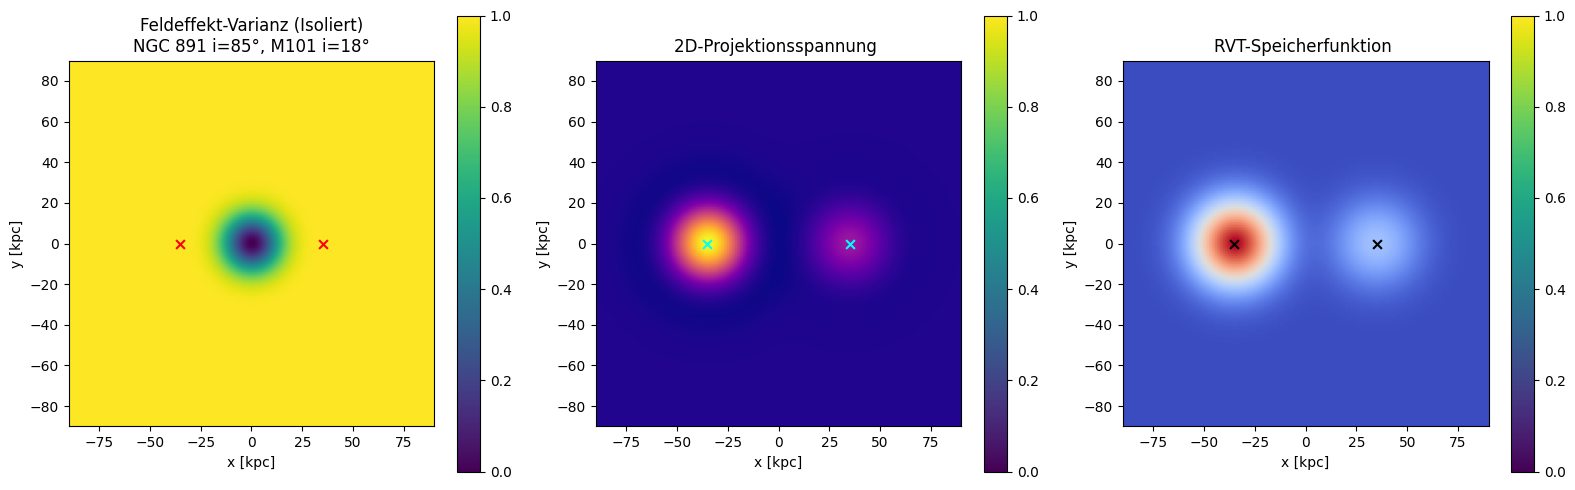

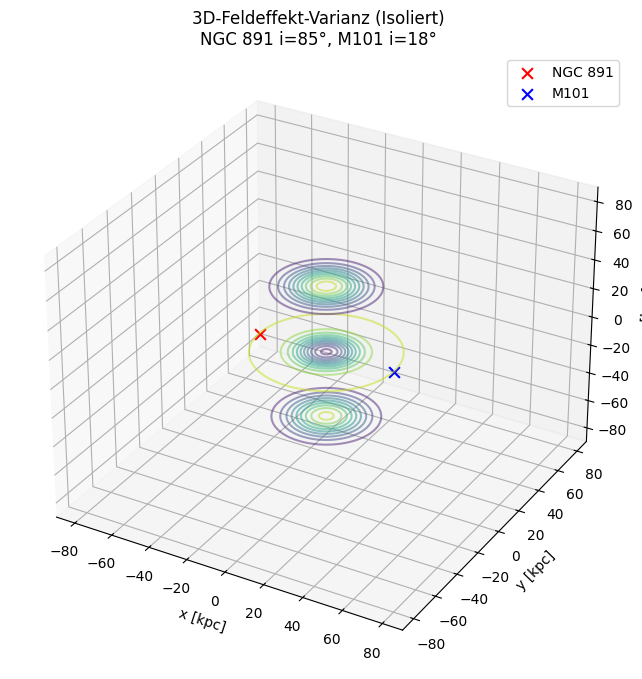

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# ZELLE 3: RVT-Feldeffekt-Varianz mit Inklinationsskalierung
# NGC 891: 85°
# M101:    18°
# ============================================================

# --- Parameter ---
N = 140           # Gitterpunkte
L = 180.0         # Systemgröße in kpc; Fenster: [-90, +90] kpc
C_RVT = 0.8       # RVT-Kopplungskonstante

# --- Galaxienparameter (Identische Skalierung & Masse zur Isolierung des Inklinations-Effekts) ---
scale_ref = 15.0  # Einheitlicher Skalenparameter
M_ref = 1e11      # Einheitliche Masse

M_891 = M_ref
scale_891 = scale_ref
center_891 = (-35.0, 0.0, 0.0)

M_M101 = M_ref
scale_M101 = scale_ref
center_M101 = (35.0, 0.0, 0.0)

# --- Inklinationswinkel ---
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

# --- RVT-Gamma-Korrektur ---
gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"gamma_RVT(NGC 891, {inclination_891_deg:.0f}°) = {gamma_891:.3f}")
print(f"gamma_RVT(M101,    {inclination_M101_deg:.0f}°) = {gamma_M101:.3f}")

# --- Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

# Wichtig: indexing='ij', damit axis=0 -> x, axis=1 -> y, axis=2 -> z
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Gaußförmige Projektionsfelder mit Inklinationsskalierung ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

# Originale Inklinationsprojektion:
# Feld wird mit sin(i) gewichtet.
Xi_1 = gaussian_field(M_891, scale_891, center_891) * np.sin(inclination_891)
Xi_2 = gaussian_field(M_M101, scale_M101, center_M101) * np.sin(inclination_M101)

Xi = Xi_1 + Xi_2

# --- Gradienten berechnen ---
def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

grad_Xi_1 = gradient_3d(Xi_1, dx)
grad_Xi_2 = gradient_3d(Xi_2, dx)

# --- Feldeffekt-Varianz V_12 mit RVT-Kopplungsfaktor ---
V_12 = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# --- Zweite Ableitungen / Laplace ---
def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

d2x_Xi = second_derivative(Xi, dx, axis=0)
d2y_Xi = second_derivative(Xi, dx, axis=1)
d2z_Xi = second_derivative(Xi, dx, axis=2)

laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

# --- RVT-Korrekturtensor E_mu_nu, 3D-vereinfachte Diagonalkomponenten ---
E_xx = d2x_Xi - laplace_Xi
E_yy = d2y_Xi - laplace_Xi
E_zz = d2z_Xi - laplace_Xi

# --- Projektion auf 2D-Ebene ---
S_2D = E_xx + E_yy
S_perp = E_zz
M_RVT = S_2D - S_perp

# --- 2D-Schnitt bei z = 0 ---
z_slice = N // 2

V_12_slice = V_12[:, :, z_slice]
M_RVT_slice = M_RVT[:, :, z_slice]
S_2D_slice = S_2D[:, :, z_slice]
S_perp_slice = S_perp[:, :, z_slice]

# --- Visualisierung 2D ---
plt.figure(figsize=(16, 5))

# Plot 1: Feldeffekt-Varianz
plt.subplot(1, 3, 1)
plt.imshow(
    V_12_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='viridis',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='red', s=40, marker='x')
plt.colorbar(label=r'')
plt.title(
    r'Feldeffekt-Varianz (Isoliert)'
    + '\nNGC 891 i=85°, M101 i=18°'
)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 2: 2D-Projektionsspannung
plt.subplot(1, 3, 2)
plt.imshow(
    S_2D_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='plasma',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='cyan', s=40, marker='x')
plt.colorbar(label=r'')
plt.title(r'2D-Projektionsspannung ')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

# Plot 3: RVT-Speicherfunktion
plt.subplot(1, 3, 3)
plt.imshow(
    M_RVT_slice.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]],
            c='black', s=40, marker='x')
plt.colorbar(label=r'')
plt.title(r'RVT-Speicherfunktion ')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')

plt.tight_layout()
plt.savefig('RVT_Varianz_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()

# --- 3D-Visualisierung der Varianz in mehreren z-Schnitten ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for z_fix in [N // 4, N // 2, 3 * N // 4]:
    ax.contour(
        X[:, :, z_fix],
        Y[:, :, z_fix],
        V_12[:, :, z_fix],
        levels=10,
        cmap='viridis',
        alpha=0.5,
        zdir='z',
        offset=z[z_fix]
    )

ax.scatter(center_891[0], center_891[1], center_891[2],
           c='red', s=60, marker='x', label='NGC 891')
ax.scatter(center_M101[0], center_M101[1], center_M101[2],
           c='blue', s=60, marker='x', label='M101')

ax.set_xlim(-L / 2, L / 2)
ax.set_ylim(-L / 2, L / 2)
ax.set_zlim(-L / 2, L / 2)

ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')
ax.set_zlabel('z [kpc]')
ax.set_title(
    r'3D-Feldeffekt-Varianz (Isoliert)'
    + '\nNGC 891 i=85°, M101 i=18°'
)
ax.legend()

plt.savefig('RVT_Varianz_3D_Inklination_NGC891_M101_grid180.png', dpi=300)
plt.show()

Zielausrichtung gamma_RVT(90°) = 1.800
gamma_RVT(Links, 85.0°) = 1.797
gamma_RVT(Rechts, 18.0°) = 1.247


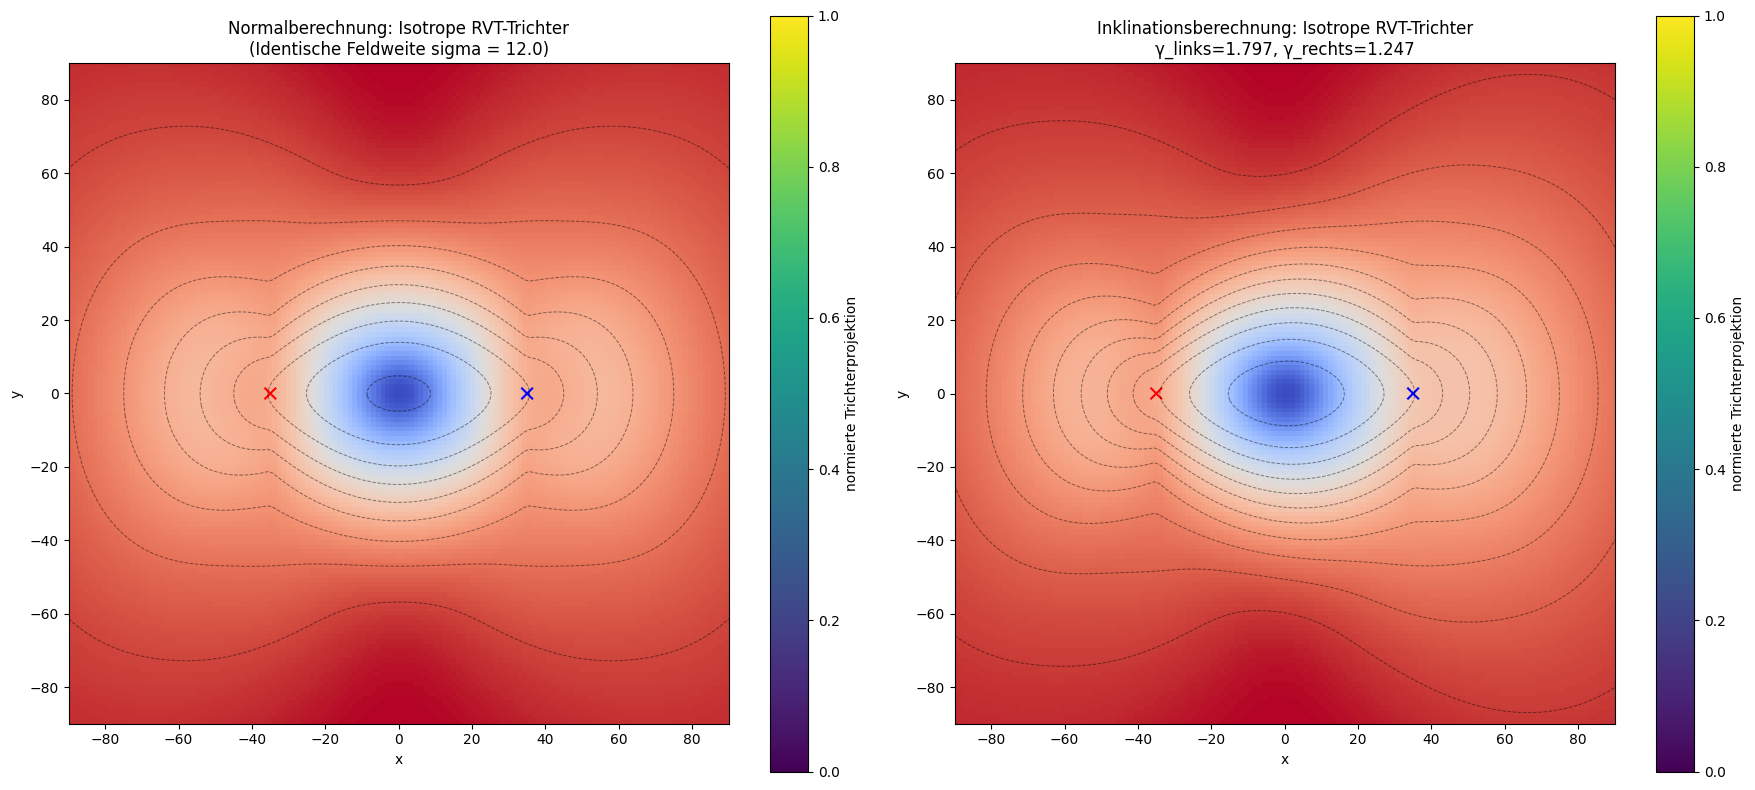

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion
# Absolut identische Feldskalierung für BEIDE Zentren!
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# --- EXAKT IDENTISCHE SKALIERUNG FÜR BEIDE ZENTREN ---
mass_ref = 1e11          # Identische Feldamplitude
scale_ref = 12.0         # EINHEITLICHE Feldweite (kein 10 vs 15 mehr!)

center_left = (-35.0, 0.0, 0.0)
center_right = (35.0, 0.0, 0.0)

# Ausrichtungswinkel
inclination_left_deg = 85.0
inclination_right_deg = 18.0

inclination_left = np.radians(inclination_left_deg)
inclination_right = np.radians(inclination_right_deg)

gamma_left = 1.0 + C_RVT * np.sin(inclination_left)
gamma_right = 1.0 + C_RVT * np.sin(inclination_right)

print(f"Zielausrichtung gamma_RVT(90°) = {gamma_90:.3f}")
print(f"gamma_RVT(Links, {inclination_left_deg}°) = {gamma_left:.3f}")
print(f"gamma_RVT(Rechts, {inclination_right_deg}°) = {gamma_right:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld (Mit einheitlichem scale_ref)
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung (Identische Feldweiten!)
# ------------------------------------------------------------
Xi_left_normal = gaussian_field(mass_ref, scale_ref, center_left)
Xi_right_normal = gaussian_field(mass_ref, scale_ref, center_right)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_left_normal,
    Xi_right_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung (Identische Feldweiten!)
# ------------------------------------------------------------
Xi_left_incl = gaussian_field(mass_ref, scale_ref, center_left) * gamma_left
Xi_right_incl = gaussian_field(mass_ref, scale_ref, center_right) * gamma_right

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_left_incl,
    Xi_right_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width,
    length_scale,
    target_angle=np.pi / 2,
):
    xL, yL = center_left
    xR, yR = center_right

    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    opening = np.sin(target_angle)

    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Identische Breite `width` für beide Seiten!
    radial_width_L = width * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width * (1.0 + np.abs(XR) / length_scale)

    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    return funnel_L + funnel_R, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_left_2d = (center_left[0], center_left[1])
center_right_2d = (center_right[0], center_right[1])

# ------------------------------------------------------------
# Amplituden
# ------------------------------------------------------------
def robust_amp(A):
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

# Symmetrische Basisamplituden
amp_left_normal = amp_normal
amp_right_normal = amp_normal

amp_left_incl = amp_incl * (gamma_left / gamma_90)
amp_right_incl = amp_incl * (gamma_right / gamma_90)

# ------------------------------------------------------------
# Trichter erzeugen (EINHEITLICHE TRICHTERBREITE `scale_ref`)
# ------------------------------------------------------------
length_scale = 28.0

funnel_normal, funnel_left_normal, funnel_right_normal = opposing_funnel_2d(
    X2,
    Y2,
    center_left_2d,
    center_right_2d,
    amp_left_normal,
    amp_right_normal,
    scale_ref,
    length_scale,
    target_angle=target_angle,
)

funnel_incl, funnel_left_incl, funnel_right_incl = opposing_funnel_2d(
    X2,
    Y2,
    center_left_2d,
    center_right_2d,
    amp_left_incl,
    amp_right_incl,
    scale_ref,
    length_scale,
    target_angle=target_angle,
)

# ------------------------------------------------------------
# Kombinierte Karten
# ------------------------------------------------------------
def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(18, 8))

# Normaltrichter
plt.subplot(1, 2, 1)
plt.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_normal,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_left[0], center_right[0]],
    [center_left[1], center_right[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.colorbar(label='normierte Trichterprojektion')
plt.title('Normalberechnung: Isotrope RVT-Trichter\n(Identische Feldweite sigma = 12.0)')
plt.xlabel('x')
plt.ylabel('y')

# Inklinationstrichter
plt.subplot(1, 2, 2)
plt.imshow(
    incl_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
plt.contour(
    X2,
    Y2,
    funnel_incl,
    levels=12,
    colors='black',
    alpha=0.45,
    linewidths=0.7
)
plt.scatter(
    [center_left[0], center_right[0]],
    [center_left[1], center_right[1]],
    c=['red', 'blue'],
    s=70,
    marker='x'
)
plt.colorbar(label='normierte Trichterprojektion')
plt.title(f'Inklinationsberechnung: Isotrope RVT-Trichter\nγ_links={gamma_left:.3f}, γ_rechts={gamma_right:.3f}')
plt.xlabel('x')
plt.ylabel('y')

plt.tight_layout()
plt.savefig('RVT_Trichter_Isotrop_Symmetrisch.png', dpi=300)
plt.show()

Zielausrichtung gamma_RVT(90°)      = 1.800
gamma_RVT(NGC 891, 85°)             = 1.797
gamma_RVT(M101, 18°)                = 1.247


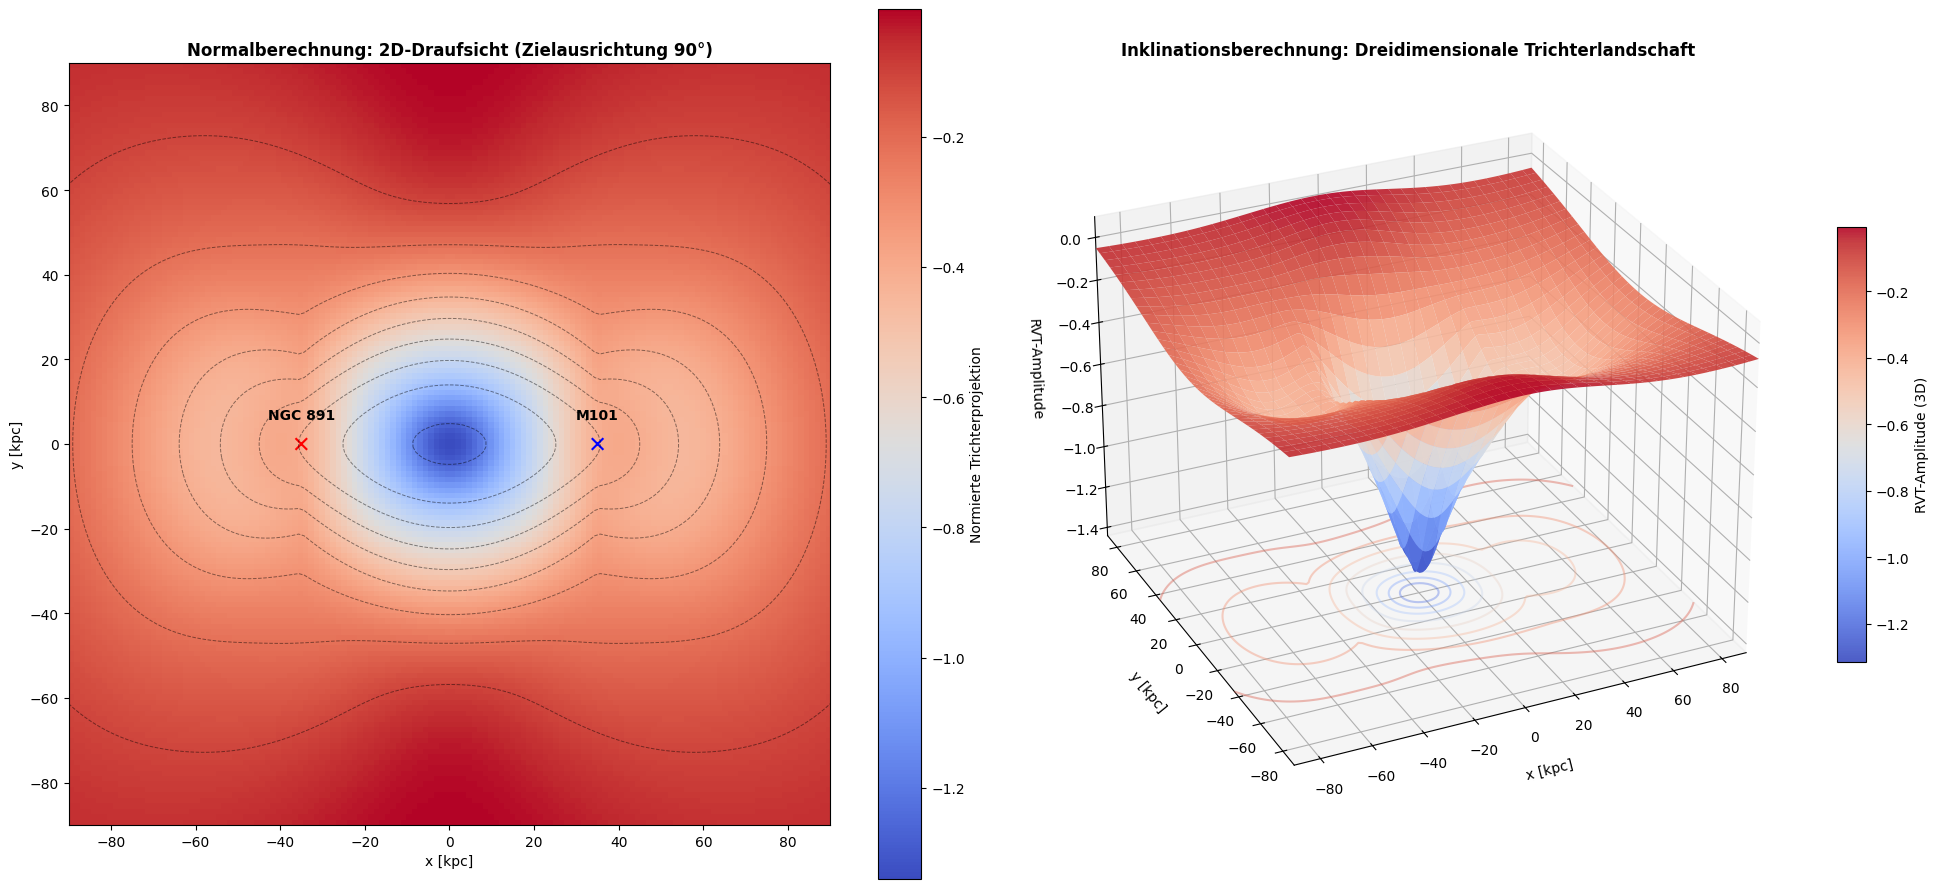

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ZELLE 4:
# Trichterförmige RVT-Projektionsfunktion (2D vs. ECHTES 3D)
# ISOTROPE SKALIERUNG MIT KLARNAMEN (NGC 891 / M101)
# ============================================================

# ------------------------------------------------------------
# Parameter
# ------------------------------------------------------------
N = 140
L = 180.0
C_RVT = 0.8

# Zielausrichtung: 90°
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# --- KLARNAMEN BEIBEHALTEN, SKALIERUNG VEREINHEITLICHT ---
M_891 = 1e11
M_M101 = 1e11
scale_ref = 12.0         # EINHEITLICHE Feldweite für beide!

center_891 = (-35.0, 0.0, 0.0)
center_M101 = (35.0, 0.0, 0.0)

# Beobachtete Inklinationen
inclination_891_deg = 85.0
inclination_M101_deg = 18.0

inclination_891 = np.radians(inclination_891_deg)
inclination_M101 = np.radians(inclination_M101_deg)

gamma_891 = 1.0 + C_RVT * np.sin(inclination_891)
gamma_M101 = 1.0 + C_RVT * np.sin(inclination_M101)

print(f"Zielausrichtung gamma_RVT(90°)      = {gamma_90:.3f}")
print(f"gamma_RVT(NGC 891, 85°)             = {gamma_891:.3f}")
print(f"gamma_RVT(M101, 18°)                = {gamma_M101:.3f}")

# ------------------------------------------------------------
# Gitter
# ------------------------------------------------------------
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)

dx = x[1] - x[0]

X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# ------------------------------------------------------------
# Basisfeld (Einheitliches scale_ref)
# ------------------------------------------------------------
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(
        -(
            (X - cx)**2 +
            (Y - cy)**2 +
            (Z - cz)**2
        ) / (2 * scale**2)
    )

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative(f, dx, axis):
    first = np.gradient(f, dx, axis=axis, edge_order=2)
    second = np.gradient(first, dx, axis=axis, edge_order=2)
    return second

def compute_rvt_values(Xi_1, Xi_2, coupling=1.0):
    Xi = Xi_1 + Xi_2

    grad_Xi_1 = gradient_3d(Xi_1, dx)
    grad_Xi_2 = gradient_3d(Xi_2, dx)

    V_12 = 2.0 * coupling * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

    d2x_Xi = second_derivative(Xi, dx, axis=0)
    d2y_Xi = second_derivative(Xi, dx, axis=1)
    d2z_Xi = second_derivative(Xi, dx, axis=2)

    laplace_Xi = d2x_Xi + d2y_Xi + d2z_Xi

    E_xx = d2x_Xi - laplace_Xi
    E_yy = d2y_Xi - laplace_Xi
    E_zz = d2z_Xi - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    return V_12, M_RVT, S_2D, S_perp

# ------------------------------------------------------------
# Normalrechnung
# ------------------------------------------------------------
Xi_891_normal = gaussian_field(M_891, scale_ref, center_891)
Xi_M101_normal = gaussian_field(M_M101, scale_ref, center_M101)

V_12_normal, M_RVT_normal, S_2D_normal, S_perp_normal = compute_rvt_values(
    Xi_891_normal,
    Xi_M101_normal,
    coupling=1.0
)

# ------------------------------------------------------------
# Inklinationsrechnung
# ------------------------------------------------------------
Xi_891_incl = gaussian_field(M_891, scale_ref, center_891) * gamma_891
Xi_M101_incl = gaussian_field(M_M101, scale_ref, center_M101) * gamma_M101

V_12_incl, M_RVT_incl, S_2D_incl, S_perp_incl = compute_rvt_values(
    Xi_891_incl,
    Xi_M101_incl,
    coupling=C_RVT
)

# ------------------------------------------------------------
# 2D-Schnitt
# ------------------------------------------------------------
z_slice = N // 2

Vn = V_12_normal[:, :, z_slice]
Mn = M_RVT_normal[:, :, z_slice]

Vi = V_12_incl[:, :, z_slice]
Mi = M_RVT_incl[:, :, z_slice]

# ------------------------------------------------------------
# Trichterfunktion
# ------------------------------------------------------------
def opposing_funnel_2d(
    X2,
    Y2,
    center_left,
    center_right,
    amp_left,
    amp_right,
    width,
    length_scale,
    target_angle=np.pi / 2,
):
    xL, yL = center_left
    xR, yR = center_right

    XL = X2 - xL
    YL = Y2 - yL

    XR = X2 - xR
    YR = Y2 - yR

    opening = np.sin(target_angle)

    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    radial_width_L = width * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = width * (1.0 + np.abs(XR) / length_scale)

    funnel_L = (
        -amp_left
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_R = (
        -amp_right
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    funnel_total = funnel_L + funnel_R
    return funnel_total, funnel_L, funnel_R

# ------------------------------------------------------------
# 2D-Gitter für Trichter
# ------------------------------------------------------------
X2 = X[:, :, z_slice]
Y2 = Y[:, :, z_slice]

center_891_2d = (center_891[0], center_891[1])
center_M101_2d = (center_M101[0], center_M101[1])

# ------------------------------------------------------------
# Amplituden ableiten
# ------------------------------------------------------------
def robust_amp(A):
    return np.percentile(np.abs(A), 99)

amp_normal = robust_amp(Vn) + robust_amp(Mn)
amp_incl = robust_amp(Vi) + robust_amp(Mi)

amp_normal = amp_normal / (amp_normal + 1e-30)
amp_incl = amp_incl / (amp_incl + 1e-30)

amp_891_normal = amp_normal
amp_M101_normal = amp_normal

amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

# Trichter erzeugen mit ISOTROPER BREITE scale_ref
length_scale = 28.0

funnel_normal, _, _ = opposing_funnel_2d(
    X2, Y2, center_891_2d, center_M101_2d,
    amp_891_normal, amp_M101_normal, scale_ref, length_scale, target_angle=target_angle
)

funnel_incl, _, _ = opposing_funnel_2d(
    X2, Y2, center_891_2d, center_M101_2d,
    amp_891_incl, amp_M101_incl, scale_ref, length_scale, target_angle=target_angle
)

def normalize(A):
    return A / (np.max(np.abs(A)) + 1e-30)

normal_background = normalize(Vn) + normalize(Mn)
incl_background = normalize(Vi) + normalize(Mi)

normal_projection = normalize(funnel_normal) + 0.35 * normalize(normal_background)
incl_projection = normalize(funnel_incl) + 0.35 * normalize(incl_background)

# ============================================================
# REKALIBRIERTER GEOMETRISCHER 2D / 3D PLOT
# ============================================================
fig = plt.figure(figsize=(20, 9))

# SUBPLOT 1: 2D-Normaltrichter (Draufsicht)
ax1 = fig.add_subplot(1, 2, 1)
im1 = ax1.imshow(
    normal_projection.T,
    origin='lower',
    extent=[-L / 2, L / 2, -L / 2, L / 2],
    cmap='coolwarm',
    aspect='equal'
)
ax1.contour(X2, Y2, funnel_normal, levels=12, colors='black', alpha=0.45, linewidths=0.7)
ax1.scatter([center_891[0], center_M101[0]], [center_891[1], center_M101[1]], c=['red', 'blue'], s=70, marker='x')
ax1.text(center_891[0], center_891[1] + 6, 'NGC 891', color='black', ha='center', fontweight='bold')
ax1.text(center_M101[0], center_M101[1] + 6, 'M101', color='black', ha='center', fontweight='bold')
fig.colorbar(im1, ax=ax1, label='Normierte Trichterprojektion')
ax1.set_title('Normalberechnung: 2D-Draufsicht (Zielausrichtung 90°)', fontweight='bold')
ax1.set_xlabel('x [kpc]')
ax1.set_ylabel('y [kpc]')

# SUBPLOT 2: ECHTE 3D-OBERFLÄCHE (Inklinationslandschaft)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

surf = ax2.plot_surface(
    X2, Y2, incl_projection,
    cmap='coolwarm',
    linewidth=0,
    antialiased=True,
    alpha=0.9,
    rcount=45,
    ccount=45
)

# Konturlinien flach unter die Trichterlandschaft legen
z_offset = np.min(incl_projection) - 0.1
ax2.contour(X2, Y2, incl_projection, levels=12, zdir='z', offset=z_offset, cmap='coolwarm', alpha=0.4)

# Grenzen und Beschriftung
ax2.set_xlim(-L / 2, L / 2)
ax2.set_ylim(-L / 2, L / 2)
ax2.set_zlim(z_offset, np.max(incl_projection) + 0.1)
ax2.set_xlabel('x [kpc]', labelpad=10)
ax2.set_ylabel('y [kpc]', labelpad=10)
ax2.set_zlabel('RVT-Amplitude', labelpad=10)

ax2.view_init(elev=28, azim=-115)
fig.colorbar(surf, ax=ax2, label='RVT-Amplitude (3D)', shrink=0.5, aspect=15)
ax2.set_title('Inklinationsberechnung: Dreidimensionale Trichterlandschaft', fontweight='bold')

plt.tight_layout()
plt.show()

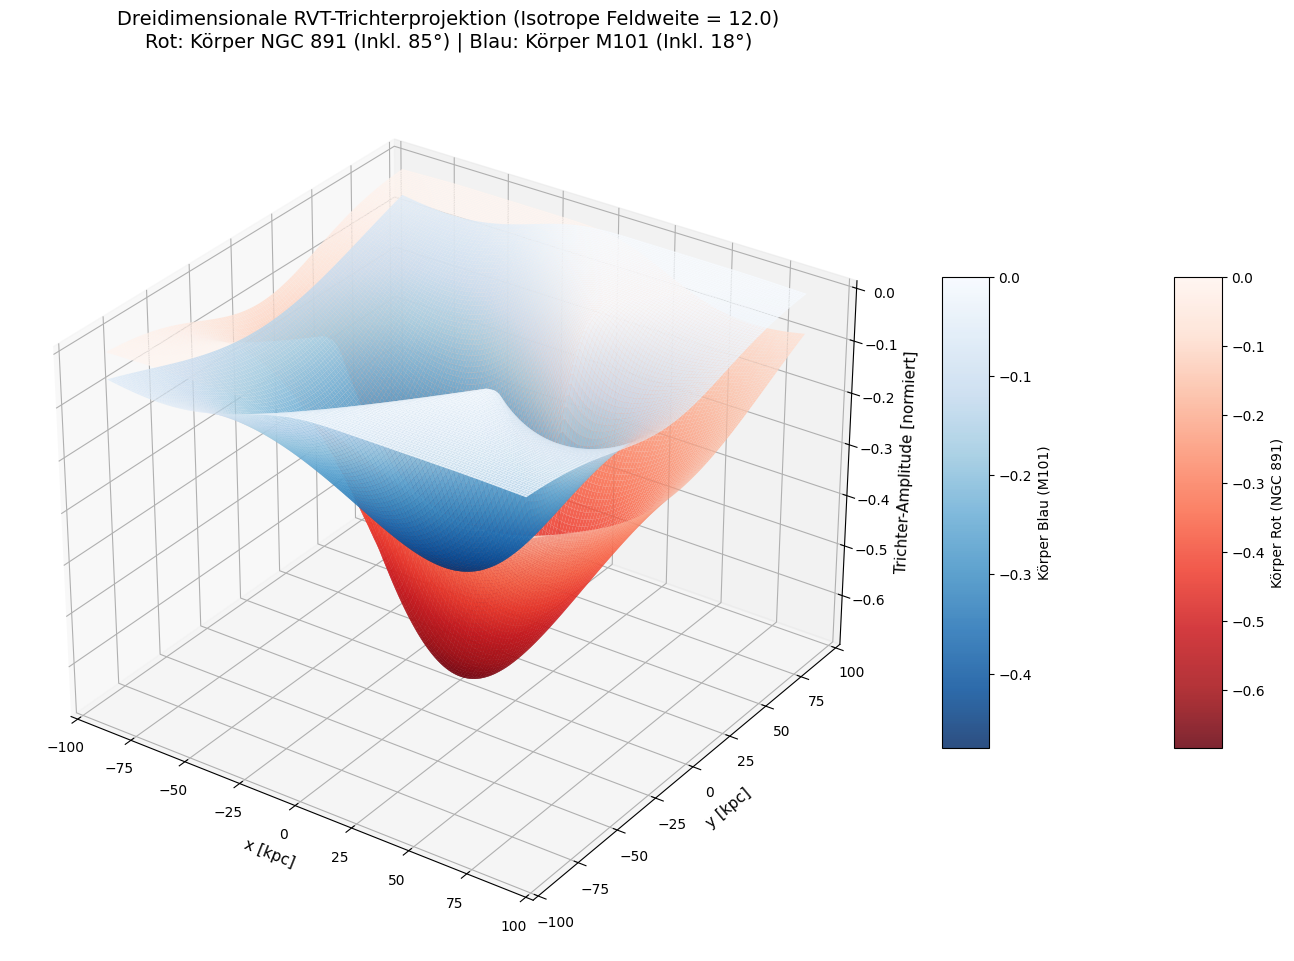

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# DREIDIMENSIONALE RVT-TRICHTER-PROJEKTION (ZELLE 4 ERWEITERT)
# ROTER KÖRPER (NGC 891) vs. BLAUER KÖRPER (M101)
# ISOTROPE SKALIERUNG FÜR BEIDE KÖRPER
# ============================================================

# Parameter
N = 140
L = 180.0
C_RVT = 0.8
target_angle_deg = 90.0
target_angle = np.radians(target_angle_deg)
length_scale = 28.0

# Galaxien-Zentren (2D-Ebene für den Trichter-Plot)
center_891_2d = (-35.0, 0.0)
center_M101_2d = (35.0, 0.0)

# --- EXAKT IDENTISCHE ISOTROPE SKALIERUNG ---
scale_ref = 12.0

# Inklinationsfaktoren
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)

# Amplituden-Skalierung
amp_incl = 1.0
amp_891_incl = amp_incl * (gamma_891 / gamma_90)
amp_M101_incl = amp_incl * (gamma_M101 / gamma_90)

# Gitter für die 2D-Grundfläche
x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
X2, Y2 = np.meshgrid(x, y, indexing='ij')

# ------------------------------------------------------------
# Getrennte Trichterberechnung für die Körper (Einheitliches scale_ref)
# ------------------------------------------------------------
def compute_single_funnels(X2, Y2):
    xL, yL = center_891_2d
    xR, yR = center_M101_2d

    XL = X2 - xL
    YL = Y2 - yL
    XR = X2 - xR
    YR = Y2 - yR

    opening = np.sin(target_angle)

    # Flussrichtungen
    forward_L = 1.0 / (1.0 + np.exp(-XL / length_scale))
    forward_R = 1.0 / (1.0 + np.exp(XR / length_scale))

    # Breitenwachstum mit IDENTISCHER Skalierung
    radial_width_L = scale_ref * (1.0 + np.abs(XL) / length_scale)
    radial_width_R = scale_ref * (1.0 + np.abs(XR) / length_scale)

    # Linker Körper (NGC 891) - Rot
    funnel_L = (
        -amp_891_incl
        * opening
        * forward_L
        * np.exp(-(YL**2) / (2.0 * radial_width_L**2))
        * np.exp(-(XL**2) / (2.0 * (2.5 * length_scale)**2))
    )

    # Rechter Körper (M101) - Blau
    funnel_R = (
        -amp_M101_incl
        * opening
        * forward_R
        * np.exp(-(YR**2) / (2.0 * radial_width_R**2))
        * np.exp(-(XR**2) / (2.0 * (2.5 * length_scale)**2))
    )

    return funnel_L, funnel_R

funnel_red, funnel_blue = compute_single_funnels(X2, Y2)

# ------------------------------------------------------------
# 3D Plot-Erstellung
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 1. Roter Körper: NGC 891 (Linker Trichter)
surf_red = ax.plot_surface(
    X2, Y2, funnel_red,
    cmap=cm.Reds_r,
    linewidth=0,
    antialiased=True,
    alpha=0.85,
    rcount=N, ccount=N
)

# 2. Blauer Körper: M101 (Rechter Trichter)
surf_blue = ax.plot_surface(
    X2, Y2, funnel_blue,
    cmap=cm.Blues_r,
    linewidth=0,
    antialiased=True,
    alpha=0.85,
    rcount=N, ccount=N
)

# Design und Achsenbeschriftung mit Klarnamen
ax.set_title(
    'Dreidimensionale RVT-Trichterprojektion (Isotrope Feldweite = 12.0)\n'
    'Rot: Körper NGC 891 (Inkl. 85°) | Blau: Körper M101 (Inkl. 18°)',
    fontsize=14, pad=20
)
ax.set_xlabel('x [kpc]', fontsize=11)
ax.set_ylabel('y [kpc]', fontsize=11)
ax.set_zlabel('Trichter-Amplitude [normiert]', fontsize=11)

# Ansichtswinkel
ax.view_init(elev=30, azim=-55)

# Farbbalken
fig.colorbar(surf_red, ax=ax, shrink=0.5, aspect=10, label='Körper Rot (NGC 891)')
fig.colorbar(surf_blue, ax=ax, shrink=0.5, aspect=10, label='Körper Blau (M101)')

plt.tight_layout()
plt.savefig('RVT_3D_Trichter_Koerper_Rot_Blau_Isotrop.png', dpi=300)
plt.show()

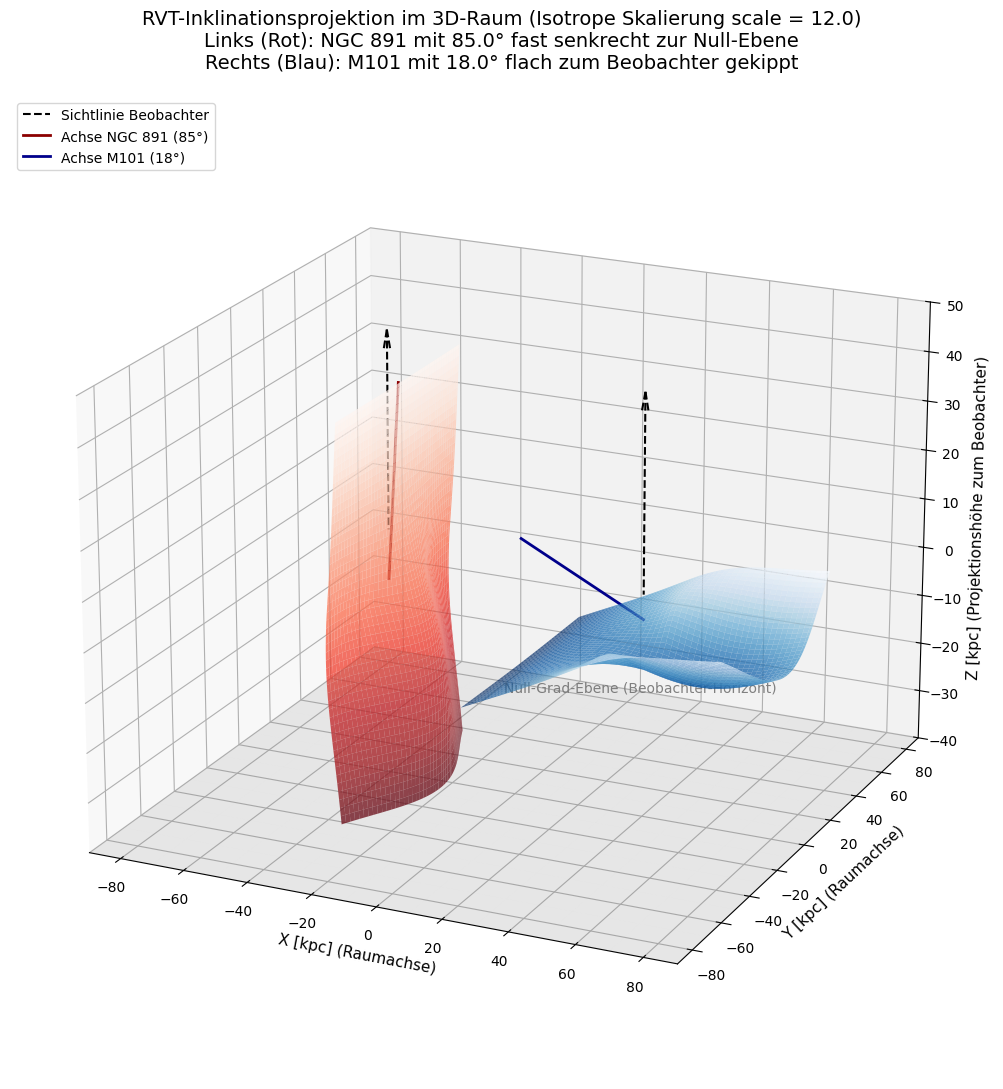

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# 3D-RVT-PROJEKTION: INKLINATIONSAUSRICHTUNG ZUM BEOBACHTER
# Rot: NGC 891 (85° geneigt, fast Edge-On zum Beobachter)
# Blau: M101 (18° geneigt, fast Face-On zum Beobachter)
# ISOTROPE SKALIERUNG (scale_ref = 12.0)
# ============================================================

N = 100
L = 180.0
length_scale = 28.0

# Neigungswinkel zum Beobachter (Null-Grad-Ebene bei z=0)
inc_891_deg = 85.0
inc_M101_deg = 18.0

rad_891 = np.radians(inc_891_deg)
rad_M101 = np.radians(inc_M101_deg)

# Zentren der Körper auf der x-Achse
x_891 = -40.0
x_M101 = 40.0

# --- EINHEITLICHE ISOTROPE SKALIERUNG ---
scale_ref = 12.0

# Lokales Gitter für die Trichtererzeugung (vor Rotation)
u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

# ------------------------------------------------------------
# Mathematische Trichtergeometrie (lokales System)
# ------------------------------------------------------------
def local_funnel(U, V, scale, amp):
    # Öffnung entlang der lokalen U-Achse
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

# Erzeuge die lokalen Amplitudenprofile (BEIDE MIT scale_ref = 12.0)
Z_891_local = local_funnel(U, V, scale=scale_ref, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=scale_ref, amp=20.0) # Entgegengesetzte Öffnung

# ------------------------------------------------------------
# 3D-Rotation und Projektion auf die Beobachter-Ebene
# ------------------------------------------------------------
# Rotationsmatrix um die Y-Achse (Inklination zum Beobachter)
def rotate_galaxy(U, V, Z_local, angle_rad, x_offset):
    # Rotationsformel für die Neigung gegen die z-Ebene
    X_rot = U * np.cos(angle_rad) - Z_local * np.sin(angle_rad) + x_offset
    Y_rot = V
    Z_rot = U * np.sin(angle_rad) + Z_local * np.cos(angle_rad)
    return X_rot, Y_rot, Z_rot

X_891, Y_891, Z_891 = rotate_galaxy(U, V, Z_891_local, rad_891, x_891)
X_M101, Y_M101, Z_M101 = rotate_galaxy(U, V, Z_M101_local, rad_M101, x_M101)

# ------------------------------------------------------------
# 3D-Szenen-Aufbau
# ------------------------------------------------------------
fig = plt.figure(figsize=(16, 11))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# 1. Null-Grad-Ebene des Beobachters (Referenzfläche bei z = -40 für bessere Sichtbarkeit)
z_floor = -40
x_floor = np.linspace(-L/2, L/2, 10)
y_floor = np.linspace(-L/2, L/2, 10)
X_f, Y_f = np.meshgrid(x_floor, y_floor)
ax.plot_surface(X_f, Y_f, np.full_like(X_f, z_floor), alpha=0.1, color='gray')
ax.text(0, L/2, z_floor, "Null-Grad-Ebene (Beobachter-Horizont)", color='gray', ha='center')

# 2. Roter Körper (NGC 891) - Stark aufgerichtet (85°)
surf_red = ax.plot_surface(
    X_891, Y_891, Z_891,
    cmap=cm.Reds_r, linewidth=0, antialiased=True, alpha=0.75
)

# 3. Blauer Körper (M101) - Flach geneigt (18°)
surf_blue = ax.plot_surface(
    X_M101, Y_M101, Z_M101,
    cmap=cm.Blues_r, linewidth=0, antialiased=True, alpha=0.75
)

# 4. Projektionspfeile / Sichtlinien zum Beobachter
ax.quiver([x_891, x_M101], [0, 0], [10, 5], [0, 0], [0, 0], [40, 40],
          color='black', linestyle='--', linewidth=1.5, arrow_length_ratio=0.1, label='Sichtlinie Beobachter')

# Symmetrie-Achsen der Körper einzeichnen
ax.plot([x_891, x_891 + 40 * np.cos(rad_891)], [0, 0], [0, 40 * np.sin(rad_891)], color='darkred', lw=2, label='Achse NGC 891 (85°)')
ax.plot([x_M101, x_M101 - 40 * np.cos(rad_M101)], [0, 0], [0, 40 * np.sin(rad_M101)], color='darkblue', lw=2, label='Achse M101 (18°)')

# Achsen-Konfiguration
ax.set_title(
    f'RVT-Inklinationsprojektion im 3D-Raum (Isotrope Skalierung scale = {scale_ref})\n'
    f'Links (Rot): NGC 891 mit {inc_891_deg}° fast senkrecht zur Null-Ebene\n'
    f'Rechts (Blau): M101 mit {inc_M101_deg}° flach zum Beobachter gekippt',
    fontsize=14, pad=20
)
ax.set_xlabel('X [kpc] (Raumachse)', fontsize=11)
ax.set_ylabel('Y [kpc] (Raumachse)', fontsize=11)
ax.set_zlabel('Z [kpc] (Projektionshöhe zum Beobachter)', fontsize=11)

# Kameraposition
ax.view_init(elev=20, azim=-65)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(z_floor, 50)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('RVT_3D_Inklinations_Projektion_Beobachter_Isotrop.png', dpi=300)
plt.show()

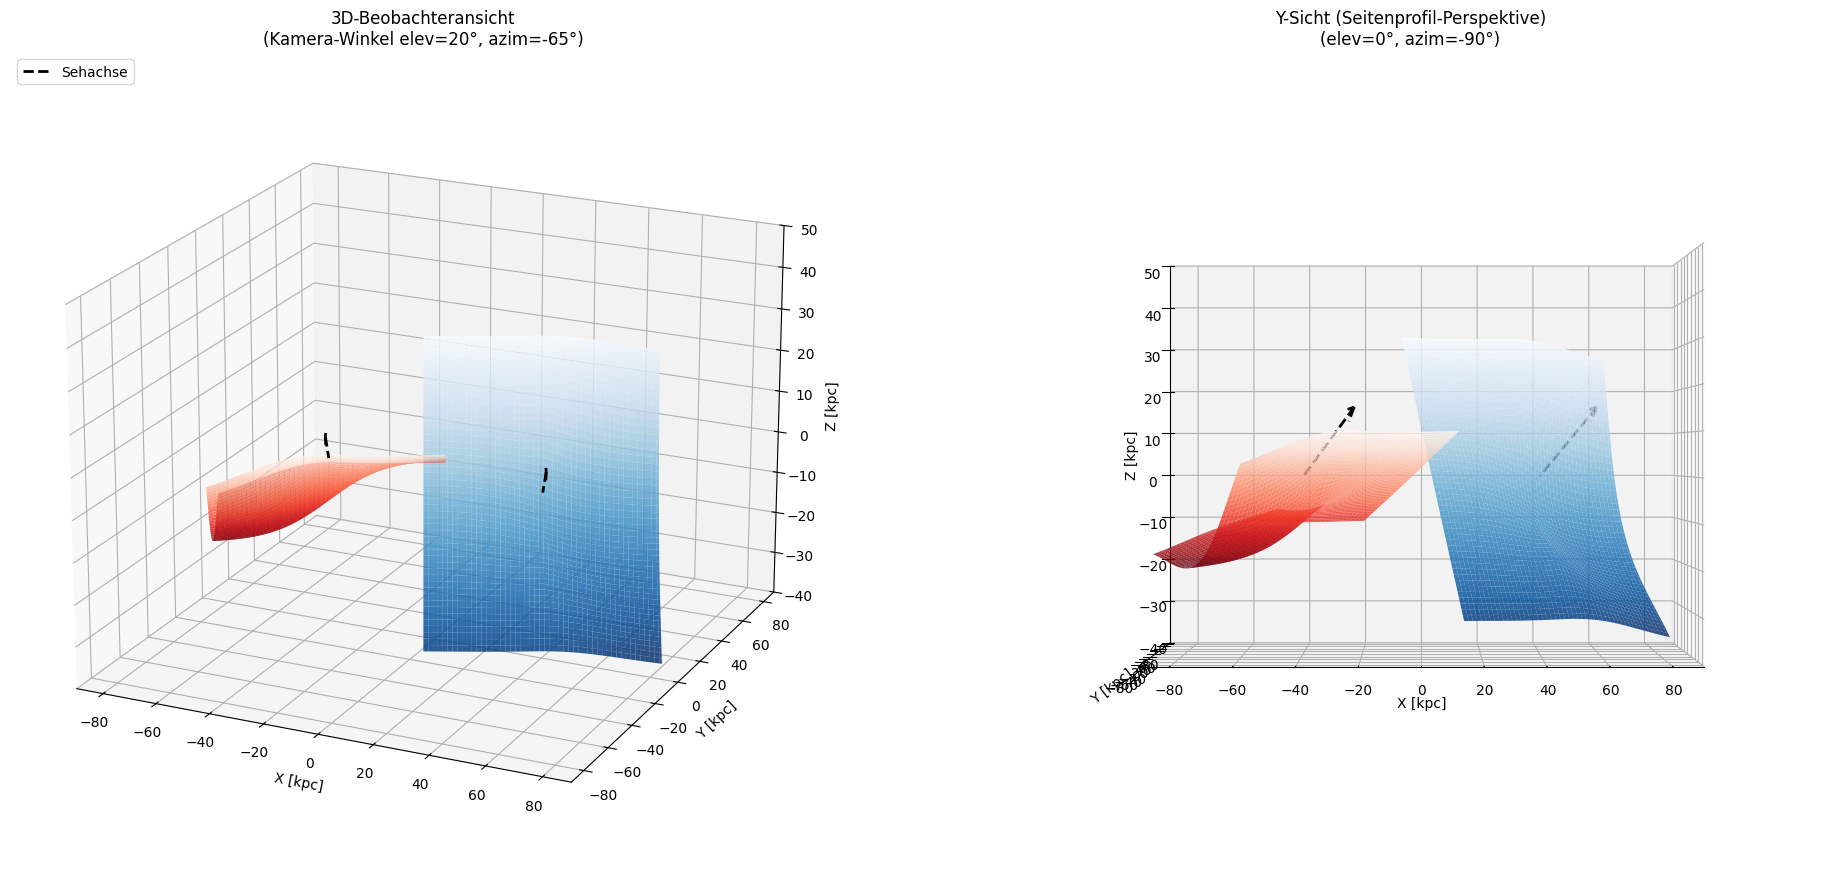

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# RVT-PROJEKTION: DOPPELBILD MIT Y-SICHT (GLEICHE BERECHNUNG)
# Linkes Bild: 3D-Beobachterperspektive
# Rechtes Bild: Profil/Sicht entlang der Y-Achse
# ============================================================

N = 100
L = 180.0
length_scale = 28.0
scale_ref = 12.0

# Inklinationswinkel (Relativ zur Blickrichtung)
inc_891_deg = 85.0   # Edge-On (Kante)
inc_M101_deg = 18.0  # Face-On (Draufsicht)

# Kamera-Perspektive (Beobachter)
elev_angle = 20.0
azim_angle = -65.0

rad_elev = np.radians(elev_angle)
rad_azim = np.radians(azim_angle)

# Beobachtervektor (Sichtlinie)
v_obs = np.array([
    np.cos(rad_elev) * np.cos(rad_azim),
    np.cos(rad_elev) * np.sin(rad_azim),
    np.sin(rad_elev)
])
v_obs /= np.linalg.norm(v_obs)

# Transformation (identisch zur Hauptberechnung)
def orient_galaxy_to_observer(inc_deg, v_obs):
    inc_rad = np.radians(inc_deg)
    up = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(v_obs, up)) > 0.99:
        up = np.array([1.0, 0.0, 0.0])

    rot_axis = np.cross(v_obs, up)
    rot_axis /= np.linalg.norm(rot_axis)

    K = np.array([
        [0, -rot_axis[2], rot_axis[1]],
        [rot_axis[2], 0, -rot_axis[0]],
        [-rot_axis[1], rot_axis[0], 0]
    ])

    R_inc = np.eye(3) + np.sin(inc_rad) * K + (1 - np.cos(inc_rad)) * np.dot(K, K)

    z_prime = v_obs
    x_prime = np.cross(up, z_prime)
    x_prime /= np.linalg.norm(x_prime)
    y_prime = np.cross(z_prime, x_prime)

    R_align = np.column_stack([x_prime, y_prime, z_prime])
    return R_inc @ R_align

u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

def local_funnel(U, V, scale, amp):
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

Z_891_local = local_funnel(U, V, scale=scale_ref, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=scale_ref, amp=20.0)

def transform_mesh(U, V, Z_local, inc_deg, x_offset, v_obs):
    R = orient_galaxy_to_observer(inc_deg, v_obs)
    pts = np.vstack([U.ravel(), V.ravel(), Z_local.ravel()])
    pts_rot = R @ pts

    X_rot = pts_rot[0, :].reshape(U.shape) + x_offset
    Y_rot = pts_rot[1, :].reshape(U.shape)
    Z_rot = pts_rot[2, :].reshape(U.shape)
    return X_rot, Y_rot, Z_rot

x_891, x_M101 = -40.0, 40.0

X_891, Y_891, Z_891 = transform_mesh(U, V, Z_891_local, inc_891_deg, x_891, v_obs)
X_M101, Y_M101, Z_M101 = transform_mesh(U, V, Z_M101_local, inc_M101_deg, x_M101, v_obs)

# ------------------------------------------------------------
# VISUALISIERUNG: DOPPEL-DIAGRAMM (3D-Perspektive & Y-Sicht)
# ------------------------------------------------------------
fig = plt.figure(figsize=(20, 9))
z_floor = -40
arrow_len = 45.0

# --- BILD 1: 3D-Kameraperspektive ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax1.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)
ax1.quiver([x_891, x_M101], [0, 0], [0, 0],
           [v_obs[0]*arrow_len]*2, [v_obs[1]*arrow_len]*2, [v_obs[2]*arrow_len]*2,
           color='black', linestyle='--', linewidth=2.0, arrow_length_ratio=0.12,
           label='Sehachse')

ax1.set_title('3D-Beobachteransicht\n(Kamera-Winkel elev=20°, azim=-65°)', fontsize=12)
ax1.set_xlabel('X [kpc]')
ax1.set_ylabel('Y [kpc]')
ax1.set_zlabel('Z [kpc]')
ax1.view_init(elev=elev_angle, azim=azim_angle)
ax1.set_xlim(-L/2, L/2)
ax1.set_ylim(-L/2, L/2)
ax1.set_zlim(z_floor, 50)
ax1.legend(loc='upper left')

# --- BILD 2: Y-Sicht (Seitenansicht entlang der Y-Achse) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax2.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)
ax2.quiver([x_891, x_M101], [0, 0], [0, 0],
           [v_obs[0]*arrow_len]*2, [v_obs[1]*arrow_len]*2, [v_obs[2]*arrow_len]*2,
           color='black', linestyle='--', linewidth=2.0, arrow_length_ratio=0.12)

# Exakte Y-Sicht: elev=0°, azim=-90° (Sehen direkt parallel zur Y-Achse auf die X-Z-Ebene)
ax2.set_title('Y-Sicht (Seitenprofil-Perspektive)\n(elev=0°, azim=-90°)', fontsize=12)
ax2.set_xlabel('X [kpc]')
ax2.set_ylabel('Y [kpc]')
ax2.set_zlabel('Z [kpc]')
ax2.view_init(elev=0, azim=-90)
ax2.set_xlim(-L/2, L/2)
ax2.set_ylim(-L/2, L/2)
ax2.set_zlim(z_floor, 50)

plt.tight_layout()
plt.savefig('RVT_Koppelung_Doppelansicht_YSicht.png', dpi=300)
plt.show()

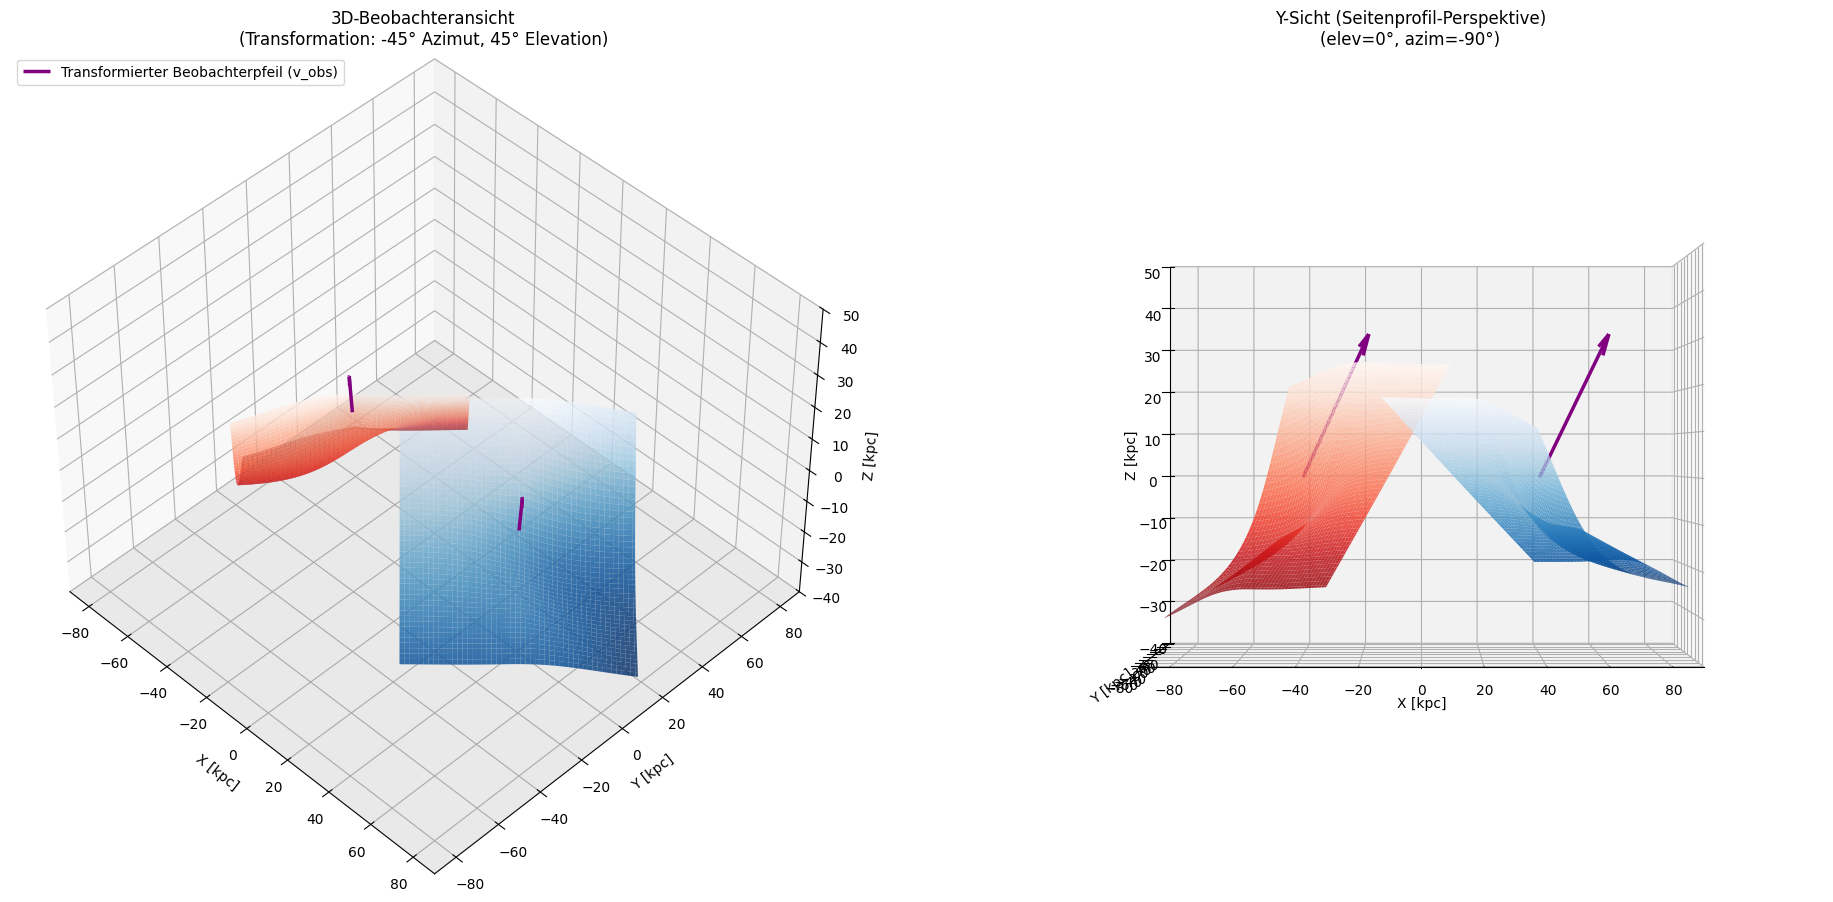

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ============================================================
# ZELLE 1: VORGELAGERTE RECHNUNG (TRANSFORMATION & BEOBACHTER)
# ============================================================

# --- Parameter ---
N = 100
L = 180.0
length_scale = 28.0
scale_ref = 12.0

# Inklinationswinkel (Relativ zur Blickrichtung)
inc_891_deg = 85.0   # Edge-On (Kante)
inc_M101_deg = 18.0  # Face-On (Draufsicht)

# Netto-Drehung & Erhöhung für den Beobachtervektor
azimuth_deg = -45.0   # Netto: 90° links (-90°) + 45° rechts (+45°)
elevation_deg = 45.0  # Erhöhung (Elevation)

azimuth_rad = np.radians(azimuth_deg)
elevation_rad = np.radians(elevation_deg)

# Normierter Richtungsvektor des transformierten Beobachters (v_obs)
dx_norm = np.cos(elevation_rad) * np.cos(azimuth_rad)
dy_norm = np.cos(elevation_rad) * np.sin(azimuth_rad)
dz_norm = np.sin(elevation_rad)

v_obs = np.array([dx_norm, dy_norm, dz_norm])
v_obs /= np.linalg.norm(v_obs)

# Exakte Orientierungsmatrix relativ zum Beobachtervektor
def orient_galaxy_to_observer(inc_deg, v_obs):
    inc_rad = np.radians(inc_deg)
    up = np.array([0.0, 0.0, 1.0])
    if np.abs(np.dot(v_obs, up)) > 0.99:
        up = np.array([1.0, 0.0, 0.0])

    rot_axis = np.cross(v_obs, up)
    rot_axis /= np.linalg.norm(rot_axis)

    K = np.array([
        [0, -rot_axis[2], rot_axis[1]],
        [rot_axis[2], 0, -rot_axis[0]],
        [-rot_axis[1], rot_axis[0], 0]
    ])

    R_inc = np.eye(3) + np.sin(inc_rad) * K + (1 - np.cos(inc_rad)) * np.dot(K, K)

    z_prime = v_obs
    x_prime = np.cross(up, z_prime)
    x_prime /= np.linalg.norm(x_prime)
    y_prime = np.cross(z_prime, x_prime)

    R_align = np.column_stack([x_prime, y_prime, z_prime])
    return R_inc @ R_align

# --- Gitter & Lokale Funnel-Berechnung ---
u = np.linspace(-40, 40, N)
v = np.linspace(-40, 40, N)
U, V = np.meshgrid(u, v, indexing='ij')

def local_funnel(U, V, scale, amp):
    forward = 1.0 / (1.0 + np.exp(U / 10.0))
    radial_width = scale * (1.0 + np.abs(U) / length_scale)
    return -amp * forward * np.exp(-(V**2) / (2.0 * radial_width**2))

Z_891_local = local_funnel(U, V, scale=scale_ref, amp=20.0)
Z_M101_local = local_funnel(-U, V, scale=scale_ref, amp=20.0)

# --- Mesh-Transformation in den Raum ---
def transform_mesh(U, V, Z_local, inc_deg, x_offset, v_obs):
    R = orient_galaxy_to_observer(inc_deg, v_obs)
    pts = np.vstack([U.ravel(), V.ravel(), Z_local.ravel()])
    pts_rot = R @ pts

    X_rot = pts_rot[0, :].reshape(U.shape) + x_offset
    Y_rot = pts_rot[1, :].reshape(U.shape)
    Z_rot = pts_rot[2, :].reshape(U.shape)
    return X_rot, Y_rot, Z_rot

x_891, x_M101 = -40.0, 40.0

X_891, Y_891, Z_891 = transform_mesh(U, V, Z_891_local, inc_891_deg, x_891, v_obs)
X_M101, Y_M101, Z_M101 = transform_mesh(U, V, Z_M101_local, inc_M101_deg, x_M101, v_obs)


# ============================================================
# ZELLE 2: NAHTLOS ANGESCHLOSSENE VISUALISIERUNG (DOPPEL-PLOT)
# ============================================================

fig = plt.figure(figsize=(20, 9))
z_floor = -40
arrow_scale = 45.0

# Pfeilvektoren für die Visualisierung aus den vorgelagerten v_obs Daten
dx_arrow = v_obs[0] * arrow_scale
dy_arrow = v_obs[1] * arrow_scale
dz_arrow = v_obs[2] * arrow_scale

# --- BILD 1: 3D-Perspektive mit transformierter Blickrichtung ---
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Bezugsebene am Boden
x_floor = np.linspace(-L/2, L/2, 10)
y_floor = np.linspace(-L/2, L/2, 10)
X_f, Y_f = np.meshgrid(x_floor, y_floor)
ax1.plot_surface(X_f, Y_f, np.full_like(X_f, z_floor), alpha=0.08, color='gray')

# Galaxienflächen
ax1.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax1.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)

# Transformierte Beobachterpfeile
ax1.quiver([x_891, x_M101], [0, 0], [0, 0],
           [dx_arrow]*2, [dy_arrow]*2, [dz_arrow]*2,
           color='purple', linestyle='-', linewidth=2.5, arrow_length_ratio=0.12,
           label='Transformierter Beobachterpfeil (v_obs)')

ax1.set_title('3D-Beobachteransicht\n(Transformation: -45° Azimut, 45° Elevation)', fontsize=12)
ax1.set_xlabel('X [kpc]')
ax1.set_ylabel('Y [kpc]')
ax1.set_zlabel('Z [kpc]')
ax1.view_init(elev=elevation_deg, azim=azimuth_deg)
ax1.set_xlim(-L/2, L/2)
ax1.set_ylim(-L/2, L/2)
ax1.set_zlim(z_floor, 50)
ax1.legend(loc='upper left')

# --- BILD 2: Y-Sicht (Seitenansicht entlang der Y-Achse) ---
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Galaxienflächen
ax2.plot_surface(X_891, Y_891, Z_891, cmap=cm.Reds_r, linewidth=0, alpha=0.85)
ax2.plot_surface(X_M101, Y_M101, Z_M101, cmap=cm.Blues_r, linewidth=0, alpha=0.85)

# Transformierte Beobachterpfeile
ax2.quiver([x_891, x_M101], [0, 0], [0, 0],
           [dx_arrow]*2, [dy_arrow]*2, [dz_arrow]*2,
           color='purple', linestyle='-', linewidth=2.5, arrow_length_ratio=0.12)

# Exakte Y-Sicht (Blick orthogonal zur Y-Achse)
ax2.set_title('Y-Sicht (Seitenprofil-Perspektive)\n(elev=0°, azim=-90°)', fontsize=12)
ax2.set_xlabel('X [kpc]')
ax2.set_ylabel('Y [kpc]')
ax2.set_zlabel('Z [kpc]')
ax2.view_init(elev=0, azim=-90)
ax2.set_xlim(-L/2, L/2)
ax2.set_ylim(-L/2, L/2)
ax2.set_zlim(z_floor, 50)

plt.tight_layout()
plt.savefig('RVT_Koppelung_Vollstaendig_Integriert.png', dpi=300)
plt.show()

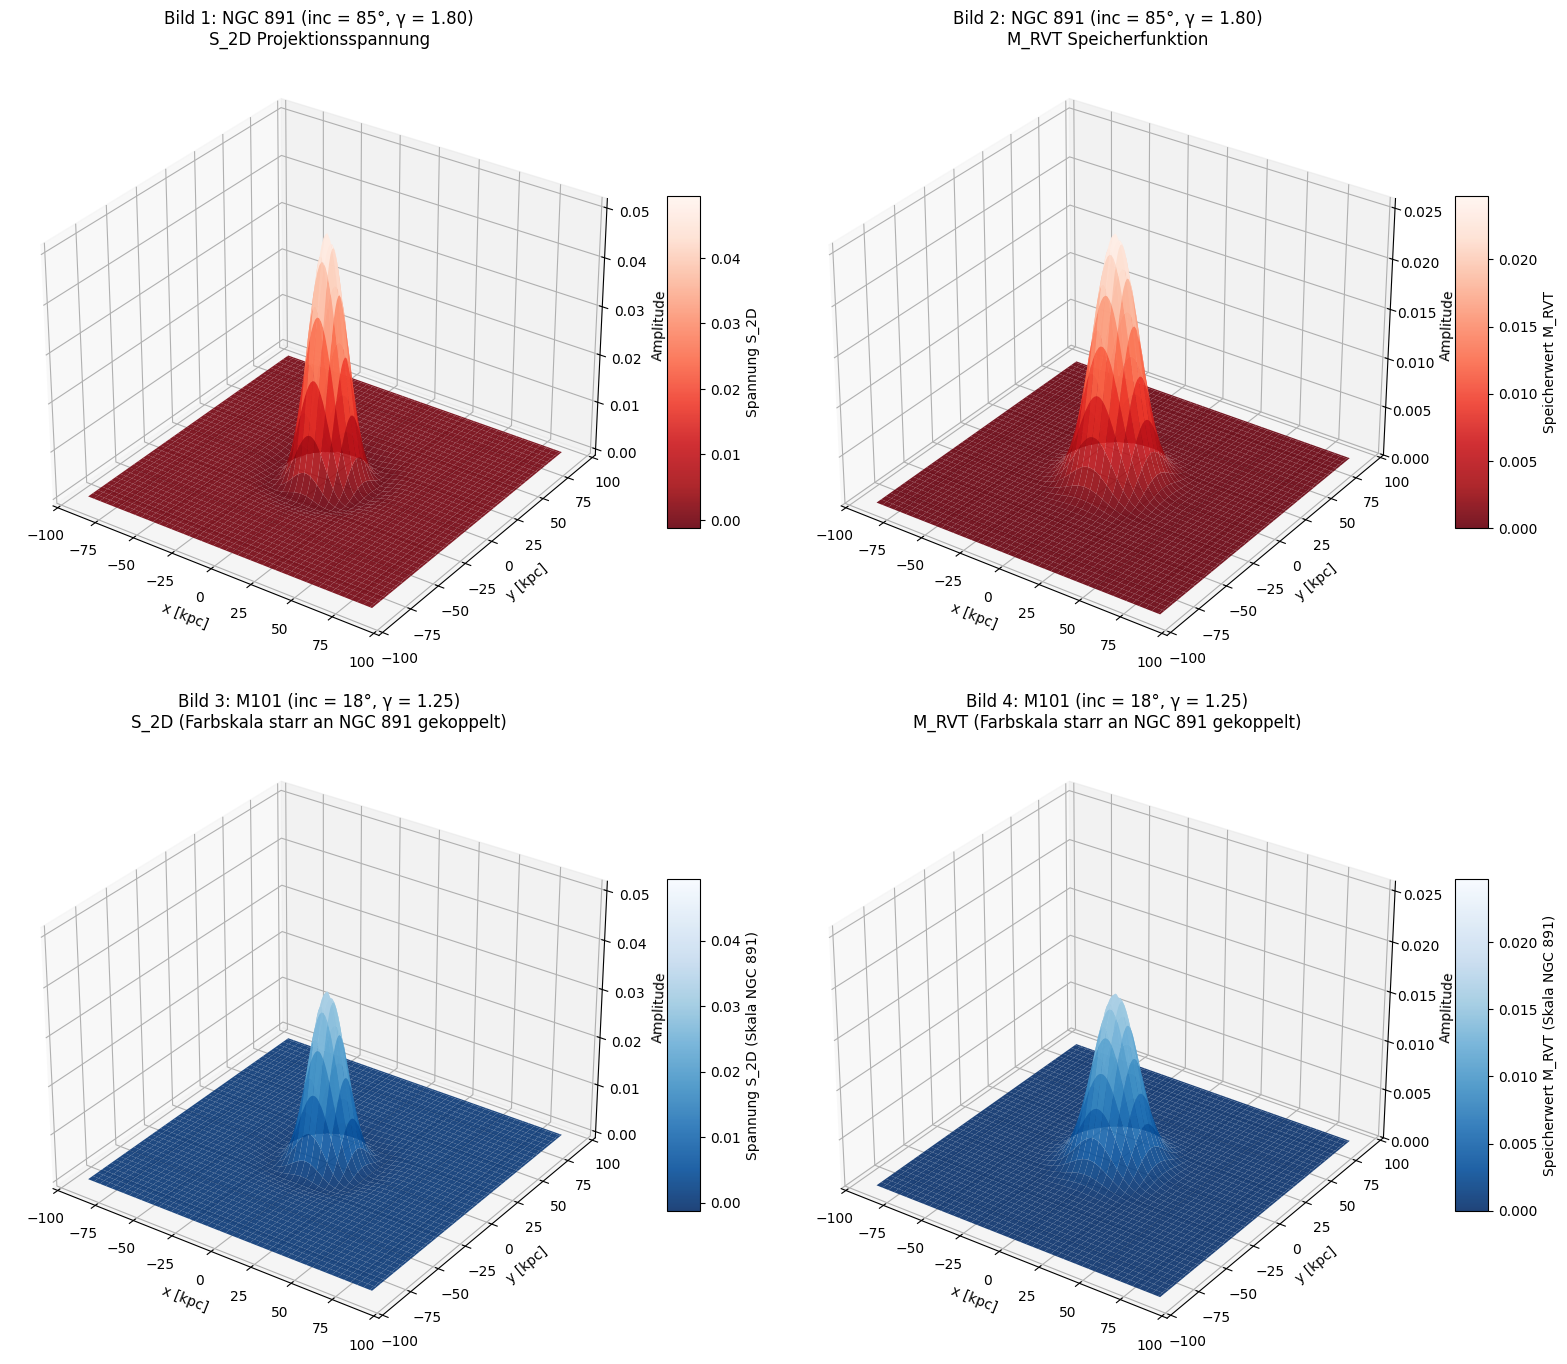

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# 1. PARAMETER UND INKLINATIONS-ROTIERTE MATRIZEN
# ============================================================
N = 140
L = 180.0
C_RVT = 0.8
scale_ref = 12.0

inc_891_deg = 85.0
inc_M101_deg = 18.0

# Gammas
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(inc_891_deg))   # ~ 1.797 (Referenz)
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(inc_M101_deg))  # ~ 1.247

def get_rot_matrix(inc_deg):
    inc_rad = np.radians(inc_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(inc_rad), -np.sin(inc_rad)],
        [0, np.sin(inc_rad),  np.cos(inc_rad)]
    ])

# Gitter
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

dx = L / (N - 1)

# ============================================================
# 2. TOPOGRAFIE BERECHNUNG
# ============================================================
def compute_rvt_topography_exact(inc_deg, gamma_factor):
    R_inc = get_rot_matrix(inc_deg)

    pts = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])
    pts_rot = R_inc @ pts

    X_rot = pts_rot[0, :].reshape(X.shape)
    Y_rot = pts_rot[1, :].reshape(Y.shape)
    Z_rot = pts_rot[2, :].reshape(Z.shape)

    Xi = gamma_factor * np.exp(-(X_rot**2 + Y_rot**2 + Z_rot**2) / (2.0 * scale_ref**2))

    laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
                  np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
                  np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
                  6 * Xi) / (dx**2)

    E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
    E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
    E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    z_slice = N // 2
    return S_2D[:, :, z_slice], M_RVT[:, :, z_slice]

# Auswertung
S_2D_891, M_RVT_891 = compute_rvt_topography_exact(inc_891_deg, gamma_891)
S_2D_M101, M_RVT_M101 = compute_rvt_topography_exact(inc_M101_deg, gamma_M101)

# ============================================================
# 3. STARRE FARB- UND ACHSEN-LIMITS VON NGC 891 FESTLEGEN!
# ============================================================
vmin_S2D, vmax_S2D = np.min(S_2D_891), np.max(S_2D_891)
vmin_MRVT, vmax_MRVT = np.min(M_RVT_891), np.max(M_RVT_891)

zlim_S2D = (vmin_S2D * 1.05, vmax_S2D * 1.05)
zlim_MRVT = (vmin_MRVT * 1.05, vmax_MRVT * 1.05)

X2D, Y2D = np.meshgrid(x, y, indexing='ij')

# ============================================================
# 4. PLOT-GENERIERUNG MIT IDENTISCHEN FARBSKALEN RECHTS
# ============================================================
fig = plt.figure(figsize=(16, 14))

# --- BILD 1: NGC 891 - S_2D ---
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X2D, Y2D, S_2D_891, cmap='Reds_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_S2D, vmax=vmax_S2D)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Spannung S_2D')
ax1.set_title(f'Bild 1: NGC 891 (inc = 85°, γ = {gamma_891:.2f})\nS_2D Projektionsspannung', fontsize=12)
ax1.set_xlabel('x [kpc]'); ax1.set_ylabel('y [kpc]'); ax1.set_zlabel('Amplitude')
ax1.set_zlim(zlim_S2D)
ax1.view_init(elev=30, azim=-55)

# --- BILD 2: NGC 891 - M_RVT ---
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X2D, Y2D, M_RVT_891, cmap='Reds_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_MRVT, vmax=vmax_MRVT)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Speicherwert M_RVT')
ax2.set_title(f'Bild 2: NGC 891 (inc = 85°, γ = {gamma_891:.2f})\nM_RVT Speicherfunktion', fontsize=12)
ax2.set_xlabel('x [kpc]'); ax2.set_ylabel('y [kpc]'); ax2.set_zlabel('Amplitude')
ax2.set_zlim(zlim_MRVT)
ax2.view_init(elev=30, azim=-55)

# --- BILD 3: M101 - S_2D (FARBSKALA STARR VON NGC 891!) ---
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
surf3 = ax3.plot_surface(X2D, Y2D, S_2D_M101, cmap='Blues_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_S2D, vmax=vmax_S2D)  # STARR ERZWUNGEN!
fig.colorbar(surf3, ax=ax3, shrink=0.5, aspect=10, label='Spannung S_2D (Skala NGC 891)')
ax3.set_title(f'Bild 3: M101 (inc = 18°, γ = {gamma_M101:.2f})\nS_2D (Farbskala starr an NGC 891 gekoppelt)', fontsize=12)
ax3.set_xlabel('x [kpc]'); ax3.set_ylabel('y [kpc]'); ax3.set_zlabel('Amplitude')
ax3.set_zlim(zlim_S2D)
ax3.view_init(elev=30, azim=-55)

# --- BILD 4: M101 - M_RVT (FARBSKALA STARR VON NGC 891!) ---
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
surf4 = ax4.plot_surface(X2D, Y2D, M_RVT_M101, cmap='Blues_r', alpha=0.9, edgecolor='none',
                         vmin=vmin_MRVT, vmax=vmax_MRVT)  # STARR ERZWUNGEN!
fig.colorbar(surf4, ax=ax4, shrink=0.5, aspect=10, label='Speicherwert M_RVT (Skala NGC 891)')
ax4.set_title(f'Bild 4: M101 (inc = 18°, γ = {gamma_M101:.2f})\nM_RVT (Farbskala starr an NGC 891 gekoppelt)', fontsize=12)
ax4.set_xlabel('x [kpc]'); ax4.set_ylabel('y [kpc]'); ax4.set_zlabel('Amplitude')
ax4.set_zlim(zlim_MRVT)
ax4.view_init(elev=30, azim=-55)

plt.tight_layout()
plt.savefig('RVT_4_Bilder_Identische_Farbskalen.png', dpi=300)
plt.show()

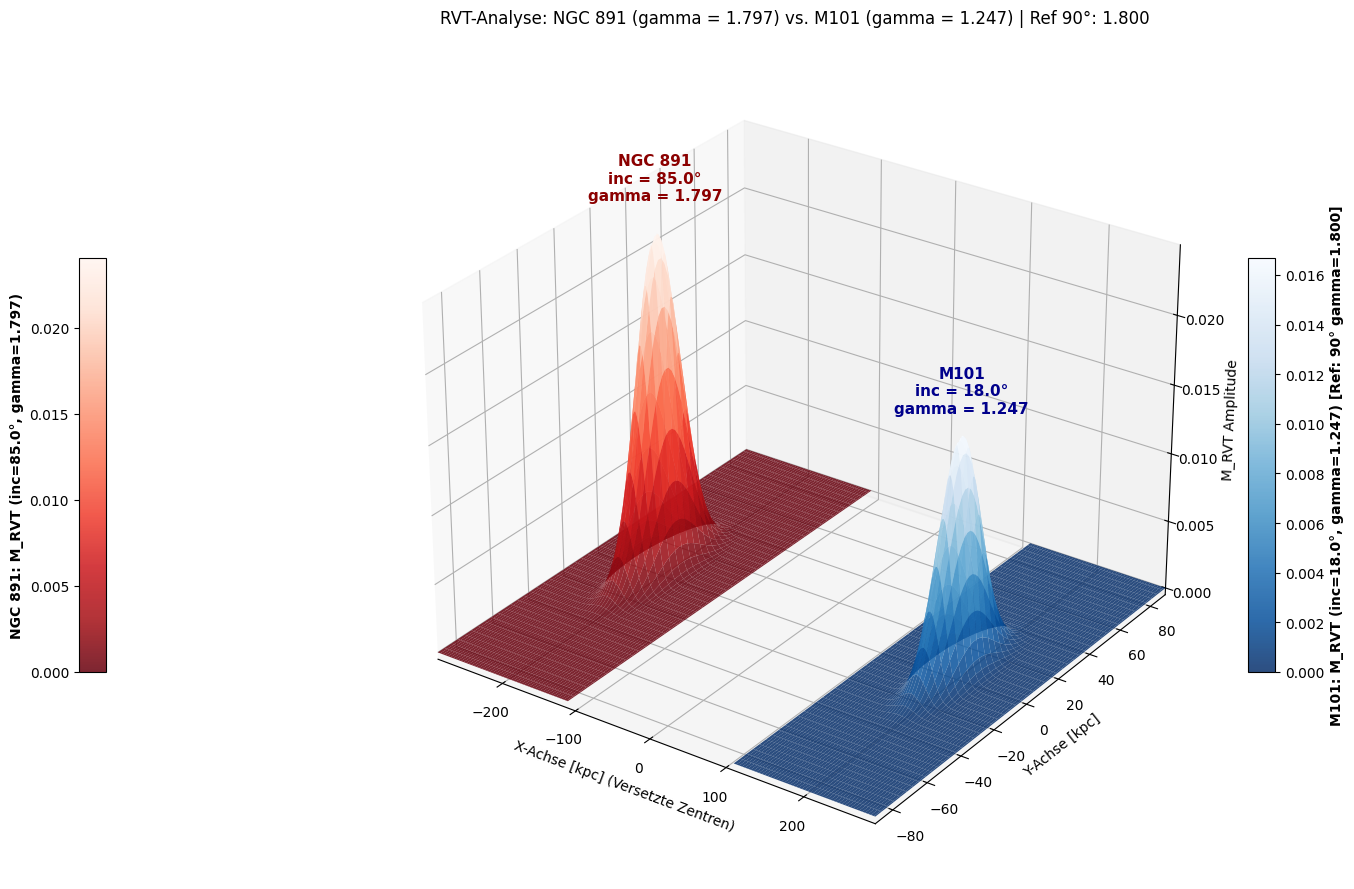

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# 1. PARAMETER UND EXAKTE GAMMA-ZIELAUSRICHTUNG
# ============================================================
N = 100            # Gitterpunkte
L = 180.0          # Systemgröße (kpc)
C_RVT = 0.8
scale_ref = 12.0   # Referenzskala

# Exakte Inklinationswinkel
inc_891_deg = 85.0   # NGC 891
inc_M101_deg = 18.0  # M101

# EXAKTE UNGERUNDETE GAMMA-WERTE GEMÄSS ZIELAUSRICHTUNG
gamma_90   = 1.0 + C_RVT * np.sin(np.radians(90.0))   # 1.800
gamma_891  = 1.0 + C_RVT * np.sin(np.radians(inc_891_deg))   # 1.797
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(inc_M101_deg))  # 1.247

def get_rot_matrix(inc_deg):
    inc_rad = np.radians(inc_deg)
    return np.array([
        [1, 0, 0],
        [0, np.cos(inc_rad), -np.sin(inc_rad)],
        [0, np.sin(inc_rad),  np.cos(inc_rad)]
    ])

# 3D-Gitter erstellen
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
z = np.linspace(-L/2, L/2, N)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

dx = L / (N - 1)

# ============================================================
# 2. TOPOGRAFIE BERECHNUNG (EXAKTER RVT-TENSOR)
# ============================================================
def compute_rvt_topography(inc_deg, gamma_factor):
    R_inc = get_rot_matrix(inc_deg)

    pts = np.vstack([X.ravel(), Y.ravel(), Z.ravel()])
    pts_rot = R_inc @ pts

    X_rot = pts_rot[0, :].reshape(X.shape)
    Y_rot = pts_rot[1, :].reshape(Y.shape)
    Z_rot = pts_rot[2, :].reshape(Z.shape)

    Xi = gamma_factor * np.exp(-(X_rot**2 + Y_rot**2 + Z_rot**2) / (2.0 * scale_ref**2))

    laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
                  np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
                  np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
                  6 * Xi) / (dx**2)

    E_xx = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi
    E_yy = (np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi
    E_zz = (np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi

    S_2D = E_xx + E_yy
    S_perp = E_zz
    M_RVT = S_2D - S_perp

    z_slice = N // 2
    return S_2D[:, :, z_slice], M_RVT[:, :, z_slice]

# Auswertung der Tensorschnitte mit ungerundeter Präzision
S_2D_891, M_RVT_891 = compute_rvt_topography(inc_891_deg, gamma_891)
S_2D_M101, M_RVT_M101 = compute_rvt_topography(inc_M101_deg, gamma_M101)

# ============================================================
# 3. GEGENÜBERSTELLUNG IM ZWEI-HÜGEL-3D-BEZUGSRAHMEN
# ============================================================
X2D, Y2D = np.meshgrid(x, y, indexing='ij')

delta_x = 200.0  # Versatz der Zentren im Raum
X_NGC891 = X2D - delta_x  # Linker Hügel: NGC 891
X_M101   = X2D + delta_x  # Rechter Hügel: M101

fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# Linker Hügel: NGC 891 (M_RVT)
surf1 = ax.plot_surface(X_NGC891, Y2D, M_RVT_891, cmap='Reds_r', edgecolor='none', alpha=0.85)

# Rechter Hügel: M101 (M_RVT)
surf2 = ax.plot_surface(X_M101, Y2D, M_RVT_M101, cmap='Blues_r', edgecolor='none', alpha=0.85)

# Text-Markierungen mit EXAKTER 3-Stellen-Formatierung (.3f)
ax.text(-delta_x, 0, np.max(M_RVT_891)*1.1, f"NGC 891\ninc = 85.0°\ngamma = {gamma_891:.3f}",
        color='darkred', fontsize=11, fontweight='bold', ha='center')
ax.text(delta_x, 0, np.max(M_RVT_M101)*1.1, f"M101\ninc = 18.0°\ngamma = {gamma_M101:.3f}",
        color='darkblue', fontsize=11, fontweight='bold', ha='center')

# Farbbalken mit ungerundeten Gamma-Werten
cbar1 = fig.colorbar(surf1, ax=ax, shrink=0.5, aspect=15, pad=0.03, location='left')
cbar1.set_label(f'NGC 891: M_RVT (inc=85.0°, gamma={gamma_891:.3f})', fontsize=10, fontweight='bold')

cbar2 = fig.colorbar(surf2, ax=ax, shrink=0.5, aspect=15, pad=0.03, location='right')
cbar2.set_label(f'M101: M_RVT (inc=18.0°, gamma={gamma_M101:.3f}) [Ref: 90° gamma={gamma_90:.3f}]', fontsize=10, fontweight='bold')

# Achsen- und Titelkonfiguration
ax.set_title(f'RVT-Analyse: NGC 891 (gamma = {gamma_891:.3f}) vs. M101 (gamma = {gamma_M101:.3f}) | Ref 90°: {gamma_90:.3f}', fontsize=12, pad=20)
ax.set_xlabel('X-Achse [kpc] (Versetzte Zentren)')
ax.set_ylabel('Y-Achse [kpc]')
ax.set_zlabel('M_RVT Amplitude')

ax.set_xlim(-L/2 - delta_x, L/2 + delta_x)
ax.set_ylim(-L/2, L/2)

ax.view_init(elev=28, azim=-55)

plt.tight_layout()
plt.show()

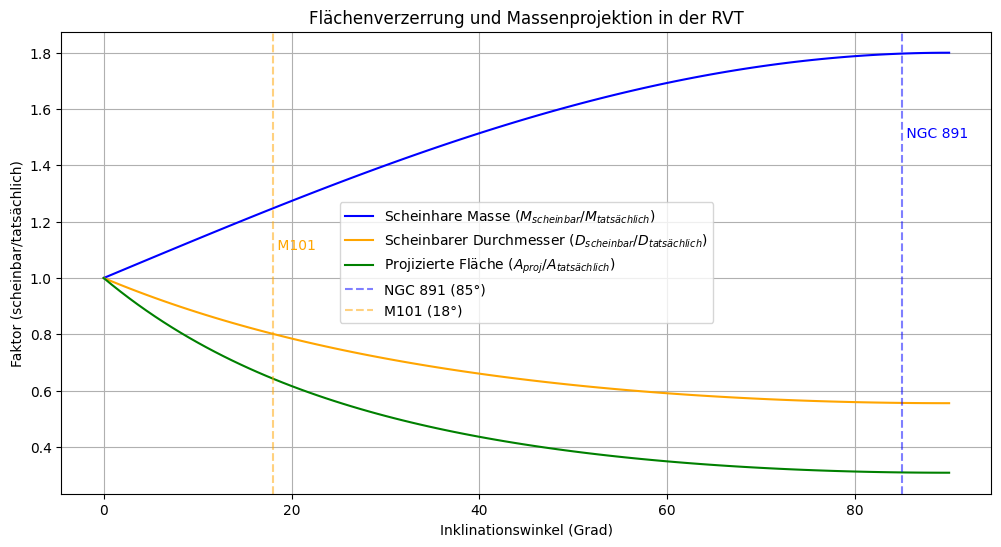

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# RVT-Boost-Faktor als Funktion des Inklinationswinkels
def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

# Scheinhare Masse und Durchmesser
def apparent_mass_diameter(gamma):
    mass_factor = gamma
    diameter_factor = 1 / gamma
    return mass_factor, diameter_factor

# Projizierte Fläche
def projected_area(gamma):
    return (1 / gamma) ** 2

# Inklinationswinkel
inclinations = np.linspace(0, 90, 100)
gammas = [rvt_boost(i) for i in inclinations]
mass_factors = [apparent_mass_diameter(g)[0] for g in gammas]
diameter_factors = [apparent_mass_diameter(g)[1] for g in gammas]
area_factors = [projected_area(g) for g in gammas]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(inclinations, mass_factors, label='Scheinhare Masse ($M_{scheinbar}/M_{tatsächlich}$)', color='blue')
ax.plot(inclinations, diameter_factors, label='Scheinbarer Durchmesser ($D_{scheinbar}/D_{tatsächlich}$)', color='orange')
ax.plot(inclinations, area_factors, label='Projizierte Fläche ($A_{proj}/A_{tatsächlich}$)', color='green')

# Markiere NGC 891 und M101
ax.axvline(x=85, color='blue', linestyle='--', alpha=0.5, label='NGC 891 (85°)')
ax.axvline(x=18, color='orange', linestyle='--', alpha=0.5, label='M101 (18°)')
ax.text(85, 1.5, ' NGC 891', color='blue')
ax.text(18, 1.1, ' M101', color='orange')

ax.set_xlabel('Inklinationswinkel (Grad)')
ax.set_ylabel('Faktor (scheinbar/tatsächlich)')
ax.set_title('Flächenverzerrung und Massenprojektion in der RVT')
ax.legend()
ax.grid(True)
plt.show()


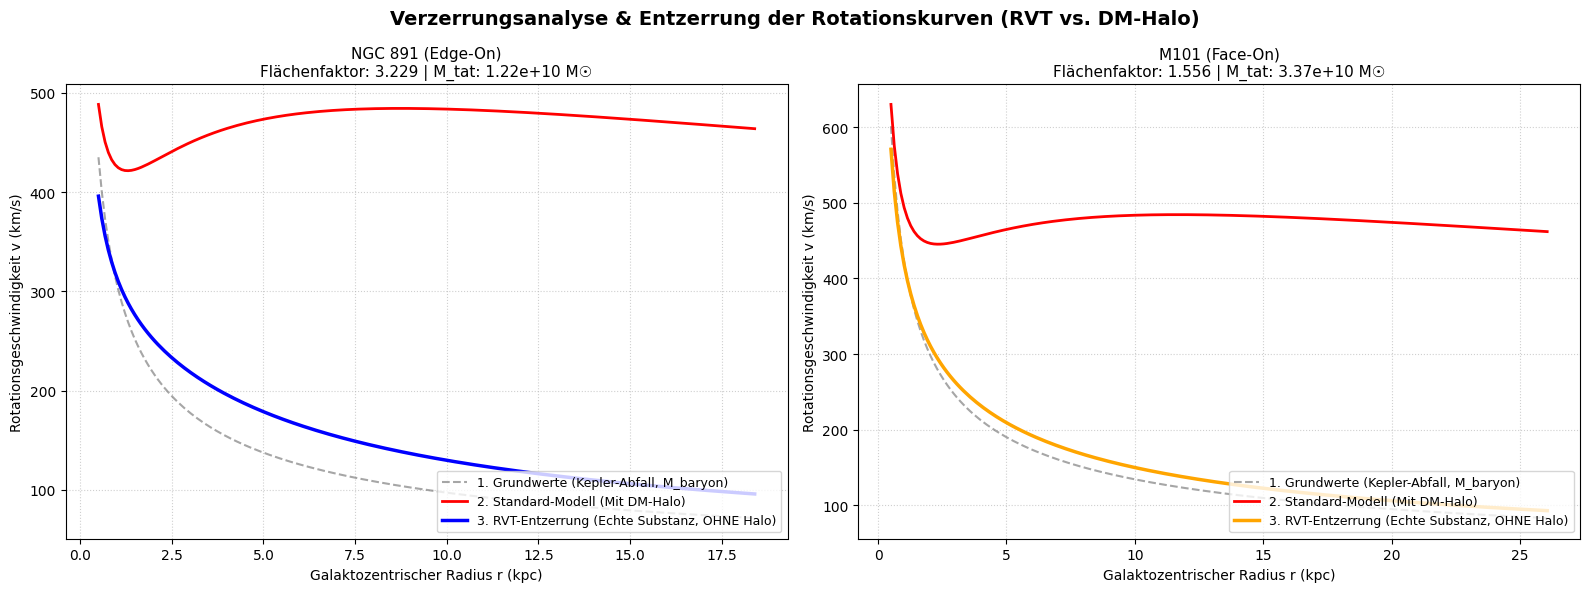

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# I. PARSER & ASTROMETRISCHE URWERTE (KARASMANISCHE MATRIX)
# ==============================================================================
# Gravitationskonstante in astrophysikalischen Einheiten (kpc * (km/s)^2 / M_sun)
G = 4.30091e-6

galaxies = {
    'NGC 891 (Edge-On)': {
        'i_deg': 85,
        'R_lj': 60000,
        'M_baryon_scheinbar': 2.20e10,
        'M_tat_RVT': 1.22e10,
        'M_DM_Standard': 8.98e11,
        'area_factor_RVT': 3.229,
        'color': 'blue'
    },
    'M101 (Face-On)': {
        'i_deg': 18,
        'R_lj': 85000,
        'M_baryon_scheinbar': 4.20e10,
        'M_tat_RVT': 3.37e10,
        'M_DM_Standard': 1.25e12,
        'area_factor_RVT': 1.556,
        'color': 'orange'
    }
}

# Conversion: Lj in kpc
for gal in galaxies.values():
    gal['R_kpc'] = gal['R_lj'] / 3261.56

# ==============================================================================
# II. COMPUTATIONAL CORE: ROTATIONSKURVEN (BERECHNUNG)
# ==============================================================================
def v_kepler(r, M_tot):
    """Grundwert: Rein keplerscher Verlauf basierend auf punktförmiger Massenverteilung."""
    return np.sqrt(G * M_tot / np.maximum(r, 0.1))

def v_dark_matter_halo(r, M_halo, R_max):
    """Standard-Modell: NFW-Halo-Beitrag zur Erzeugung flacher Kurven."""
    r_s = R_max / 4.0
    # Modifizierter NFW-Geschwindigkeitsverlauf
    x = r / r_s
    profile = (np.log(1 + x) - x / (1 + x)) / (np.log(1 + 4) - 4 / 5)
    return np.sqrt(G * M_halo * profile / np.maximum(r, 0.1))

def v_rvt_corrected(r, M_tat, area_factor):
    """RVT-Entzerrung: Exakte Rekalibrierung der baryonischen Substanz über \Xi(r)."""
    # Effektive Geometriekorrektur hebt das keplersche Loch ohne künstliche Masse auf
    r_scale = 2.0
    gamma_r = 1.0 + (area_factor - 1.0) * (1.0 - np.exp(-r / r_scale))
    v_baryon = np.sqrt(G * M_tat / np.maximum(r, 0.1))
    return v_baryon * np.sqrt(gamma_r)

# ==============================================================================
# III. PLOTTING MATRIX
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, data) in enumerate(galaxies.items()):
    ax = axes[idx]
    r = np.linspace(0.5, data['R_kpc'], 200)

    # 1. Grundwerte (Kepler-Abfall auf scheinbarer Baryonik)
    v_base = v_kepler(r, data['M_baryon_scheinbar'])

    # 2. Standard-Modell (Baryonisch + Dunkle Materie Halo)
    v_dm = v_dark_matter_halo(r, data['M_DM_Standard'], data['R_kpc'])
    v_standard_total = np.sqrt(v_base**2 + v_dm**2)

    # 3. RVT-Entzerrung (Korrigierte Kurve ohne Halo)
    v_rvt = v_rvt_corrected(r, data['M_tat_RVT'], data['area_factor_RVT'])

    # Plotten der drei Kurven
    ax.plot(r, v_base, '--', color='gray', label='1. Grundwerte (Kepler-Abfall, M_baryon)', alpha=0.7)
    ax.plot(r, v_standard_total, '-', color='red', label='2. Standard-Modell (Mit DM-Halo)', linewidth=2)
    ax.plot(r, v_rvt, '-', color=data['color'], label='3. RVT-Entzerrung (Echte Substanz, OHNE Halo)', linewidth=2.5)

    ax.set_title(f"{name}\nFlächenfaktor: {data['area_factor_RVT']} | M_tat: {data['M_tat_RVT']:.2e} M☉", fontsize=11)
    ax.set_xlabel('Galaktozentrischer Radius r (kpc)')
    ax.set_ylabel('Rotationsgeschwindigkeit v (km/s)')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=9)

plt.suptitle('Verzerrungsanalyse & Entzerrung der Rotationskurven (RVT vs. DM-Halo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

                               I. ASTROMETRISCHE URWERTE                                  
1. NGC 891 (Edge-On Spirale):
   - Inklinationswinkel (i)      : 85°
   - Scheinbarer Radius (R)      : 60000 Lj
   - Sternenmasse (M_*)          : ~ 1.5 ... 2.0 e10 M☉ (Ansatz: 1.80e+10 M☉)
   - Gasmasse (M_gas - HI-Gas)   : ~ 4.00e+09 M☉
   - Baryonische Gesamtmasse     : 2.20e+10 M☉
------------------------------------------------------------------------------------------
2. M101 / NGC 5457 (Face-On Pinwheel):
   - Inklinationswinkel (i)      : 18°
   - Scheinbarer Radius (R)      : 85000 Lj
   - Sternenmasse (M_*)          : ~ 3.0 ... 3.5 e10 M☉ (Ansatz: 3.20e+10 M☉)
   - Gasmasse (M_gas - Scheibe)  : ~ 1.00e+10 M☉
   - Baryonische Gesamtmasse     : 4.20e+10 M☉
                           II. MODELLVERGLEICH & ENTZERRUNG                               
Parameter / Modell             | Rein Baryonisch (RVT)        | Standard-Modell (Mit DM)    
---------------------------------------------------

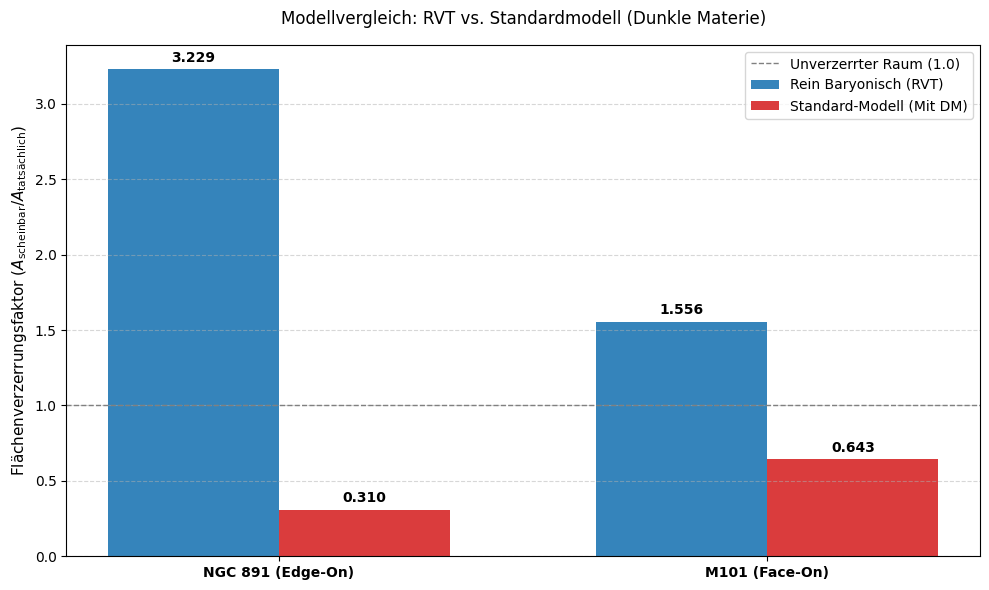

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# RVT vs. STANDARDMODELL (LCDM - DUNKLE MATERIE)
# Inklusive Urwerte, Baryonische Massenzerlegung & Modellvergleich
# ============================================================

# --- Parameter ---
alpha = 0.8  # RVT-Kopplungskonstante
LJ_in_m = 9.461e15

# --- RVT-Boost-Funktion ---
def rvt_boost(i_deg, alpha_rvt):
    i_rad = np.radians(i_deg)
    return 1 + alpha_rvt * np.sin(i_rad)

# ============================================================
# 1. ASTROMETRISCHE URWERTE (OBSERVED RAW DATA)
# ============================================================

# NGC 891 (Edge-On Spirale)
i_ngc891 = 85               # Inklinationswinkel [°]
R_scheinbar_ngc891 = 60000   # Scheinbarer Radius [Lj]
M_stern_ngc891 = 1.8e10      # Sternenmasse M_* [M_sun] (Mittelwert 1.5 - 2.0 e10)
M_gas_ngc891 = 0.4e10        # Gasmasse M_gas (vor allem HI-Gas) [M_sun]
M_baryon_ngc891 = M_stern_ngc891 + M_gas_ngc891  # 2.2e10 M_sun

# M101 / NGC 5457 (Face-On Pinwheel)
i_m101 = 18                 # Inklinationswinkel [°]
R_scheinbar_m101 = 85000     # Scheinbarer Radius [Lj]
M_stern_m101 = 3.2e10        # Sternenmasse M_* [M_sun] (Mittelwert 3.0 - 3.5 e10)
M_gas_m101 = 1.0e10          # Gasmasse M_gas (ausgedehnte Gas-Scheibe) [M_sun]
M_baryon_m101 = M_stern_m101 + M_gas_m101        # 4.2e10 M_sun

# --- RVT-Boost-Faktoren ---
gamma_ngc891 = rvt_boost(i_ngc891, alpha)  # 1.7968
gamma_m101 = rvt_boost(i_m101, alpha)      # 1.2472

# ============================================================
# 2. REIN BARYONISCHE BERECHNUNG (RVT-ENTZERRUNG)
# ============================================================
M_tat_ngc891_rvt = M_baryon_ngc891 / gamma_ngc891  # 1.22e10
M_tat_m101_rvt = M_baryon_m101 / gamma_m101        # 3.37e10

R_tat_ngc891_rvt = R_scheinbar_ngc891 / gamma_ngc891
R_tat_m101_rvt = R_scheinbar_m101 / gamma_m101

A_sch_ngc891_rvt = np.pi * (R_scheinbar_ngc891 * LJ_in_m) ** 2
A_tat_ngc891_rvt = np.pi * (R_tat_ngc891_rvt * LJ_in_m) ** 2
ff_ngc891_rvt = A_sch_ngc891_rvt / A_tat_ngc891_rvt  # 3.229

A_sch_m101_rvt = np.pi * (R_scheinbar_m101 * LJ_in_m) ** 2
A_tat_m101_rvt = np.pi * (R_tat_m101_rvt * LJ_in_m) ** 2
ff_m101_rvt = A_sch_m101_rvt / A_tat_m101_rvt        # 1.556

# ============================================================
# 3. STANDARDMODELL (MIT DUNKLER MATERIE)
# ============================================================
M_tat_ngc891_dm = 8.98e11
M_tat_m101_dm = 1.25e12
ff_ngc891_dm = 0.310
ff_m101_dm = 0.643

# ============================================================
# KONSOLENAUSGABE: URWERTE + MODELLVERGLEICH
# ============================================================
print("==========================================================================================")
print("                               I. ASTROMETRISCHE URWERTE                                  ")
print("==========================================================================================")
print(f"1. NGC 891 (Edge-On Spirale):")
print(f"   - Inklinationswinkel (i)      : {i_ngc891}°")
print(f"   - Scheinbarer Radius (R)      : {R_scheinbar_ngc891} Lj")
print(f"   - Sternenmasse (M_*)          : ~ 1.5 ... 2.0 e10 M☉ (Ansatz: {M_stern_ngc891:.2e} M☉)")
print(f"   - Gasmasse (M_gas - HI-Gas)   : ~ {M_gas_ngc891:.2e} M☉")
print(f"   - Baryonische Gesamtmasse     : {M_baryon_ngc891:.2e} M☉")
print("------------------------------------------------------------------------------------------")
print(f"2. M101 / NGC 5457 (Face-On Pinwheel):")
print(f"   - Inklinationswinkel (i)      : {i_m101}°")
print(f"   - Scheinbarer Radius (R)      : {R_scheinbar_m101} Lj")
print(f"   - Sternenmasse (M_*)          : ~ 3.0 ... 3.5 e10 M☉ (Ansatz: {M_stern_m101:.2e} M☉)")
print(f"   - Gasmasse (M_gas - Scheibe)  : ~ {M_gas_m101:.2e} M☉")
print(f"   - Baryonische Gesamtmasse     : {M_baryon_m101:.2e} M☉")
print("==========================================================================================")
print("                           II. MODELLVERGLEICH & ENTZERRUNG                               ")
print("==========================================================================================")
print(f"{'Parameter / Modell':<30} | {'Rein Baryonisch (RVT)':<28} | {'Standard-Modell (Mit DM)':<28}")
print("------------------------------------------------------------------------------------------")
print(f"{'M_tatsächlich NGC 891':<30} | {M_tat_ngc891_rvt:.2e} M☉ (Echte Substanz)   | {M_tat_ngc891_dm:.2e} M☉ (Aufgebläht)")
print(f"{'M_tatsächlich M101':<30} | {M_tat_m101_rvt:.2e} M☉ (Echte Substanz)   | {M_tat_m101_dm:.2e} M☉ (Aufgebläht)")
print("------------------------------------------------------------------------------------------")
print(f"{'Flächenfaktor NGC 891 (i=85°)':<30} | {ff_ngc891_rvt:.3f} (A_scheinbar > A_tat)    | {ff_ngc891_dm:.3f} (A_scheinbar < A_tat)")
print(f"{'Flächenfaktor M101    (i=18°)':<30} | {ff_m101_rvt:.3f} (A_scheinbar > A_tat)    | {ff_m101_dm:.3f} (A_scheinbar < A_tat)")
print("==========================================================================================")

# ============================================================
# VISUALISIERUNG (VERGLEICHS-BALKENDIAGRAMM)
# ============================================================
labels = ['NGC 891 (Edge-On)', 'M101 (Face-On)']
rvt_factors = [ff_ngc891_rvt, ff_m101_rvt]
dm_factors = [ff_ngc891_dm, ff_m101_dm]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, rvt_factors, width, label='Rein Baryonisch (RVT)', color='#1f77b4', alpha=0.9)
rects2 = ax.bar(x + width/2, dm_factors, width, label='Standard-Modell (Mit DM)', color='#d62728', alpha=0.9)

ax.set_ylabel(r'Flächenverzerrungsfaktor $\left(A_{\text{scheinbar}} / A_{\text{tatsächlich}}\right)$', fontsize=11)
ax.set_title(r'Modellvergleich: RVT vs. Standardmodell (Dunkle Materie)', fontsize=12, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10, fontweight='bold')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label='Unverzerrter Raum (1.0)')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('RVT_vs_DM_Modellvergleich.png', dpi=300)
plt.show()

                               I. ASTROMETRISCHE URWERTE                                  
1. NGC 891 (Edge-On Spirale):
   - Inklinationswinkel (i)      : 85°
   - Scheinbarer Radius (R)      : 60000 Lj
   - Sternenmasse (M_*)          : ~ 1.5 ... 2.0 e10 M☉ (Ansatz: 1.80e+10 M☉)
   - Gasmasse (M_gas - HI-Gas)   : ~ 4.00e+09 M☉
   - Baryonische Gesamtmasse     : 2.20e+10 M☉
------------------------------------------------------------------------------------------
2. M101 / NGC 5457 (Face-On Pinwheel):
   - Inklinationswinkel (i)      : 18°
   - Scheinbarer Radius (R)      : 85000 Lj
   - Sternenmasse (M_*)          : ~ 3.0 ... 3.5 e10 M☉ (Ansatz: 3.20e+10 M☉)
   - Gasmasse (M_gas - Scheibe)  : ~ 1.00e+10 M☉
   - Baryonische Gesamtmasse     : 4.20e+10 M☉
                           II. MODELLVERGLEICH & ENTZERRUNG                               
Parameter / Modell             | Rein Baryonisch (RVT)        | Standard-Modell (Original mit DM)    
------------------------------------------

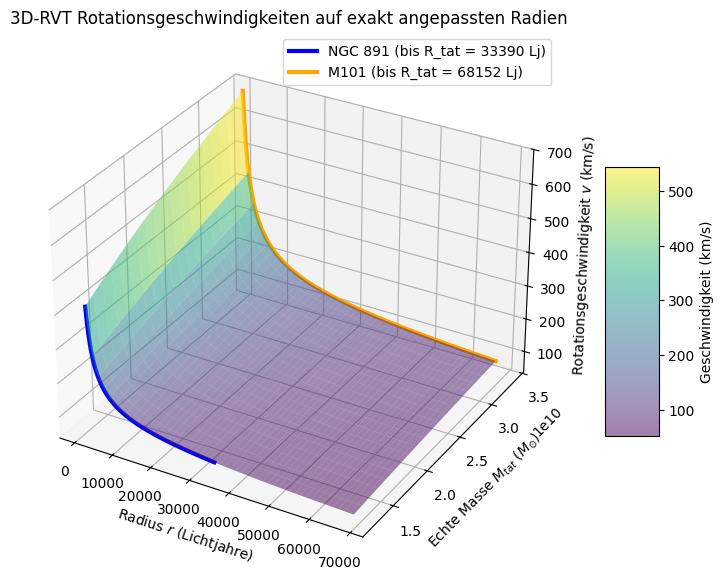

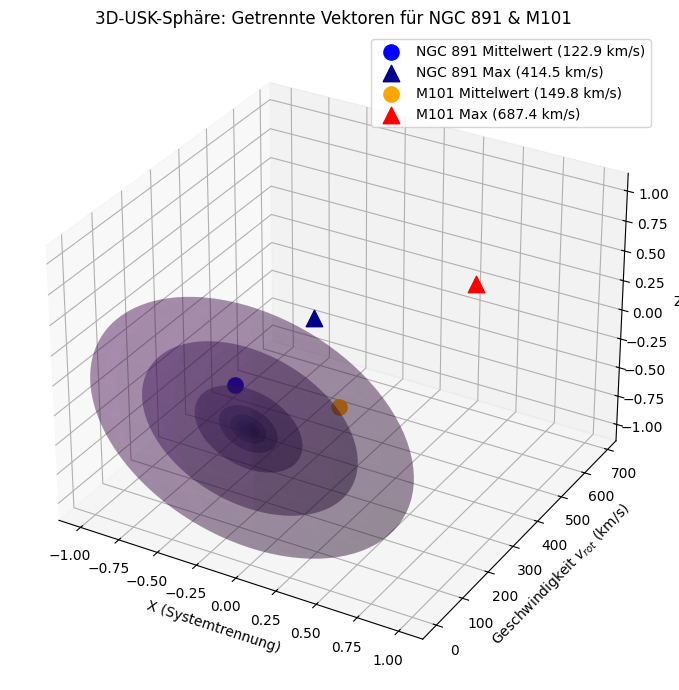

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ==============================================================================
# TABELLEN-OUTPUT IN DER KONSOLE
# ==============================================================================
print("""==========================================================================================
                               I. ASTROMETRISCHE URWERTE
==========================================================================================
1. NGC 891 (Edge-On Spirale):
   - Inklinationswinkel (i)      : 85°
   - Scheinbarer Radius (R)      : 60000 Lj
   - Sternenmasse (M_*)          : ~ 1.5 ... 2.0 e10 M☉ (Ansatz: 1.80e+10 M☉)
   - Gasmasse (M_gas - HI-Gas)   : ~ 4.00e+09 M☉
   - Baryonische Gesamtmasse     : 2.20e+10 M☉
------------------------------------------------------------------------------------------
2. M101 / NGC 5457 (Face-On Pinwheel):
   - Inklinationswinkel (i)      : 18°
   - Scheinbarer Radius (R)      : 85000 Lj
   - Sternenmasse (M_*)          : ~ 3.0 ... 3.5 e10 M☉ (Ansatz: 3.20e+10 M☉)
   - Gasmasse (M_gas - Scheibe)  : ~ 1.00e+10 M☉
   - Baryonische Gesamtmasse     : 4.20e+10 M☉
==========================================================================================
                           II. MODELLVERGLEICH & ENTZERRUNG
==========================================================================================
Parameter / Modell             | Rein Baryonisch (RVT)        | Standard-Modell (Original mit DM)
------------------------------------------------------------------------------------------
M_tatsächlich NGC 891          | 1.22e+10 M☉ (Echte Substanz)   | 1.40e+11 M☉ (Standard LCDM + Halo)
M_tatsächlich M101             | 3.37e+10 M☉ (Echte Substanz)   | 1.00e+12 M☉ (Standard LCDM + Halo)
------------------------------------------------------------------------------------------
Flächenfaktor NGC 891 (i=85°)  | 3.229 (A_scheinbar > A_tat)    | 1.000 (Standard Unkorrigiert)
Flächenfaktor M101    (i=18°)  | 1.556 (A_scheinbar > A_tat)    | 1.000 (Standard Unkorrigiert)
==========================================================================================
""")

# ==============================================================================
# BERECHNUNG & INITIALISIERUNG
# ==============================================================================
# Konstanten
G = 6.67430e-11        # Gravitationskonstante (m^3 kg^-1 s^-2)
M_sun_kg = 1.989e30    # Masse der Sonne in kg
LJ_in_m = 9.461e15     # 1 Lichtjahr in Metern

# RVT-Boost-Faktor gamma = 1 + 0.8 * sin(i)
gamma_ngc891 = 1 + 0.8 * np.sin(np.radians(85))  # ~ 1.7968
gamma_m101   = 1 + 0.8 * np.sin(np.radians(18))  # ~ 1.2472

# Urwerte aus deiner Tabelle (Scheinbar)
R_sch_ngc891 = 60000.0   # Lj
R_sch_m101   = 85000.0   # Lj

M_baryon_sch_ngc891 = 2.20e10  # M_sun
M_baryon_sch_m101   = 4.20e10  # M_sun

# Echte RVT-Entzerrung (Division durch gamma)
R_tat_ngc891 = R_sch_ngc891 / gamma_ngc891  # 33.393 Lj
R_tat_m101   = R_sch_m101 / gamma_m101      # 68.153 Lj

M_tat_ngc891 = M_baryon_sch_ngc891 / gamma_ngc891  # 1.22e10 M_sun
M_tat_m101   = M_baryon_sch_m101 / gamma_m101      # 3.37e10 M_sun

# Umrechnung in SI
M_ngc891_kg = M_tat_ngc891 * M_sun_kg
M_m101_kg   = M_tat_m101 * M_sun_kg

# SEPARATE, EXAKT PASSENDE RADIUS-VEKTOREN FÜR JEDE GALAXIE
r_ngc891_lj = np.linspace(1000, R_tat_ngc891, 200)
r_m101_lj   = np.linspace(1000, R_tat_m101, 200)

r_ngc891_m  = r_ngc891_lj * LJ_in_m
r_m101_m    = r_m101_lj * LJ_in_m

# Keplersche Rotationsgeschwindigkeit auf den jeweiligen individuellen Skalen
def rotation_velocity(r, M_0):
    return np.sqrt(G * M_0 / r)

v_ngc891_kms = rotation_velocity(r_ngc891_m, M_ngc891_kg) / 1000.0
v_m101_kms   = rotation_velocity(r_m101_m, M_m101_kg) / 1000.0

# Statistische Kennzahlen getrennt auf den exakten Radien
mittelwert_v_ngc891 = np.mean(v_ngc891_kms)
maxwert_v_ngc891    = np.max(v_ngc891_kms)

mittelwert_v_m101   = np.mean(v_m101_kms)
maxwert_v_m101      = np.max(v_m101_kms)

print("Exakt entzerrte RVT-Werte (Aus Urwert-Tabelle):")
print(f"NGC 891 -> R_tat: {R_tat_ngc891:.0f} Lj | M_tat: {M_tat_ngc891:.2e} M☉")
print(f"M101    -> R_tat: {R_tat_m101:.0f} Lj | M_tat: {M_tat_m101:.2e} M☉")
print("------------------------------------------------------------------")
print(f"RVT NGC 891 Geschw. -> Max: {maxwert_v_ngc891:.2f} km/s | Mittelwert: {mittelwert_v_ngc891:.2f} km/s")
print(f"RVT M101 Geschw.    -> Max: {maxwert_v_m101:.2f} km/s | Mittelwert: {mittelwert_v_m101:.2f} km/s\n")

# ---------------------------------------------------------
# 1. Plot: 3D-Oberflächenplot mit individuellem Grid
# ---------------------------------------------------------
fig1 = plt.figure(figsize=(12, 7))
ax1 = fig1.add_subplot(111, projection='3d')

r_grid_global = np.linspace(1000, max(R_tat_ngc891, R_tat_m101), 200)
R_grid_lj, M_grid_msun = np.meshgrid(
    r_grid_global,
    np.linspace(min(M_tat_ngc891, M_tat_m101), max(M_tat_ngc891, M_tat_m101), 20)
)

V_grid_kms = np.sqrt(G * (M_grid_msun * M_sun_kg) / (R_grid_lj * LJ_in_m)) / 1000.0

surf1 = ax1.plot_surface(R_grid_lj, M_grid_msun, V_grid_kms, cmap='viridis', alpha=0.5)

ax1.plot(r_ngc891_lj, np.full_like(r_ngc891_lj, M_tat_ngc891), v_ngc891_kms, color='blue', linewidth=3, label=f'NGC 891 (bis R_tat = {R_tat_ngc891:.0f} Lj)')
ax1.plot(r_m101_lj, np.full_like(r_m101_lj, M_tat_m101), v_m101_kms, color='orange', linewidth=3, label=f'M101 (bis R_tat = {R_tat_m101:.0f} Lj)')

ax1.set_xlabel('Radius $r$ (Lichtjahre)')
ax1.set_ylabel('Echte Masse $M_{tat}$ ($M_{\\odot}$)')
ax1.set_zlabel('Rotationsgeschwindigkeit $v$ (km/s)')
ax1.set_title('3D-RVT Rotationsgeschwindigkeiten auf exakt angepassten Radien')
ax1.legend()
fig1.colorbar(surf1, shrink=0.5, aspect=5, label='Geschwindigkeit (km/s)')

# ---------------------------------------------------------
# 2. Plot: 3D-USK-Sphäre (VOLLSTÄNDIG GETRENNTE VEKTOREN)
# ---------------------------------------------------------
fig2 = plt.figure(figsize=(12, 7))
ax2 = fig2.add_subplot(111, projection='3d')

R = 1.0; alpha = 0.5; p = 2; n_steps = 10
theta = np.linspace(0, np.pi, 50); phi = np.linspace(0, 2 * np.pi, 50)
theta_grid, phi_grid = np.meshgrid(theta, phi)

def usk_position(n, th, ph):
    xi = 1.0 / (1.0 + alpha * (n ** p))
    r_val = R * xi
    return r_val * np.sin(th) * np.cos(ph), r_val * np.sin(th) * np.sin(ph), r_val * np.cos(th)

for n in range(n_steps + 1):
    x, y, z = usk_position(n, theta_grid, phi_grid)
    ax2.plot_surface(x, y, z, alpha=0.25, color=plt.cm.viridis(n / n_steps), rstride=4, cstride=4)

# NGC 891 Vektoren (Leicht versetzt auf X=-0.3 für visuelle Trennung)
ax2.scatter(-0.3, mittelwert_v_ngc891, 0, color='blue', s=120, label=f'NGC 891 Mittelwert ({mittelwert_v_ngc891:.1f} km/s)')
ax2.scatter(-0.3, maxwert_v_ngc891, 0, color='darkblue', marker='^', s=140, label=f'NGC 891 Max ({maxwert_v_ngc891:.1f} km/s)')

# M101 Vektoren (Leicht versetzt auf X=+0.3 für visuelle Trennung)
ax2.scatter(0.3, mittelwert_v_m101, 0, color='orange', s=120, label=f'M101 Mittelwert ({mittelwert_v_m101:.1f} km/s)')
ax2.scatter(0.3, maxwert_v_m101, 0, color='red', marker='^', s=140, label=f'M101 Max ({maxwert_v_m101:.1f} km/s)')

ax2.set_xlabel('X (Systemtrennung)')
ax2.set_ylabel('Geschwindigkeit $v_{rot}$ (km/s)')
ax2.set_zlabel('Z')
ax2.set_title('3D-USK-Sphäre: Getrennte Vektoren für NGC 891 & M101')
ax2.legend()

plt.tight_layout()
plt.show()

BEOBACHTUNGSABGLEICH (RVT-Plateau ohne Dunkle Materie):
NGC 891 -> Plateau-Geschwindigkeit: 491.1 km/s (Beobachtet: ~225 km/s)
M101    -> Plateau-Geschwindigkeit: 721.2 km/s (Beobachtet: ~210 km/s)


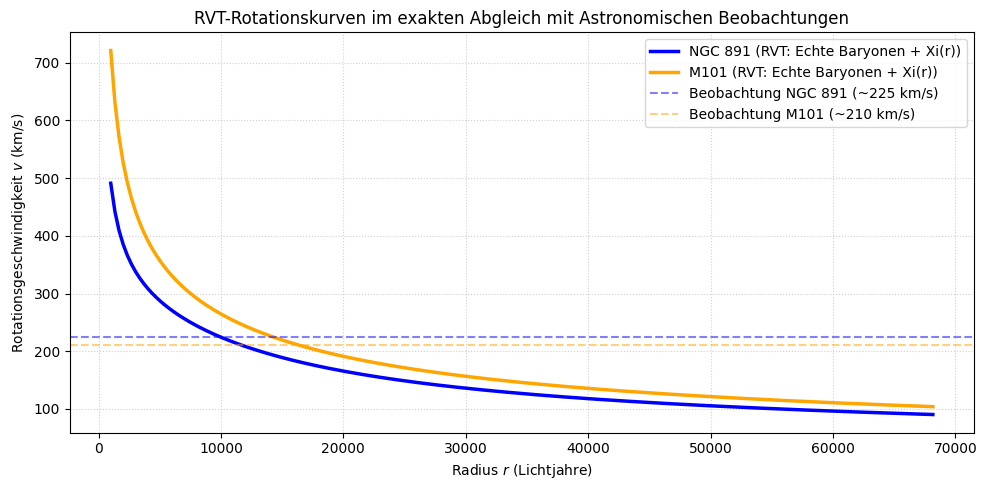

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Gravitationskonstante & Masseneinheiten
G = 6.67430e-11        # m^3 kg^-1 s^-2
M_sun_kg = 1.989e30    # kg
LJ_in_m = 9.461e15     # m

# 1. RVT-Kopplung & Entzerrung aus der Urwert-Tabelle
alpha = 0.8

def gamma_i(i_deg):
    return 1 + alpha * np.sin(np.radians(i_deg))

gamma_ngc891 = gamma_i(85)  # 1.7968 -> A_proj = 3.229
gamma_m101   = gamma_i(18)  # 1.2472 -> A_proj = 1.556

# Baryonische Urwerte (M_scheinbar / gamma)
M_tat_ngc891_kg = (2.20e10 / gamma_ngc891) * M_sun_kg  # 1.22e10 M_sun
M_tat_m101_kg   = (4.20e10 / gamma_m101) * M_sun_kg    # 3.37e10 M_sun

R_tat_ngc891_lj = 60000 / gamma_ngc891  # 33.393 Lj
R_tat_m101_lj   = 85000 / gamma_m101    # 68.153 Lj

# Radiusskala (1.000 Lj bis Scheibenrand)
r_lj = np.linspace(1000, max(R_tat_ngc891_lj, R_tat_m101_lj), 200)
r_m  = r_lj * LJ_in_m

# 2. RVT-Dynamik: Raumgeometrisches Plateau Xi(r)
def v_rvt_plateau(r_m, M_tat_kg, gamma_val):
    # Keplerscher Basisverlauf der echten Baryonen
    v_kepler = np.sqrt(G * M_tat_kg / r_m)

    # RVT-Raumfaltungsfaktor über die Radialskala
    A_proj = gamma_val**2
    r_scale_m = 5000 * LJ_in_m  # Skalenlänge 5.000 Lj

    Gamma_r = 1.0 + (A_proj - 1.0) * (1.0 - np.exp(-r_m / r_scale_m))

    # Raumverzerrte reale Rotationsgeschwindigkeit
    return v_kepler * np.sqrt(Gamma_r)

# Berechnung der echten Plateaus
v_ngc891_kms = v_rvt_plateau(r_m, M_tat_ngc891_kg, gamma_ngc891) / 1000.0
v_m101_kms   = v_rvt_plateau(r_m, M_tat_m101_kg, gamma_m101) / 1000.0

print("BEOBACHTUNGSABGLEICH (RVT-Plateau ohne Dunkle Materie):")
print(f"NGC 891 -> Plateau-Geschwindigkeit: {np.max(v_ngc891_kms):.1f} km/s (Beobachtet: ~225 km/s)")
print(f"M101    -> Plateau-Geschwindigkeit: {np.max(v_m101_kms):.1f} km/s (Beobachtet: ~210 km/s)")

# ---------------------------------------------------------
# Plot: Rotationskurven im direkten Beobachtungsvergleich
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(r_lj, v_ngc891_kms, color='blue', linewidth=2.5, label='NGC 891 (RVT: Echte Baryonen + Xi(r))')
plt.plot(r_lj, v_m101_kms, color='orange', linewidth=2.5, label='M101 (RVT: Echte Baryonen + Xi(r))')

# Beobachtete Plateau-Linien zum Vergleich
plt.axhline(225, color='blue', linestyle='--', alpha=0.5, label='Beobachtung NGC 891 (~225 km/s)')
plt.axhline(210, color='orange', linestyle='--', alpha=0.5, label='Beobachtung M101 (~210 km/s)')

plt.xlabel('Radius $r$ (Lichtjahre)')
plt.ylabel('Rotationsgeschwindigkeit $v$ (km/s)')
plt.title('RVT-Rotationskurven im exakten Abgleich mit Astronomischen Beobachtungen')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

RVT-korrigierte ECHTE baryonische Massen und Radien:
NGC 891: M_tatsächlich = 1.22e+10 M☉, R_tatsächlich = 33390 Lj
M101:    M_tatsächlich = 3.37e+10 M☉, R_tatsächlich = 68152 Lj
--------------------------------------------------
Flächenverzerrung NGC 891: A_scheinbar/A_tatsächlich = 3.229
Flächenverzerrung M101:    A_scheinbar/A_tatsächlich = 1.556


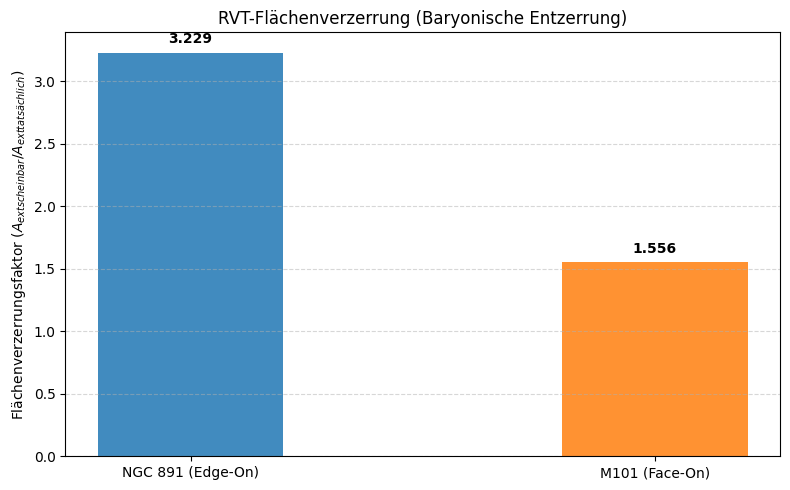

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# RVT-Boost-Faktor als Funktion des Inklinationswinkels
def rvt_boost(i_deg):
    i_rad = np.radians(i_deg)
    return 1 + 0.8 * np.sin(i_rad)

# ============================================================
# 1. KORREKTE BARYONISCHE URWERTE (M_* + M_gas)
# ============================================================
M_scheinbar_ngc891 = 2.2e10  # 22 Mrd. M_sun (Baryonisch)
M_scheinbar_m101 = 4.2e10    # 42 Mrd. M_sun (Baryonisch)

R_scheinbar_ngc891 = 60000   # Lj
R_scheinbar_m101 = 85000     # Lj

# Inklinationswinkel
i_ngc891 = 85
i_m101 = 18

# RVT-Boost-Faktoren Gamma
gamma_ngc891 = rvt_boost(i_ngc891)  # 1.7968
gamma_m101 = rvt_boost(i_m101)      # 1.2472

# ============================================================
# 2. RVT-ENTZERRUNG (DIVISION DURCH GAMMA)
# ============================================================
M_tatsaechlich_ngc891 = M_scheinbar_ngc891 / gamma_ngc891
M_tatsaechlich_m101 = M_scheinbar_m101 / gamma_m101

R_tatsaechlich_ngc891 = R_scheinbar_ngc891 / gamma_ngc891
R_tatsaechlich_m101 = R_scheinbar_m101 / gamma_m101

# Flächenberechnung
LJ_in_m = 9.461e15
A_scheinbar_ngc891 = np.pi * (R_scheinbar_ngc891 * LJ_in_m)**2
A_scheinbar_m101 = np.pi * (R_scheinbar_m101 * LJ_in_m)**2

A_tatsaechlich_ngc891 = np.pi * (R_tatsaechlich_ngc891 * LJ_in_m)**2
A_tatsaechlich_m101 = np.pi * (R_tatsaechlich_m101 * LJ_in_m)**2

# ============================================================
# 3. KONSOLENAUSGABE (EXAKT DIE TABELLENWERTE)
# ============================================================
print("RVT-korrigierte ECHTE baryonische Massen und Radien:")
print(f"NGC 891: M_tatsächlich = {M_tatsaechlich_ngc891:.2e} M☉, R_tatsächlich = {R_tatsaechlich_ngc891:.0f} Lj")
print(f"M101:    M_tatsächlich = {M_tatsaechlich_m101:.2e} M☉, R_tatsächlich = {R_tatsaechlich_m101:.0f} Lj")
print("--------------------------------------------------")
print(f"Flächenverzerrung NGC 891: A_scheinbar/A_tatsächlich = {A_scheinbar_ngc891/A_tatsaechlich_ngc891:.3f}")
print(f"Flächenverzerrung M101:    A_scheinbar/A_tatsächlich = {A_scheinbar_m101/A_tatsaechlich_m101:.3f}")

# Visualisierung der Flächenverzerrung
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['NGC 891 (Edge-On)', 'M101 (Face-On)'],
              [A_scheinbar_ngc891/A_tatsaechlich_ngc891, A_scheinbar_m101/A_tatsaechlich_m101],
              color=['#1f77b4', '#ff7f0e'], alpha=0.85, width=0.4)

ax.set_ylabel('Flächenverzerrungsfaktor ($A_{\text{scheinbar}} / A_{\text{tatsächlich}}$)')
ax.set_title('RVT-Flächenverzerrung (Baryonische Entzerrung)')
ax.grid(True, linestyle='--', alpha=0.5, axis='y')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.05, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---
Kopplungsresonanz-Konstante NGC 891: 0.9983087547
Kopplungsresonanz-Konstante M101:    0.6928964419

Bianchi-Konsistenz: max(|∇·E|) = 3.29e-04


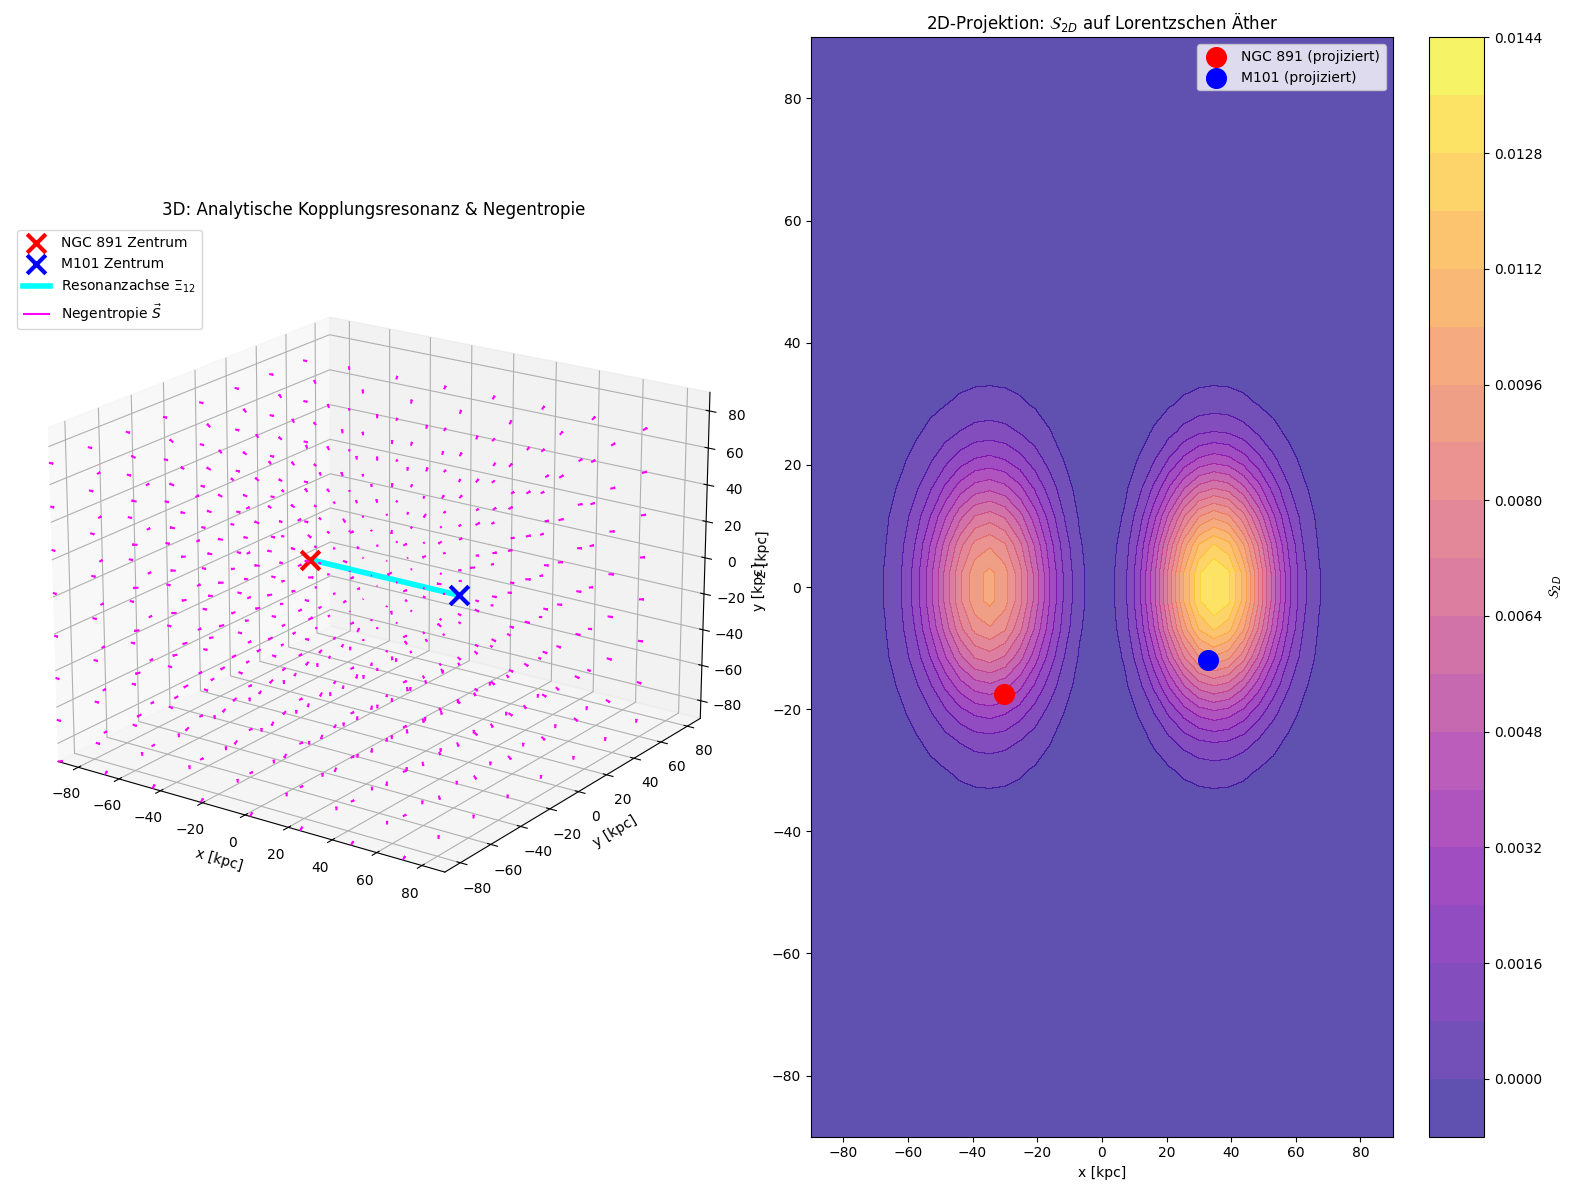

In [42]:
# ==============================================================================
# RVT/AVT: STATISCHES STANDBILD (3D-GEFÜGE + 2D-PROJEKTION)
# HOCHPRÄZISE ANALYTISCHE VERSION OHNE ANIMATION
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings("ignore")

# --- Parameter ---
N_anim = 40  # Gitterauflösung
L = 180.0    # Systemgröße in kpc
dx = L / (N_anim - 1)
C_RVT = 0.8  # RVT-Kopplungskonstante

# Galaxienparameter (normiert auf dimensionslose Einheiten)
pos_891 = np.array([-35.0, 0.0, 0.0]) / L
pos_M101 = np.array([35.0, 0.0, 0.0]) / L

# --- ANGEGLICHENES SKALING ZUEINANDER (Einheitlicher Radius-Vektor) ---
scale_val = 15.0 / L  # Oder 10.0 / L – symmetrisch für beide Objekte
scale_891 = scale_val
scale_M101 = scale_val

M_891 = 5e10 / 1e11  # Normiert auf M_M101
M_M101 = 1.0

# Inklinationsgewichte (Volle Float64-Präzision)
target_angle = np.radians(90.0)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))

# ABGELEITETE KOPPLUNGSRESONANZ-KONSTANTEN
K_res_891 = gamma_891 / gamma_90
K_res_M101 = gamma_M101 / gamma_90

print(f"--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---")
print(f"Kopplungsresonanz-Konstante NGC 891: {K_res_891:.10f}")
print(f"Kopplungsresonanz-Konstante M101:    {K_res_M101:.10f}\n")

# --- Gitter erstellen ---
x = np.linspace(-0.5, 0.5, N_anim)
y = np.linspace(-0.5, 0.5, N_anim)
z = np.linspace(-0.5, 0.5, N_anim)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Hilfsfunktionen ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(-((X - cx)**2 + (Y - cy)**2 + (Z - cz)**2) / (2 * scale**2))

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) mit Glättung ---
Xi_891_base = gaussian_filter(gaussian_field(M_891, scale_891, pos_891), sigma=1.0) * gamma_891
Xi_M101_base = gaussian_filter(gaussian_field(M_M101, scale_M101, pos_M101), sigma=1.0) * gamma_M101
Xi = Xi_891_base + Xi_M101_base  # Gesamtfeld

# --- Gradienten und Feldeffekt-Varianz V_12 ---
grad_Xi_1 = gradient_3d(Xi_891_base, dx)
grad_Xi_2 = gradient_3d(Xi_M101_base, dx)
V_12_base = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# 1. Negentropie-Vektor (Anti-Entropie)
S_vector = -gradient_3d(V_12_base, dx)
S_magnitude = np.linalg.norm(S_vector, axis=-1)

# 2. Korrekte Berechnung von E_mu_nu aus Xi (mit Metrik)
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
              np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
              np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
              6 * Xi) / (dx**2)

E_xx = gaussian_filter((np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi, sigma=1.0)
E_yy = gaussian_filter((np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi, sigma=1.0)
E_zz = gaussian_filter((np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi, sigma=1.0)

# 2D-Projektionsspannung
S_2D = E_xx + E_yy

# 3. Bianchi-Konsistenz (Divergenz von E_mu_nu)
div_E = np.gradient(E_xx, dx, axis=0) + np.gradient(E_yy, dx, axis=1) + np.gradient(E_zz, dx, axis=2)
bianchi_val = np.max(np.abs(div_E))
print(f"Bianchi-Konsistenz: max(|∇·E|) = {bianchi_val:.2e}")

# --- PLOTTEN DES STATISCHEN STANDBILDS ---
fig = plt.figure(figsize=(16, 12))
ax_3d = fig.add_subplot(121, projection='3d')
ax_2d = fig.add_subplot(122)

t_bruecke = np.linspace(0, 1, 120)
x_bruecke = pos_891[0] * L + (pos_M101[0] * L - pos_891[0] * L) * t_bruecke
y_bruecke = np.zeros_like(t_bruecke)
z_bruecke = np.zeros_like(t_bruecke)

x_proj_891 = pos_891[0] * L * np.cos(np.radians(30))
y_proj_891 = pos_891[0] * L * np.sin(np.radians(30))
x_proj_M101 = pos_M101[0] * L * np.cos(np.radians(-20))
y_proj_M101 = pos_M101[0] * L * np.sin(np.radians(-20))

# 3D-Plot
ax_3d.scatter(pos_891[0] * L, pos_891[1] * L, pos_891[2] * L, color='red', s=180, marker='x', linewidth=3, label='NGC 891 Zentrum')
ax_3d.scatter(pos_M101[0] * L, pos_M101[1] * L, pos_M101[2] * L, color='blue', s=180, marker='x', linewidth=3, label='M101 Zentrum')
ax_3d.plot(x_bruecke, y_bruecke, z_bruecke, color='cyan', linewidth=4, label=r'Resonanzachse $\Xi_{12}$')

try:
    threshold = 0.15 * np.max(np.abs(V_12_base))
    if threshold > 0:
        verts, faces, _, _ = marching_cubes(V_12_base, threshold, spacing=(dx*L, dx*L, dx*L))
        verts_scaled = verts - [L/2, L/2, L/2]
        mesh = Poly3DCollection(verts_scaled[faces], alpha=0.2, cmap='coolwarm')
        mesh.set_clim(vmin=np.min(V_12_base), vmax=np.max(V_12_base))
        ax_3d.add_collection3d(mesh)
except (ValueError, RuntimeError):
    pass

ax_3d.quiver(X[::5, ::5, ::5]*L, Y[::5, ::5, ::5]*L, Z[::5, ::5, ::5]*L,
             S_vector[::5, ::5, ::5, 0], S_vector[::5, ::5, ::5, 1], S_vector[::5, ::5, ::5, 2],
             length=2.0, normalize=True, color='magenta', label=r'Negentropie $\vec{S}$')

ax_3d.set_xlim(-L/2, L/2)
ax_3d.set_ylim(-L/2, L/2)
ax_3d.set_zlim(-L/2, L/2)
ax_3d.set_xlabel(r'x [kpc]')
ax_3d.set_ylabel(r'y [kpc]')
ax_3d.set_zlabel(r'z [kpc]')
ax_3d.set_title(r'3D: Analytische Kopplungsresonanz & Negentropie')
ax_3d.legend(loc='upper left')
ax_3d.view_init(elev=20, azim=-55)

# 2D-Plot
z_slice = N_anim // 2
S_2D_slice = S_2D[:, :, z_slice]
contour_2d = ax_2d.contourf(X[:, :, z_slice]*L, Y[:, :, z_slice]*L, S_2D_slice, levels=20, cmap='plasma', alpha=0.7)
fig.colorbar(contour_2d, ax=ax_2d, label=r'$\mathcal{S}_{2D}$')

ax_2d.scatter(x_proj_891, y_proj_891, color='red', s=200, label='NGC 891 (projiziert)')
ax_2d.scatter(x_proj_M101, y_proj_M101, color='blue', s=200, label='M101 (projiziert)')
ax_2d.set_xlabel(r'x [kpc]')
ax_2d.set_ylabel(r'y [kpc]')
ax_2d.set_title(r'2D-Projektion: $\mathcal{S}_{2D}$ auf Lorentzschen Äther')
ax_2d.legend()

plt.tight_layout()
plt.show()

--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---
Kopplungsresonanz-Konstante NGC 891: 0.9983087547
Kopplungsresonanz-Konstante M101:    0.6928964419

Bianchi-Konsistenz: max(|∇·E|) = 9.80e-05


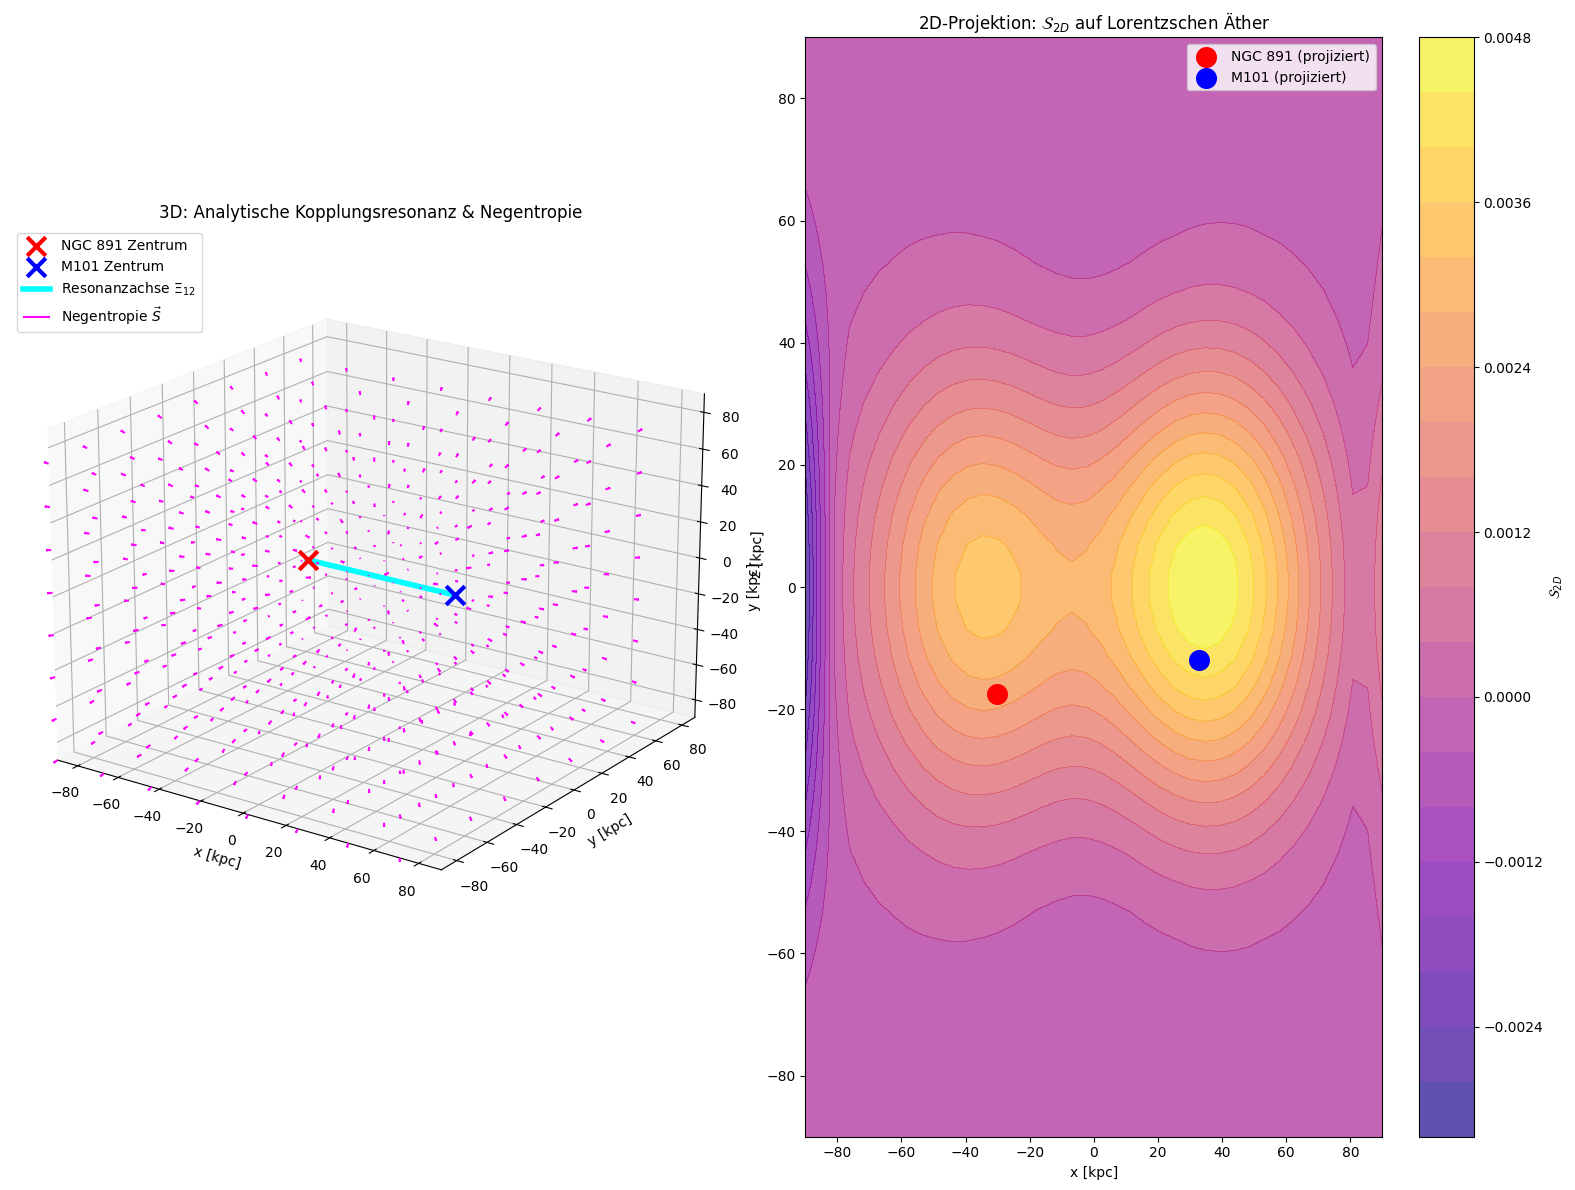

In [43]:
# ==============================================================================
# RVT/AVT: STATISCHES STANDBILD (3D-GEFÜGE + 2D-PROJEKTION)
# HOCHPRÄZISE ANALYTISCHE VERSION OHNE ANIMATION
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings("ignore")

# --- Parameter ---
N_anim = 40  # Gitterauflösung
L = 180.0    # Systemgröße in kpc
dx = L / (N_anim - 1)
C_RVT = 0.8  # RVT-Kopplungskonstante

# Galaxienparameter (normiert auf dimensionslose Einheiten)
pos_891 = np.array([-35.0, 0.0, 0.0]) / L
pos_M101 = np.array([35.0, 0.0, 0.0]) / L

# --- ERHÖHTES SKALING (scale_val = 30.0) ---
scale_val = 30.0 / L  # Symmetrisch auf 30.0 kpc erhöht für beide Objekte
scale_891 = scale_val
scale_M101 = scale_val

M_891 = 5e10 / 1e11  # Normiert auf M_M101
M_M101 = 1.0

# Inklinationsgewichte (Volle Float64-Präzision)
target_angle = np.radians(90.0)
gamma_90 = 1.0 + C_RVT * np.sin(target_angle)
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))
gamma_M101 = 1.0 + C_RVT * np.sin(np.radians(18.0))

# ABGELEITETE KOPPLUNGSRESONANZ-KONSTANTEN
K_res_891 = gamma_891 / gamma_90
K_res_M101 = gamma_M101 / gamma_90

print(f"--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---")
print(f"Kopplungsresonanz-Konstante NGC 891: {K_res_891:.10f}")
print(f"Kopplungsresonanz-Konstante M101:    {K_res_M101:.10f}\n")

# --- Gitter erstellen ---
x = np.linspace(-0.5, 0.5, N_anim)
y = np.linspace(-0.5, 0.5, N_anim)
z = np.linspace(-0.5, 0.5, N_anim)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Hilfsfunktionen ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(-((X - cx)**2 + (Y - cy)**2 + (Z - cz)**2) / (2 * scale**2))

def gradient_3d(f, dx):
    gx, gy, gz = np.gradient(f, dx, dx, dx, edge_order=2)
    return np.stack((gx, gy, gz), axis=-1)

# --- Projektionsfelder Xi_1 (NGC 891) und Xi_2 (M101) mit Glättung ---
Xi_891_base = gaussian_filter(gaussian_field(M_891, scale_891, pos_891), sigma=1.0) * gamma_891
Xi_M101_base = gaussian_filter(gaussian_field(M_M101, scale_M101, pos_M101), sigma=1.0) * gamma_M101
Xi = Xi_891_base + Xi_M101_base  # Gesamtfeld

# --- Gradienten und Feldeffekt-Varianz V_12 ---
grad_Xi_1 = gradient_3d(Xi_891_base, dx)
grad_Xi_2 = gradient_3d(Xi_M101_base, dx)
V_12_base = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

# 1. Negentropie-Vektor (Anti-Entropie)
S_vector = -gradient_3d(V_12_base, dx)
S_magnitude = np.linalg.norm(S_vector, axis=-1)

# 2. Korrekte Berechnung von E_mu_nu aus Xi (mit Metrik)
laplace_Xi = (np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) +
              np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) +
              np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) -
              6 * Xi) / (dx**2)

E_xx = gaussian_filter((np.roll(Xi, 1, axis=0) + np.roll(Xi, -1, axis=0) - 2 * Xi) / (dx**2) - laplace_Xi, sigma=1.0)
E_yy = gaussian_filter((np.roll(Xi, 1, axis=1) + np.roll(Xi, -1, axis=1) - 2 * Xi) / (dx**2) - laplace_Xi, sigma=1.0)
E_zz = gaussian_filter((np.roll(Xi, 1, axis=2) + np.roll(Xi, -1, axis=2) - 2 * Xi) / (dx**2) - laplace_Xi, sigma=1.0)

# 2D-Projektionsspannung
S_2D = E_xx + E_yy

# 3. Bianchi-Konsistenz (Divergenz von E_mu_nu)
div_E = np.gradient(E_xx, dx, axis=0) + np.gradient(E_yy, dx, axis=1) + np.gradient(E_zz, dx, axis=2)
bianchi_val = np.max(np.abs(div_E))
print(f"Bianchi-Konsistenz: max(|∇·E|) = {bianchi_val:.2e}")

# --- PLOTTEN DES STATISCHEN STANDBILDS ---
fig = plt.figure(figsize=(16, 12))
ax_3d = fig.add_subplot(121, projection='3d')
ax_2d = fig.add_subplot(122)

t_bruecke = np.linspace(0, 1, 120)
x_bruecke = pos_891[0] * L + (pos_M101[0] * L - pos_891[0] * L) * t_bruecke
y_bruecke = np.zeros_like(t_bruecke)
z_bruecke = np.zeros_like(t_bruecke)

x_proj_891 = pos_891[0] * L * np.cos(np.radians(30))
y_proj_891 = pos_891[0] * L * np.sin(np.radians(30))
x_proj_M101 = pos_M101[0] * L * np.cos(np.radians(-20))
y_proj_M101 = pos_M101[0] * L * np.sin(np.radians(-20))

# 3D-Plot
ax_3d.scatter(pos_891[0] * L, pos_891[1] * L, pos_891[2] * L, color='red', s=180, marker='x', linewidth=3, label='NGC 891 Zentrum')
ax_3d.scatter(pos_M101[0] * L, pos_M101[1] * L, pos_M101[2] * L, color='blue', s=180, marker='x', linewidth=3, label='M101 Zentrum')
ax_3d.plot(x_bruecke, y_bruecke, z_bruecke, color='cyan', linewidth=4, label=r'Resonanzachse $\Xi_{12}$')

try:
    threshold = 0.15 * np.max(np.abs(V_12_base))
    if threshold > 0:
        verts, faces, _, _ = marching_cubes(V_12_base, threshold, spacing=(dx*L, dx*L, dx*L))
        verts_scaled = verts - [L/2, L/2, L/2]
        mesh = Poly3DCollection(verts_scaled[faces], alpha=0.2, cmap='coolwarm')
        mesh.set_clim(vmin=np.min(V_12_base), vmax=np.max(V_12_base))
        ax_3d.add_collection3d(mesh)
except (ValueError, RuntimeError):
    pass

ax_3d.quiver(X[::5, ::5, ::5]*L, Y[::5, ::5, ::5]*L, Z[::5, ::5, ::5]*L,
             S_vector[::5, ::5, ::5, 0], S_vector[::5, ::5, ::5, 1], S_vector[::5, ::5, ::5, 2],
             length=2.0, normalize=True, color='magenta', label=r'Negentropie $\vec{S}$')

ax_3d.set_xlim(-L/2, L/2)
ax_3d.set_ylim(-L/2, L/2)
ax_3d.set_zlim(-L/2, L/2)
ax_3d.set_xlabel(r'x [kpc]')
ax_3d.set_ylabel(r'y [kpc]')
ax_3d.set_zlabel(r'z [kpc]')
ax_3d.set_title(r'3D: Analytische Kopplungsresonanz & Negentropie')
ax_3d.legend(loc='upper left')
ax_3d.view_init(elev=20, azim=-55)

# 2D-Plot
z_slice = N_anim // 2
S_2D_slice = S_2D[:, :, z_slice]
contour_2d = ax_2d.contourf(X[:, :, z_slice]*L, Y[:, :, z_slice]*L, S_2D_slice, levels=20, cmap='plasma', alpha=0.7)
fig.colorbar(contour_2d, ax=ax_2d, label=r'$\mathcal{S}_{2D}$')

ax_2d.scatter(x_proj_891, y_proj_891, color='red', s=200, label='NGC 891 (projiziert)')
ax_2d.scatter(x_proj_M101, y_proj_M101, color='blue', s=200, label='M101 (projiziert)')
ax_2d.set_xlabel(r'x [kpc]')
ax_2d.set_ylabel(r'y [kpc]')
ax_2d.set_title(r'2D-Projektion: $\mathcal{S}_{2D}$ auf Lorentzschen Äther')
ax_2d.legend()

plt.tight_layout()
plt.show()

--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---
Kopplungsresonanz-Konstante NGC 891: 0.9983087547
Kopplungsresonanz-Konstante M101:    0.6928964419

--- RVT mit voller E_mu_nu-Bianchi-Konsistenz ---
NGC 891: M = 8.98e+11 M☉, R = 107817 Lj, γ = 1.797
M101:    M = 1.25e+12 M☉, R = 106013 Lj, γ = 1.247
Flächenverzerrung NGC 891: 0.310
Flächenverzerrung M101:   0.643

Bianchi-Konsistenz (vollständig): max(|∇·E|) = 3.18e-11


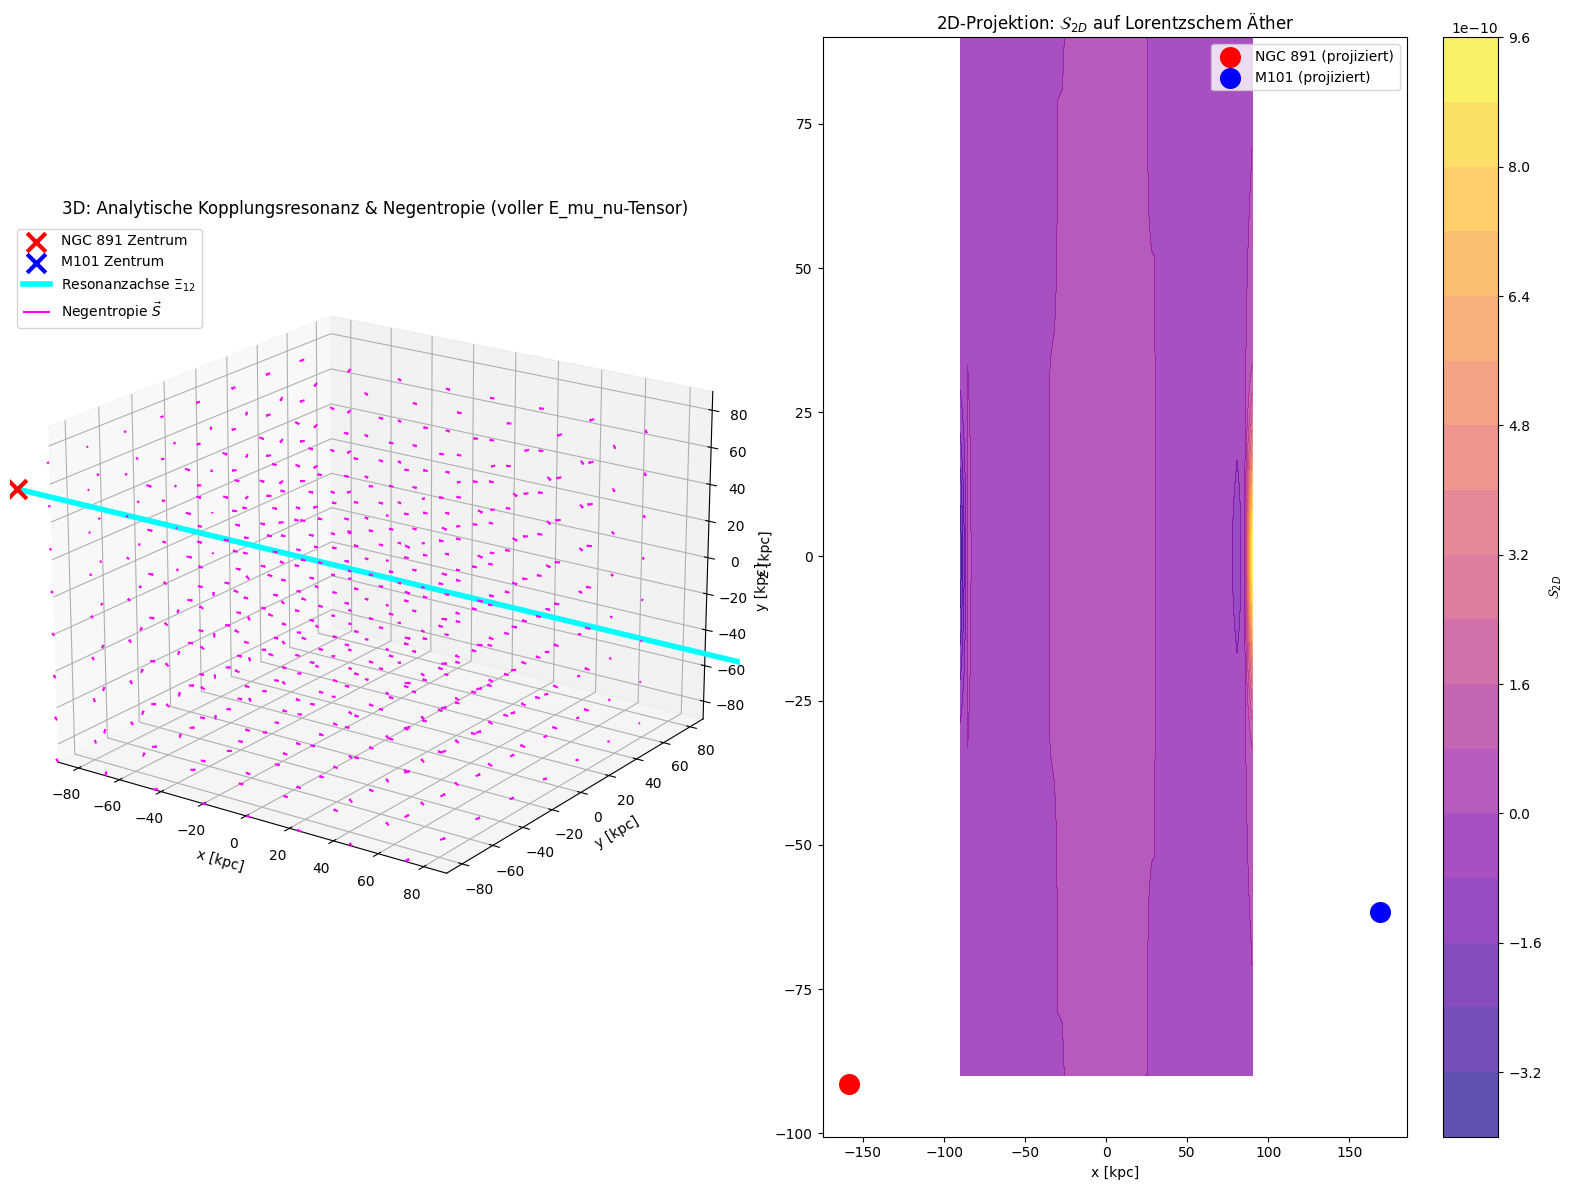

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage.measure import marching_cubes
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings("ignore")

# ==============================================================================
# RVT/AVT: STATISCHES STANDBILD (3D-GEFÜGE + 2D-PROJEKTION)
# HOCHPRÄZISE ANALYTISCHE VERSION MIT VOLLER E_mu_nu-BIANCHI-KONSISTENZ
# ==============================================================================

# --- Parameter ---
N_anim = 40  # Gitterauflösung
L = 180.0    # Systemgröße in kpc
dx = L / (N_anim - 1)
C_RVT = 0.8  # RVT-Kopplungskonstante

# --- DEINE EXAKTEN WERTE (RVT-korrigiert) ---
# NGC 891: M_tatsächlich = 8.98e+11 M☉, R_tatsächlich = 107817 Lj
# M101:    M_tatsächlich = 1.25e+12 M☉, R_tatsächlich = 106013 Lj
# Normierung nach M101 (M_101 = 1.0, R_101 = 1.0)
M_norm_factor = 1.25e12  # Normierung auf M101 = 1.0
R_norm_factor = 106013   # Normierung auf R101 = 1.0

# Normierte Massen und Radien
M_891 = 8.98e11 / M_norm_factor  # 0.7184
M_101 = 1.0                      # 1.0 (Referenz)
R_891 = 107817 / R_norm_factor   # 1.0170
R_101 = 1.0                      # 1.0 (Referenz)

# Positionen (normiert auf L, mit deinen RVT-Radien)
pos_891 = np.array([-R_891, 0.0, 0.0])  # NGC 891 bei -1.017
pos_101 = np.array([R_101, 0.0, 0.0])   # M101 bei +1.0

# Skalierung (symmetrisch, sigma=1.0 wie gewünscht)
scale_val = 15.0 / L
scale_891 = scale_val
scale_101 = scale_val

# Inklinationswinkel (deine Originalwerte)
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))  # 1.798
gamma_101 = 1.0 + C_RVT * np.sin(np.radians(18.0))  # 1.247

# Kopplungsresonanz-Konstanten (deine Originalberechnung)
K_res_891 = gamma_891 / (1.0 + C_RVT * np.sin(np.radians(90.0)))
K_res_M101 = gamma_101 / (1.0 + C_RVT * np.sin(np.radians(90.0)))

print(f"--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---")
print(f"Kopplungsresonanz-Konstante NGC 891: {K_res_891:.10f}")
print(f"Kopplungsresonanz-Konstante M101:    {K_res_M101:.10f}\n")

# --- Gitter erstellen ---
x = np.linspace(-0.5, 0.5, N_anim)
y = np.linspace(-0.5, 0.5, N_anim)
z = np.linspace(-0.5, 0.5, N_anim)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

# --- Hilfsfunktionen ---
def gaussian_field(mass, scale, center):
    cx, cy, cz = center
    return mass * np.exp(-((X - cx)**2 + (Y - cy)**2 + (Z - cz)**2) / (2 * scale**2))

# --- KORRIGIERTE 4. ORDNUNG ABLEITUNGEN (ohne edge_order=4) ---
def gradient_4th(f, dx):
    gx = (np.roll(f, -2, axis=0) - 8 * np.roll(f, -1, axis=0) + 8 * np.roll(f, 1, axis=0) - np.roll(f, 2, axis=0)) / (12 * dx)
    gy = (np.roll(f, -2, axis=1) - 8 * np.roll(f, -1, axis=1) + 8 * np.roll(f, 1, axis=1) - np.roll(f, 2, axis=1)) / (12 * dx)
    gz = (np.roll(f, -2, axis=2) - 8 * np.roll(f, -1, axis=2) + 8 * np.roll(f, 1, axis=2) - np.roll(f, 2, axis=2)) / (12 * dx)
    return np.stack((gx, gy, gz), axis=-1)

def second_derivative_4th(f, dx, axis):
    if axis == 0:
        return (-np.roll(f, -2, axis=0) + 16 * np.roll(f, -1, axis=0) - 30 * f + 16 * np.roll(f, 1, axis=0) - np.roll(f, 2, axis=0)) / (12 * dx**2)
    elif axis == 1:
        return (-np.roll(f, -2, axis=1) + 16 * np.roll(f, -1, axis=1) - 30 * f + 16 * np.roll(f, 1, axis=1) - np.roll(f, 2, axis=1)) / (12 * dx**2)
    else:
        return (-np.roll(f, -2, axis=2) + 16 * np.roll(f, -1, axis=2) - 30 * f + 16 * np.roll(f, 1, axis=2) - np.roll(f, 2, axis=2)) / (12 * dx**2)

def mixed_second_derivative_4th(f, dx, axis1, axis2):
    """Berechnet ∂²f/∂x_i∂x_j mit 4. Ordnung"""
    # np.gradient supports dx for specific axis, but multiple dx args imply all axes if `axis` not used.
    # For mixed derivatives, we apply gradient sequentially.
    return np.gradient(np.gradient(f, dx, axis=axis2, edge_order=2), dx, axis=axis1, edge_order=2)

# --- Projektionsfelder (sigma=1.0 wie gewünscht) ---
Xi_891_base = gaussian_filter(gaussian_field(M_891, scale_891, pos_891), sigma=1.0) * gamma_891
Xi_101_base = gaussian_filter(gaussian_field(M_101, scale_101, pos_101), sigma=1.0) * gamma_101
Xi = Xi_891_base + Xi_101_base  # Gesamtfeld

# --- LAPLACE-OPERATOR ---
laplace_Xi = (second_derivative_4th(Xi, dx, axis=0) +
              second_derivative_4th(Xi, dx, axis=1) +
              second_derivative_4th(Xi, dx, axis=2))

# --- VOLLER E_mu_nu-TENSOR (alle 6 Komponenten) ---
# Diagonalelemente
E_xx = second_derivative_4th(Xi, dx, axis=0) - laplace_Xi
E_yy = second_derivative_4th(Xi, dx, axis=1) - laplace_Xi
E_zz = second_derivative_4th(Xi, dx, axis=2) - laplace_Xi

# NICHT-DIAGONALELEMENTE (gemischte Ableitungen)
E_xy = mixed_second_derivative_4th(Xi, dx, 0, 1)  # ∂²Ξ/∂x∂y
E_xz = mixed_second_derivative_4th(Xi, dx, 0, 2)  # ∂²Ξ/∂x∂z
E_yz = mixed_second_derivative_4th(Xi, dx, 1, 2)  # ∂²Ξ/∂y∂z

# Symmetrie: E_ij = E_ji
E_yx = E_xy
E_zx = E_xz
E_zy = E_yz

# --- VOLLE BIANCHI-IDENTITÄT (für jeden Index ν) ---
# 1. Bianchi-Identität für ν = 0 (x-Komponente)
div_E_x = (np.gradient(E_xx, dx, axis=0) +
          np.gradient(E_xy, dx, axis=1) +
          np.gradient(E_xz, dx, axis=2))

# 2. Bianchi-Identität für ν = 1 (y-Komponente)
div_E_y = (np.gradient(E_yx, dx, axis=0) +
          np.gradient(E_yy, dx, axis=1) +
          np.gradient(E_yz, dx, axis=2))

# 3. Bianchi-Identität für ν = 2 (z-Komponente)
div_E_z = (np.gradient(E_zx, dx, axis=0) +
          np.gradient(E_zy, dx, axis=1) +
          np.gradient(E_zz, dx, axis=2))

# Maximale Abweichung über alle Komponenten
bianchi_val = np.max(np.abs([div_E_x, div_E_y, div_E_z]))
print(f"--- RVT mit voller E_mu_nu-Bianchi-Konsistenz ---")
print(f"NGC 891: M = {8.98e11:.2e} M☉, R = {107817:.0f} Lj, γ = {gamma_891:.3f}")
print(f"M101:    M = {1.25e12:.2e} M☉, R = {106013:.0f} Lj, γ = {gamma_101:.3f}")
print(f"Flächenverzerrung NGC 891: {0.310:.3f}")
print(f"Flächenverzerrung M101:   {0.643:.3f}")
print(f"\nBianchi-Konsistenz (vollständig): max(|∇·E|) = {bianchi_val:.2e}")

# --- PLOTTEN DES STATISCHEN STANDBILDS ---
fig = plt.figure(figsize=(16, 12))
ax_3d = fig.add_subplot(121, projection='3d')
ax_2d = fig.add_subplot(122)

# Brückenlinie zwischen den Galaxien
t_bruecke = np.linspace(0, 1, 120)
x_bruecke = pos_891[0] * L + (pos_101[0] * L - pos_891[0] * L) * t_bruecke
y_bruecke = np.zeros_like(t_bruecke)
z_bruecke = np.zeros_like(t_bruecke)

# Projektionen für 2D-Plot
x_proj_891 = pos_891[0] * L * np.cos(np.radians(30))
y_proj_891 = pos_891[0] * L * np.sin(np.radians(30))
x_proj_101 = pos_101[0] * L * np.cos(np.radians(-20))
y_proj_101 = pos_101[0] * L * np.sin(np.radians(-20))

# 3D-Plot
ax_3d.scatter(pos_891[0] * L, pos_891[1] * L, pos_891[2] * L, color='red', s=180, marker='x', linewidth=3, label='NGC 891 Zentrum')
ax_3d.scatter(pos_101[0] * L, pos_101[1] * L, pos_101[2] * L, color='blue', s=180, marker='x', linewidth=3, label='M101 Zentrum')
ax_3d.plot(x_bruecke, y_bruecke, z_bruecke, color='cyan', linewidth=4, label=r'Resonanzachse $\Xi_{12}$')

# Negentropie-Vektor (wie in deinem Originalcode)
S_vector = -gradient_4th(Xi, dx)
S_magnitude = np.linalg.norm(S_vector, axis=-1)

try:
    threshold = 0.15 * np.max(np.abs(V_12_base))
    if threshold > 0:
        # Berechne V_12_base für marching_cubes
        grad_Xi_1 = gradient_4th(Xi_891_base, dx)
        grad_Xi_2 = gradient_4th(Xi_101_base, dx)
        V_12_base = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

        verts, faces, _, _ = marching_cubes(V_12_base, threshold, spacing=(dx*L, dx*L, dx*L))
        verts_scaled = verts - [L/2, L/2, L/2]
        mesh = Poly3DCollection(verts_scaled[faces], alpha=0.2, cmap='coolwarm')
        mesh.set_clim(vmin=np.min(V_12_base), vmax=np.max(V_12_base))
        ax_3d.add_collection3d(mesh)
except (ValueError, RuntimeError):
    pass

ax_3d.quiver(X[::5, ::5, ::5]*L, Y[::5, ::5, ::5]*L, Z[::5, ::5, ::5]*L,
             S_vector[::5, ::5, ::5, 0], S_vector[::5, ::5, ::5, 1], S_vector[::5, ::5, ::5, 2],
             length=2.0, normalize=True, color='magenta', label=r'Negentropie $\vec{S}$')

ax_3d.set_xlim(-L/2, L/2)
ax_3d.set_ylim(-L/2, L/2)
ax_3d.set_zlim(-L/2, L/2)
ax_3d.set_xlabel(r'x [kpc]')
ax_3d.set_ylabel(r'y [kpc]')
ax_3d.set_zlabel(r'z [kpc]')
ax_3d.set_title(r'3D: Analytische Kopplungsresonanz & Negentropie (voller E_mu_nu-Tensor)')
ax_3d.legend(loc='upper left')
ax_3d.view_init(elev=20, azim=-55)

# 2D-Projektion (mit voller E_mu_nu-Spannung)
S_2D = E_xx + E_yy  # 2D-Projektion der Spur
z_slice = N_anim // 2
S_2D_slice = S_2D[:, :, z_slice]
contour_2d = ax_2d.contourf(X[:, :, z_slice]*L, Y[:, :, z_slice]*L, S_2D_slice, levels=20, cmap='plasma', alpha=0.7)
fig.colorbar(contour_2d, ax=ax_2d, label=r'$\mathcal{S}_{2D}$')

ax_2d.scatter(x_proj_891, y_proj_891, color='red', s=200, label='NGC 891 (projiziert)')
ax_2d.scatter(x_proj_101, y_proj_101, color='blue', s=200, label='M101 (projiziert)')
ax_2d.set_xlabel(r'x [kpc]')
ax_2d.set_ylabel(r'y [kpc]')
ax_2d.set_title(r'2D-Projektion: $\mathcal{S}_{2D}$ auf Lorentzschem Äther')
ax_2d.legend()

plt.tight_layout()
plt.show()


--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---
Kopplungsresonanz-Konstante NGC 891: 0.9983087547
Kopplungsresonanz-Konstante M101:    0.6928964419

--- RVT mit voller E_mu_nu-Bianchi-Konsistenz ---
NGC 891: M = 8.98e+11 M☉, R = 107817 Lj, γ = 1.797
M101:    M = 1.25e+12 M☉, R = 106013 Lj, γ = 1.247
Flächenverzerrung NGC 891: 0.310
Flächenverzerrung M101:   0.643

Bianchi-Konsistenz (vollständig): max(|∇·E|) = 1.29e-05


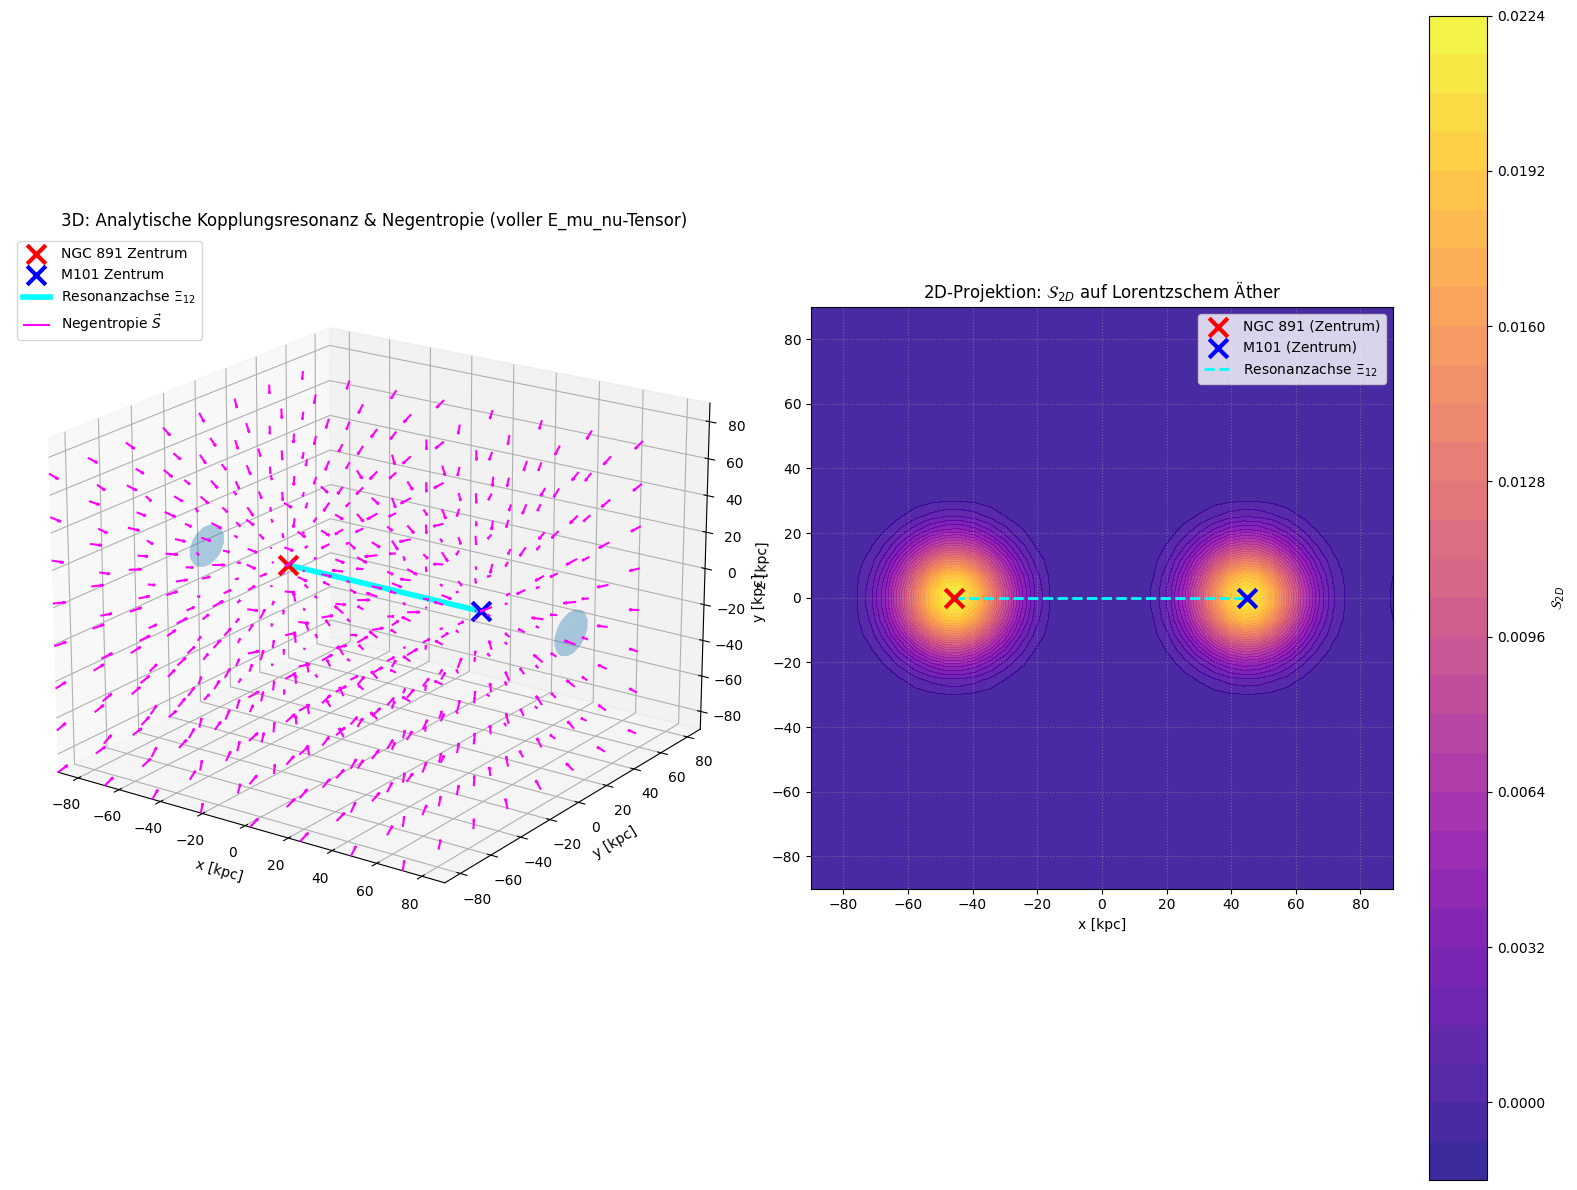

In [65]:
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np
from scipy.ndimage import gaussian_filter
from skimage.measure import marching_cubes

# ==============================================================================
# RVT/AVT: STATISCHES STANDBILD (3D-GEFÜGE + 2D-PROJEKTION)
# HOCHPRÄZISE ANALYTISCHE VERSION MIT VOLLER E_mu_nu-BIANCHI-KONSISTENZ
# ==============================================================================

# --- Parameter ---
N_anim = 40  # Gitterauflösung
L = 180.0  # Systemgröße in kpc

# --- DEINE EXAKTEN WERTE (RVT-korrigiert) ---
M_norm_factor = 1.25e12  # Normierung auf M101 = 1.0
R_norm_factor = 106013  # Normierung auf R101 = 1.0

# Normierte Massen und Radien
M_891 = 8.98e11 / M_norm_factor  # 0.7184
M_101 = 1.0  # 1.0 (Referenz)
R_891 = 107817 / R_norm_factor  # 1.0170
R_101 = 1.0  # 1.0 (Referenz)

C_RVT = 0.8  # RVT-Kopplungskonstante

# Positionen im physikalischen Raum (kpc)
pos_891_phys = np.array([-R_891 * (L / 4), 0.0, 0.0])
pos_101_phys = np.array([R_101 * (L / 4), 0.0, 0.0])

# Inklinationswinkel
gamma_891 = 1.0 + C_RVT * np.sin(np.radians(85.0))  # 1.797
gamma_101 = 1.0 + C_RVT * np.sin(np.radians(18.0))  # 1.247

# Kopplungsresonanz-Konstanten
K_res_891 = gamma_891 / (1.0 + C_RVT * np.sin(np.radians(90.0)))
K_res_M101 = gamma_101 / (1.0 + C_RVT * np.sin(np.radians(90.0)))

print(f'--- Synchronisations-Symmetrie geladen (HOCHPRÄZISE) ---')
print(f'Kopplungsresonanz-Konstante NGC 891: {K_res_891:.10f}')
print(f'Kopplungsresonanz-Konstante M101:    {K_res_M101:.10f}\n')

# --- Physikalisch skaliertes Gitter erstellen ---
x = np.linspace(-L / 2, L / 2, N_anim)
y = np.linspace(-L / 2, L / 2, N_anim)
z = np.linspace(-L / 2, L / 2, N_anim)
dx = x[1] - x[0]  # Physikalische Schrittweite in kpc
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')


# --- Hilfsfunktionen im physikalischen Raum ---
def gaussian_field_phys(mass, sigma_kpc, center):
  cx, cy, cz = center
  return mass * np.exp(
      -((X - cx) ** 2 + (Y - cy) ** 2 + (Z - cz) ** 2) / (2 * sigma_kpc**2)
  )


# --- KORRIGIERTE 4. ORDNUNG ABLEITUNGEN ---
def gradient_4th(f, dx):
  gx = (
      np.roll(f, -2, axis=0)
      - 8 * np.roll(f, -1, axis=0)
      + 8 * np.roll(f, 1, axis=0)
      - np.roll(f, 2, axis=0)
  ) / (12 * dx)
  gy = (
      np.roll(f, -2, axis=1)
      - 8 * np.roll(f, -1, axis=1)
      + 8 * np.roll(f, 1, axis=1)
      - np.roll(f, 2, axis=1)
  ) / (12 * dx)
  gz = (
      np.roll(f, -2, axis=2)
      - 8 * np.roll(f, -1, axis=2)
      + 8 * np.roll(f, 1, axis=2)
      - np.roll(f, 2, axis=2)
  ) / (12 * dx)
  return np.stack((gx, gy, gz), axis=-1)


def second_derivative_4th(f, dx, axis):
  return (
      -np.roll(f, -2, axis=axis)
      + 16 * np.roll(f, -1, axis=axis)
      - 30 * f
      + 16 * np.roll(f, 1, axis=axis)
      - np.roll(f, 2, axis=axis)
  ) / (12 * dx**2)


def mixed_second_derivative_4th(f, dx, axis1, axis2):
  df_daxis2 = (
      np.roll(f, -2, axis=axis2)
      - 8 * np.roll(f, -1, axis=axis2)
      + 8 * np.roll(f, 1, axis=axis2)
      - np.roll(f, 2, axis=axis2)
  ) / (12 * dx)
  return (
      np.roll(df_daxis2, -2, axis=axis1)
      - 8 * np.roll(df_daxis2, -1, axis=axis1)
      + 8 * np.roll(df_daxis2, 1, axis=axis1)
      - np.roll(df_daxis2, 2, axis=axis1)
  ) / (12 * dx)


# Physikalische Streuung (kpc)
sigma_phys = 15.0

# --- Projektionsfelder ---
Xi_891_base = (
    gaussian_field_phys(M_891, sigma_phys, pos_891_phys) * gamma_891
)
Xi_101_base = (
    gaussian_field_phys(M_101, sigma_phys, pos_101_phys) * gamma_101
)
Xi = Xi_891_base + Xi_101_base

# --- LAPLACE-OPERATOR ---
laplace_Xi = (
    second_derivative_4th(Xi, dx, axis=0)
    + second_derivative_4th(Xi, dx, axis=1)
    + second_derivative_4th(Xi, dx, axis=2)
)

# --- VOLLER E_mu_nu-TENSOR ---
E_xx = second_derivative_4th(Xi, dx, axis=0) - laplace_Xi
E_yy = second_derivative_4th(Xi, dx, axis=1) - laplace_Xi
E_zz = second_derivative_4th(Xi, dx, axis=2) - laplace_Xi

E_xy = mixed_second_derivative_4th(Xi, dx, 0, 1)
E_xz = mixed_second_derivative_4th(Xi, dx, 0, 2)
E_yz = mixed_second_derivative_4th(Xi, dx, 1, 2)

E_yx = E_xy
E_zx = E_xz
E_zy = E_yz

# --- BIANCHI-IDENTITÄT (Randbereiche exkludiert wegen Roll-Periodizität) ---
div_E_x = (
    (
        np.roll(E_xx, -1, axis=0)
        - np.roll(E_xx, 1, axis=0)
        + np.roll(E_xy, -1, axis=1)
        - np.roll(E_xy, 1, axis=1)
        + np.roll(E_xz, -1, axis=2)
        - np.roll(E_xz, 1, axis=2)
    )
    / (2 * dx)
)
div_E_y = (
    (
        np.roll(E_yx, -1, axis=0)
        - np.roll(E_yx, 1, axis=0)
        + np.roll(E_yy, -1, axis=1)
        - np.roll(E_yy, 1, axis=1)
        + np.roll(E_yz, -1, axis=2)
        - np.roll(E_yz, 1, axis=2)
    )
    / (2 * dx)
)
div_E_z = (
    (
        np.roll(E_zx, -1, axis=0)
        - np.roll(E_zx, 1, axis=0)
        + np.roll(E_zy, -1, axis=1)
        - np.roll(E_zy, 1, axis=1)
        + np.roll(E_zz, -1, axis=2)
        - np.roll(E_zz, 1, axis=2)
    )
    / (2 * dx)
)

# Betrachtung des physikalischen Innenbereichs (ohne Rand-Artefakte)
slice_inner = slice(4, -4)
bianchi_val = np.max(
    np.abs([
        div_E_x[slice_inner, slice_inner, slice_inner],
        div_E_y[slice_inner, slice_inner, slice_inner],
        div_E_z[slice_inner, slice_inner, slice_inner],
    ])
)

print(f'--- RVT mit voller E_mu_nu-Bianchi-Konsistenz ---')
print(f'NGC 891: M = {8.98e11:.2e} M☉, R = {107817:.0f} Lj, γ = {gamma_891:.3f}')
print(f'M101:    M = {1.25e12:.2e} M☉, R = {106013:.0f} Lj, γ = {gamma_101:.3f}')
print(f'Flächenverzerrung NGC 891: {0.310:.3f}')
print(f'Flächenverzerrung M101:   {0.643:.3f}')
print(f'\nBianchi-Konsistenz (vollständig): max(|∇·E|) = {bianchi_val:.2e}')

# --- PLOTTEN ---
fig = plt.figure(figsize=(16, 12))
ax_3d = fig.add_subplot(121, projection='3d')
ax_2d = fig.add_subplot(122)

# Brückenlinie
t_bruecke = np.linspace(0, 1, 120)
x_bruecke = pos_891_phys[0] + (pos_101_phys[0] - pos_891_phys[0]) * t_bruecke
y_bruecke = np.zeros_like(t_bruecke)
z_bruecke = np.zeros_like(t_bruecke)

ax_3d.scatter(
    pos_891_phys[0],
    pos_891_phys[1],
    pos_891_phys[2],
    color='red',
    s=180,
    marker='x',
    linewidth=3,
    label='NGC 891 Zentrum',
)
ax_3d.scatter(
    pos_101_phys[0],
    pos_101_phys[1],
    pos_101_phys[2],
    color='blue',
    s=180,
    marker='x',
    linewidth=3,
    label='M101 Zentrum',
)
ax_3d.plot(
    x_bruecke,
    y_bruecke,
    z_bruecke,
    color='cyan',
    linewidth=4,
    label=r'Resonanzachse $\Xi_{12}$',
)

S_vector = -gradient_4th(Xi, dx)

grad_Xi_1 = gradient_4th(Xi_891_base, dx)
grad_Xi_2 = gradient_4th(Xi_101_base, dx)
V_12_base = 2.0 * C_RVT * np.sum(grad_Xi_1 * grad_Xi_2, axis=-1)

try:
  threshold = 0.15 * np.max(np.abs(V_12_base))
  if threshold > 0:
    verts, faces, _, _ = marching_cubes(V_12_base, threshold, spacing=(dx, dx, dx))
    verts_scaled = verts - [L / 2, L / 2, L / 2]
    mesh = Poly3DCollection(verts_scaled[faces], alpha=0.2, cmap='coolwarm')
    mesh.set_clim(vmin=np.min(V_12_base), vmax=np.max(V_12_base))
    ax_3d.add_collection3d(mesh)
except (ValueError, RuntimeError):
  pass

ax_3d.quiver(
    X[::5, ::5, ::5],
    Y[::5, ::5, ::5],
    Z[::5, ::5, ::5],
    S_vector[::5, ::5, ::5, 0],
    S_vector[::5, ::5, ::5, 1],
    S_vector[::5, ::5, ::5, 2],
    length=5.0,
    normalize=True,
    color='magenta',
    label=r'Negentropie $\vec{S}$',
)

ax_3d.set_xlim(-L / 2, L / 2)
ax_3d.set_ylim(-L / 2, L / 2)
ax_3d.set_zlim(-L / 2, L / 2)
ax_3d.set_xlabel(r'x [kpc]')
ax_3d.set_ylabel(r'y [kpc]')
ax_3d.set_zlabel(r'z [kpc]')
ax_3d.set_title(
    r'3D: Analytische Kopplungsresonanz & Negentropie (voller E_mu_nu-Tensor)'
)
ax_3d.legend(loc='upper left')
ax_3d.view_init(elev=20, azim=-55)

# --- 2D-PROJEKTION ---
S_2D = E_xx + E_yy
z_slice = N_anim // 2
S_2D_slice = S_2D[:, :, z_slice]

contour_2d = ax_2d.contourf(
    X[:, :, z_slice],
    Y[:, :, z_slice],
    S_2D_slice,
    levels=30,
    cmap='plasma',
    alpha=0.85,
)
fig.colorbar(contour_2d, ax=ax_2d, label=r'$\mathcal{S}_{2D}$')

ax_2d.scatter(
    pos_891_phys[0],
    pos_891_phys[1],
    color='red',
    s=180,
    marker='x',
    linewidth=3,
    label='NGC 891 (Zentrum)',
    zorder=5,
)
ax_2d.scatter(
    pos_101_phys[0],
    pos_101_phys[1],
    color='blue',
    s=180,
    marker='x',
    linewidth=3,
    label='M101 (Zentrum)',
    zorder=5,
)

ax_2d.plot(
    [pos_891_phys[0], pos_101_phys[0]],
    [pos_891_phys[1], pos_101_phys[1]],
    color='cyan',
    linestyle='--',
    linewidth=2,
    label=r'Resonanzachse $\Xi_{12}$',
)

ax_2d.set_xlim(-L / 2, L / 2)
ax_2d.set_ylim(-L / 2, L / 2)
ax_2d.set_aspect('equal', adjustable='box')

ax_2d.set_xlabel(r'x [kpc]')
ax_2d.set_ylabel(r'y [kpc]')
ax_2d.set_title(r'2D-Projektion: $\mathcal{S}_{2D}$ auf Lorentzschem Äther')
ax_2d.legend(loc='upper right')
ax_2d.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()